In [8]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews/product_info.csv
/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews/reviews_250_500.csv
/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews/reviews_1500_end.csv
/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews/reviews_1000_1500.csv
/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews/reviews_500_750.csv
/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews/reviews_750_1000.csv
/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews/reviews_0_250.csv


# **Load Dataset Version 1**

In [9]:
DATA_DIR = "/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews"

# **Executive KPI summary**

In [11]:
import os
import re
import math
import json
import glob
import uuid
import hashlib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

# ============================================================
# CONFIG
# ============================================================

DATA_DIR = "/kaggle/input/datasets/piyushxx7/sephora-products-and-skincare-reviews"
OUTPUT_DIR = "/kaggle/working/sephora_industry_dataset"

os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

START_DATE = "2023-01-01"
END_DATE = "2023-12-31"

N_SESSIONS = 350_000
N_CAMPAIGNS = 80

# Use this to reduce output size if your laptop/Kaggle memory is low
MAX_IMPRESSIONS_PER_SESSION = 8

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def clean_col(c):
    c = str(c).strip().lower()
    c = re.sub(r"[^a-z0-9]+", "_", c)
    c = re.sub(r"_+", "_", c).strip("_")
    return c

def stable_id(prefix, value):
    raw = str(value).encode("utf-8")
    return f"{prefix}_{hashlib.md5(raw).hexdigest()[:12]}"

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def safe_numeric(series, default=np.nan):
    return pd.to_numeric(series, errors="coerce").fillna(default)

def detect_column(df, candidates):
    cols = list(df.columns)
    for c in candidates:
        if c in cols:
            return c
    for c in candidates:
        for col in cols:
            if c in col:
                return col
    return None

def date_range_random(n, start=START_DATE, end=END_DATE):
    start_ts = pd.Timestamp(start)
    end_ts = pd.Timestamp(end)
    days = (end_ts - start_ts).days + 1
    random_days = rng.integers(0, days, size=n)
    seconds = rng.integers(0, 24 * 3600, size=n)
    return start_ts + pd.to_timedelta(random_days, unit="D") + pd.to_timedelta(seconds, unit="s")

def normalize_0_1(s):
    s = pd.Series(s).astype(float)
    if s.max() == s.min():
        return pd.Series(np.ones(len(s)) * 0.5, index=s.index)
    return (s - s.min()) / (s.max() - s.min())

def weighted_choice(values, weights, size):
    weights = np.array(weights, dtype=float)
    weights = np.nan_to_num(weights, nan=0.0, posinf=0.0, neginf=0.0)
    if weights.sum() <= 0:
        weights = np.ones(len(values)) / len(values)
    else:
        weights = weights / weights.sum()
    return rng.choice(values, size=size, replace=True, p=weights)

def introduce_nulls(df, col, pct):
    if col not in df.columns:
        return df
    n = len(df)
    k = int(n * pct)
    if k > 0:
        idx = rng.choice(df.index, size=k, replace=False)
        df.loc[idx, col] = np.nan
    return df

# ============================================================
# LOAD SEPHORA FILES
# ============================================================

csv_files = glob.glob(os.path.join(DATA_DIR, "*.csv"))

if not csv_files:
    raise FileNotFoundError(
        f"No CSV files found in {DATA_DIR}. Please check DATA_DIR path."
    )

print("Files found:")
for f in csv_files:
    print("-", os.path.basename(f))

loaded = {}

for file in csv_files:
    name = Path(file).stem.lower()
    try:
        df = pd.read_csv(file)
    except UnicodeDecodeError:
        df = pd.read_csv(file, encoding="latin1")
    df.columns = [clean_col(c) for c in df.columns]
    loaded[name] = df

# Try to identify product table and review tables
product_table_name = None
review_table_names = []

product_table_name = None
review_table_names = []

for name, df in loaded.items():
    cols = set(df.columns)

    if "product_info" in name:
        product_table_name = name

    elif name.startswith("reviews"):
        review_table_names.append(name)

# fallback if product_info name is not found
if product_table_name is None:
    for name, df in loaded.items():
        cols = set(df.columns)
        if (
            ("product_id" in cols)
            and ("product_name" in cols or "brand_name" in cols)
            and ("price_usd" in cols or "price" in cols)
        ):
            product_table_name = name
            break

if product_table_name is None:
    raise ValueError("Could not detect product table. Expected product_info.csv or similar.")

products_raw = loaded[product_table_name].copy()

reviews_raw_list = []
for name in review_table_names:
    reviews_raw_list.append(loaded[name].copy())

if reviews_raw_list:
    reviews_raw = pd.concat(reviews_raw_list, ignore_index=True)
else:
    reviews_raw = pd.DataFrame()

print("\nDetected product table:", product_table_name)
print("Detected review tables:", review_table_names)
print("Products shape:", products_raw.shape)
print("Reviews shape:", reviews_raw.shape)

# ============================================================
# STANDARDIZE PRODUCT TABLE
# ============================================================

product_id_col = detect_column(products_raw, ["product_id", "id"])
product_name_col = detect_column(products_raw, ["product_name", "name"])
brand_id_col = detect_column(products_raw, ["brand_id"])
brand_name_col = detect_column(products_raw, ["brand_name", "brand"])
price_col = detect_column(products_raw, ["price_usd", "price", "sale_price_usd"])
rating_col = detect_column(products_raw, ["rating"])
reviews_col = detect_column(products_raw, ["reviews", "review_count", "number_of_reviews", "n_of_reviews"])
loves_col = detect_column(products_raw, ["loves_count", "love", "n_of_loves"])
category_col = detect_column(products_raw, ["primary_category", "secondary_category", "tertiary_category", "category"])
ingredients_col = detect_column(products_raw, ["ingredients"])
online_only_col = detect_column(products_raw, ["online_only"])
out_of_stock_col = detect_column(products_raw, ["out_of_stock"])
limited_col = detect_column(products_raw, ["limited_edition"])
new_col = detect_column(products_raw, ["new"])
sephora_exclusive_col = detect_column(products_raw, ["sephora_exclusive"])
size_col = detect_column(products_raw, ["size"])

dim_product = pd.DataFrame()

if product_id_col:
    dim_product["product_id"] = products_raw[product_id_col].astype(str)
else:
    dim_product["product_id"] = [stable_id("prd", i) for i in range(len(products_raw))]

dim_product["product_name"] = products_raw[product_name_col].astype(str) if product_name_col else "Unknown Product"

if brand_id_col:
    dim_product["brand_id"] = products_raw[brand_id_col].astype(str)
elif brand_name_col:
    dim_product["brand_id"] = products_raw[brand_name_col].astype(str).apply(lambda x: stable_id("brd", x))
else:
    dim_product["brand_id"] = "brd_unknown"

dim_product["brand_name"] = products_raw[brand_name_col].astype(str) if brand_name_col else "Unknown Brand"

dim_product["category"] = products_raw[category_col].astype(str) if category_col else "unknown"

dim_product["price"] = safe_numeric(products_raw[price_col], default=np.nan) if price_col else np.nan
dim_product["rating"] = safe_numeric(products_raw[rating_col], default=np.nan) if rating_col else np.nan
dim_product["review_count"] = safe_numeric(products_raw[reviews_col], default=0).astype(int) if reviews_col else 0
dim_product["loves_count"] = safe_numeric(products_raw[loves_col], default=0).astype(int) if loves_col else 0

dim_product["ingredients"] = products_raw[ingredients_col].astype(str) if ingredients_col else np.nan
dim_product["size"] = products_raw[size_col].astype(str) if size_col else np.nan

for new_col_name, source_col in [
    ("online_only", online_only_col),
    ("out_of_stock", out_of_stock_col),
    ("limited_edition", limited_col),
    ("is_new", new_col),
    ("sephora_exclusive", sephora_exclusive_col),
]:
    if source_col:
        dim_product[new_col_name] = safe_numeric(products_raw[source_col], default=0).astype(int)
    else:
        dim_product[new_col_name] = 0

# Data cleaning
dim_product["price"] = dim_product["price"].replace([np.inf, -np.inf], np.nan)
dim_product.loc[dim_product["price"] <= 0, "price"] = np.nan
dim_product["price"] = dim_product["price"].fillna(dim_product["price"].median())

dim_product["rating"] = dim_product["rating"].clip(0, 5)
dim_product["rating"] = dim_product["rating"].fillna(dim_product["rating"].median())

dim_product["review_count"] = dim_product["review_count"].clip(lower=0)
dim_product["loves_count"] = dim_product["loves_count"].clip(lower=0)

dim_product["category"] = dim_product["category"].replace(["nan", "None", ""], "unknown")
dim_product["brand_name"] = dim_product["brand_name"].replace(["nan", "None", ""], "Unknown Brand")

# Product popularity score based on real Sephora signals
dim_product["price_norm"] = normalize_0_1(np.log1p(dim_product["price"]))
dim_product["reviews_norm"] = normalize_0_1(np.log1p(dim_product["review_count"]))
dim_product["loves_norm"] = normalize_0_1(np.log1p(dim_product["loves_count"]))
dim_product["rating_norm"] = dim_product["rating"] / 5

dim_product["real_product_strength"] = (
    0.35 * dim_product["reviews_norm"]
    + 0.30 * dim_product["loves_norm"]
    + 0.25 * dim_product["rating_norm"]
    + 0.10 * (1 - dim_product["price_norm"])
)

dim_product["product_tier"] = pd.qcut(
    dim_product["price"],
    q=4,
    labels=["budget", "mid", "premium", "luxury"],
    duplicates="drop"
).astype(str)

# Controlled realistic nulls
dim_product = introduce_nulls(dim_product, "ingredients", 0.08)
dim_product = introduce_nulls(dim_product, "size", 0.12)

# Final product columns
dim_product = dim_product[
    [
        "product_id", "product_name", "brand_id", "brand_name", "category",
        "price", "product_tier", "rating", "review_count", "loves_count",
        "ingredients", "size", "online_only", "out_of_stock",
        "limited_edition", "is_new", "sephora_exclusive",
        "real_product_strength"
    ]
].drop_duplicates("product_id")

print("\nDim product:", dim_product.shape)

# ============================================================
# DIM BRAND
# ============================================================

dim_brand = (
    dim_product
    .groupby(["brand_id", "brand_name"], as_index=False)
    .agg(
        total_products=("product_id", "nunique"),
        avg_price=("price", "mean"),
        avg_rating=("rating", "mean"),
        total_reviews=("review_count", "sum"),
        total_loves=("loves_count", "sum")
    )
)

dim_brand["brand_strength"] = (
    0.35 * normalize_0_1(np.log1p(dim_brand["total_reviews"]))
    + 0.35 * normalize_0_1(np.log1p(dim_brand["total_loves"]))
    + 0.20 * (dim_brand["avg_rating"] / 5)
    + 0.10 * normalize_0_1(np.log1p(dim_brand["total_products"]))
)

dim_brand["brand_tier"] = pd.qcut(
    dim_brand["brand_strength"],
    q=4,
    labels=["emerging", "growing", "strong", "hero"],
    duplicates="drop"
).astype(str)

print("Dim brand:", dim_brand.shape)

# ============================================================
# STANDARDIZE REVIEWS
# ============================================================

if len(reviews_raw) > 0:
    r_product_id_col = detect_column(reviews_raw, ["product_id"])
    r_user_col = detect_column(reviews_raw, ["author_id", "user_id", "profile_id"])
    r_rating_col = detect_column(reviews_raw, ["rating", "review_rating"])
    r_text_col = detect_column(reviews_raw, ["review_text", "text"])
    r_title_col = detect_column(reviews_raw, ["review_title", "title"])
    r_date_col = detect_column(reviews_raw, ["submission_time", "review_date", "date"])
    r_helpful_col = detect_column(reviews_raw, ["helpfulness", "total_feedback_count", "total_neg_feedback_count", "total_pos_feedback_count"])
    skin_type_col = detect_column(reviews_raw, ["skin_type"])
    skin_tone_col = detect_column(reviews_raw, ["skin_tone"])
    eye_color_col = detect_column(reviews_raw, ["eye_color"])
    hair_color_col = detect_column(reviews_raw, ["hair_color"])

    fact_reviews = pd.DataFrame()

    fact_reviews["review_id"] = [stable_id("rev", i) for i in range(len(reviews_raw))]

    if r_product_id_col:
        fact_reviews["product_id"] = reviews_raw[r_product_id_col].astype(str)
    else:
        fact_reviews["product_id"] = weighted_choice(
            dim_product["product_id"].values,
            dim_product["real_product_strength"].values,
            len(reviews_raw)
        )

    if r_user_col:
        fact_reviews["customer_id"] = reviews_raw[r_user_col].astype(str).apply(lambda x: stable_id("cus", x))
    else:
        fact_reviews["customer_id"] = [stable_id("cus", i) for i in rng.integers(1, 200_000, size=len(reviews_raw))]

    fact_reviews["review_rating"] = safe_numeric(reviews_raw[r_rating_col], default=np.nan) if r_rating_col else np.nan
    fact_reviews["review_rating"] = fact_reviews["review_rating"].clip(1, 5).fillna(4)

    fact_reviews["review_text"] = reviews_raw[r_text_col].astype(str) if r_text_col else np.nan
    fact_reviews["review_title"] = reviews_raw[r_title_col].astype(str) if r_title_col else np.nan

    if r_date_col:
        fact_reviews["review_date"] = pd.to_datetime(reviews_raw[r_date_col], errors="coerce")
        fact_reviews["review_date"] = fact_reviews["review_date"].fillna(pd.Series(date_range_random(len(fact_reviews))))
    else:
        fact_reviews["review_date"] = date_range_random(len(fact_reviews))

    fact_reviews["skin_type"] = reviews_raw[skin_type_col].astype(str) if skin_type_col else np.nan
    fact_reviews["skin_tone"] = reviews_raw[skin_tone_col].astype(str) if skin_tone_col else np.nan
    fact_reviews["eye_color"] = reviews_raw[eye_color_col].astype(str) if eye_color_col else np.nan
    fact_reviews["hair_color"] = reviews_raw[hair_color_col].astype(str) if hair_color_col else np.nan

    # Simple sentiment proxy from rating
    fact_reviews["sentiment_label"] = np.select(
        [
            fact_reviews["review_rating"] <= 2,
            fact_reviews["review_rating"] == 3,
            fact_reviews["review_rating"] >= 4
        ],
        ["negative", "neutral", "positive"],
        default="neutral"
    )

    fact_reviews = fact_reviews[fact_reviews["product_id"].isin(dim_product["product_id"])]
    fact_reviews = fact_reviews.drop_duplicates("review_id")

else:
    fact_reviews = pd.DataFrame(
        columns=[
            "review_id", "product_id", "customer_id", "review_rating",
            "review_text", "review_title", "review_date", "skin_type",
            "skin_tone", "eye_color", "hair_color", "sentiment_label"
        ]
    )

print("Fact reviews:", fact_reviews.shape)

# ============================================================
# DIM CUSTOMER
# ============================================================

if len(fact_reviews) > 0:
    customer_base = (
        fact_reviews
        .sort_values("review_date")
        .drop_duplicates("customer_id")
        [["customer_id", "skin_type", "skin_tone", "eye_color", "hair_color"]]
        .copy()
    )
else:
    customer_base = pd.DataFrame({"customer_id": [stable_id("cus", i) for i in range(100_000)]})
    customer_base["skin_type"] = np.nan
    customer_base["skin_tone"] = np.nan
    customer_base["eye_color"] = np.nan
    customer_base["hair_color"] = np.nan

# Add more customers if review users are too few
min_customers = 120_000
if len(customer_base) < min_customers:
    extra_n = min_customers - len(customer_base)
    extra = pd.DataFrame({
        "customer_id": [stable_id("cus_extra", i) for i in range(extra_n)],
        "skin_type": rng.choice(["dry", "oily", "combination", "normal", "sensitive", np.nan], size=extra_n, p=[0.18,0.17,0.25,0.14,0.16,0.10]),
        "skin_tone": rng.choice(["fair", "light", "medium", "tan", "deep", np.nan], size=extra_n, p=[0.16,0.22,0.28,0.17,0.09,0.08]),
        "eye_color": rng.choice(["brown", "blue", "green", "hazel", "black", np.nan], size=extra_n, p=[0.42,0.17,0.11,0.14,0.09,0.07]),
        "hair_color": rng.choice(["black", "brown", "blonde", "red", "gray", np.nan], size=extra_n, p=[0.32,0.36,0.14,0.06,0.04,0.08])
    })
    dim_customer = pd.concat([customer_base, extra], ignore_index=True)
else:
    dim_customer = customer_base.copy()

dim_customer = dim_customer.drop_duplicates("customer_id")

dim_customer["signup_date"] = date_range_random(len(dim_customer), "2021-01-01", "2023-12-31")
dim_customer["loyalty_status"] = rng.choice(
    ["non_member", "insider", "vib", "rouge"],
    size=len(dim_customer),
    p=[0.35, 0.42, 0.17, 0.06]
)

dim_customer["preferred_channel"] = rng.choice(
    ["web", "app", "store"],
    size=len(dim_customer),
    p=[0.42, 0.38, 0.20]
)

dim_customer["country"] = "US"
dim_customer["state"] = rng.choice(
    ["CA", "NY", "TX", "FL", "IL", "PA", "WA", "MA", "GA", "NC", "NJ", "AZ", "CO", "OH"],
    size=len(dim_customer),
    p=[0.15,0.10,0.09,0.08,0.07,0.06,0.06,0.05,0.05,0.05,0.05,0.04,0.04,0.11]
)

dim_customer = introduce_nulls(dim_customer, "skin_type", 0.08)
dim_customer = introduce_nulls(dim_customer, "skin_tone", 0.10)
dim_customer = introduce_nulls(dim_customer, "preferred_channel", 0.03)

print("Dim customer:", dim_customer.shape)

# ============================================================
# DIM CAMPAIGNS
# ============================================================

campaign_channels = ["paid_search", "paid_social", "email", "influencer", "organic", "affiliate", "direct"]
campaign_objectives = ["acquisition", "retention", "new_launch", "promotion", "seasonal_sale"]

dim_campaign = pd.DataFrame({
    "campaign_id": [f"cmp_{i:04d}" for i in range(1, N_CAMPAIGNS + 1)],
    "campaign_name": [f"Sephora Campaign {i:04d}" for i in range(1, N_CAMPAIGNS + 1)],
    "traffic_source": rng.choice(campaign_channels, size=N_CAMPAIGNS, p=[0.22,0.18,0.16,0.10,0.18,0.08,0.08]),
    "campaign_objective": rng.choice(campaign_objectives, size=N_CAMPAIGNS, p=[0.30,0.20,0.18,0.20,0.12]),
    "start_date": date_range_random(N_CAMPAIGNS, "2023-01-01", "2023-10-31")
})

dim_campaign["end_date"] = dim_campaign["start_date"] + pd.to_timedelta(rng.integers(14, 75, size=N_CAMPAIGNS), unit="D")
dim_campaign["daily_budget"] = rng.gamma(shape=3, scale=350, size=N_CAMPAIGNS).round(2)

# Organic/direct should have null budget/ad cost in realistic data
dim_campaign.loc[dim_campaign["traffic_source"].isin(["organic", "direct"]), "daily_budget"] = np.nan

print("Dim campaign:", dim_campaign.shape)

# ============================================================
# FACT SESSIONS
# ============================================================

customer_values = dim_customer["customer_id"].values

loyalty_weight_map = {
    "non_member": 0.75,
    "insider": 1.00,
    "vib": 1.55,
    "rouge": 2.30
}

customer_weights = dim_customer["loyalty_status"].map(loyalty_weight_map).fillna(1).values

fact_sessions = pd.DataFrame({
    "session_id": [f"ses_{i:09d}" for i in range(1, N_SESSIONS + 1)],
    "customer_id": weighted_choice(customer_values, customer_weights, N_SESSIONS),
    "session_start_ts": date_range_random(N_SESSIONS, START_DATE, END_DATE)
})

fact_sessions = fact_sessions.merge(
    dim_customer[["customer_id", "preferred_channel"]],
    on="customer_id",
    how="left"
)

fact_sessions["device_type"] = np.where(
    fact_sessions["preferred_channel"].eq("app"),
    rng.choice(["mobile_app"], size=N_SESSIONS),
    rng.choice(["mobile_web", "desktop", "tablet"], size=N_SESSIONS, p=[0.52,0.40,0.08])
)

fact_sessions["channel"] = np.select(
    [
        fact_sessions["device_type"].eq("mobile_app"),
        fact_sessions["preferred_channel"].eq("store")
    ],
    ["app", "store"],
    default="web"
)

traffic_sources = ["paid_search", "paid_social", "email", "influencer", "organic", "affiliate", "direct"]
fact_sessions["traffic_source"] = rng.choice(
    traffic_sources,
    size=N_SESSIONS,
    p=[0.21,0.17,0.13,0.07,0.22,0.07,0.13]
)

# Assign campaign only for campaign-driven traffic, not always
campaign_lookup = dim_campaign[["campaign_id", "traffic_source"]].copy()

campaign_ids = []
for src in fact_sessions["traffic_source"].values:
    eligible = campaign_lookup[campaign_lookup["traffic_source"].eq(src)]["campaign_id"].values
    if src in ["organic", "direct"] or len(eligible) == 0:
        campaign_ids.append(np.nan)
    else:
        campaign_ids.append(rng.choice(eligible))
fact_sessions["campaign_id"] = campaign_ids

fact_sessions["landing_page"] = rng.choice(
    ["home", "brand_page", "category_page", "product_page", "search_page", "offer_page"],
    size=N_SESSIONS,
    p=[0.31,0.14,0.23,0.12,0.13,0.07]
)

fact_sessions["session_duration_sec"] = rng.gamma(shape=2.3, scale=95, size=N_SESSIONS).round().astype(int)
fact_sessions["session_duration_sec"] = fact_sessions["session_duration_sec"].clip(5, 3600)

fact_sessions = introduce_nulls(fact_sessions, "campaign_id", 0.02)

print("Fact sessions:", fact_sessions.shape)

# ============================================================
# SEARCH EVENTS
# ============================================================

query_terms = [
    "moisturizer", "sunscreen", "cleanser", "serum", "retinol", "vitamin c",
    "niacinamide", "acne", "hydrating", "anti aging", "eye cream", "toner",
    "spf", "face mask", "sensitive skin", "dry skin", "oily skin",
    "glow", "dark spots", "exfoliator", "peptide", "hyaluronic acid"
]

search_probability = np.where(fact_sessions["landing_page"].eq("search_page"), 0.90, 0.42)
has_search = rng.random(N_SESSIONS) < search_probability

search_sessions = fact_sessions.loc[has_search, ["session_id", "customer_id", "session_start_ts", "device_type", "traffic_source", "campaign_id"]].copy()
n_search = len(search_sessions)

fact_search_events = search_sessions.copy()
fact_search_events["search_event_id"] = [f"sea_{i:09d}" for i in range(1, n_search + 1)]
fact_search_events["search_ts"] = fact_search_events["session_start_ts"] + pd.to_timedelta(rng.integers(5, 480, size=n_search), unit="s")
fact_search_events["search_query"] = rng.choice(query_terms, size=n_search)

# Some searches are brand-driven using real Sephora brands
top_brands = dim_brand.sort_values("brand_strength", ascending=False)["brand_name"].head(80).values
brand_query_mask = rng.random(n_search) < 0.18
fact_search_events.loc[brand_query_mask, "search_query"] = rng.choice(top_brands, size=brand_query_mask.sum())

# Zero result probability: lower for common category/brand terms, higher for long/rare terms
fact_search_events["is_zero_result"] = rng.random(n_search) < 0.035

fact_search_events["result_count"] = np.where(
    fact_search_events["is_zero_result"],
    0,
    rng.integers(12, 240, size=n_search)
)

fact_search_events["search_event_id"] = fact_search_events["search_event_id"].astype(str)

fact_search_events = fact_search_events[
    [
        "search_event_id", "session_id", "customer_id", "search_ts",
        "search_query", "result_count", "is_zero_result",
        "device_type", "traffic_source", "campaign_id"
    ]
]

print("Fact search events:", fact_search_events.shape)

# ============================================================
# PRODUCT IMPRESSIONS
# ============================================================

product_values = dim_product["product_id"].values
product_weights = dim_product["real_product_strength"].values

impression_rows = []

search_ids = fact_search_events["search_event_id"].values
search_queries = fact_search_events["search_query"].values
search_sessions_ids = fact_search_events["session_id"].values

product_query_boost = dim_product.copy()
product_query_boost["search_text"] = (
    product_query_boost["product_name"].fillna("") + " " +
    product_query_boost["brand_name"].fillna("") + " " +
    product_query_boost["category"].fillna("") + " " +
    product_query_boost["ingredients"].fillna("")
).str.lower()

for i in range(n_search):
    if fact_search_events.iloc[i]["is_zero_result"]:
        continue

    q = str(search_queries[i]).lower()
    candidates = product_query_boost[
        product_query_boost["search_text"].str.contains(re.escape(q), na=False)
    ]

    if len(candidates) < 20:
        candidates = dim_product

    n_imp = int(rng.integers(3, MAX_IMPRESSIONS_PER_SESSION + 1))
    chosen = weighted_choice(
        candidates["product_id"].values,
        candidates["real_product_strength"].values,
        n_imp
    )

    for rank, pid in enumerate(chosen, start=1):
        impression_rows.append((search_ids[i], search_sessions_ids[i], pid, rank))

fact_product_impressions = pd.DataFrame(
    impression_rows,
    columns=["search_event_id", "session_id", "product_id", "result_rank"]
)

fact_product_impressions["impression_id"] = [
    f"imp_{i:010d}" for i in range(1, len(fact_product_impressions) + 1)
]

fact_product_impressions = fact_product_impressions.merge(
    fact_search_events[["search_event_id", "search_ts", "customer_id", "device_type", "traffic_source", "campaign_id"]],
    on="search_event_id",
    how="left"
)

fact_product_impressions["impression_ts"] = fact_product_impressions["search_ts"] + pd.to_timedelta(
    rng.integers(1, 40, size=len(fact_product_impressions)), unit="s"
)

fact_product_impressions = fact_product_impressions.merge(
    dim_product[["product_id", "price", "rating", "review_count", "loves_count", "real_product_strength", "out_of_stock"]],
    on="product_id",
    how="left"
)

print("Fact product impressions:", fact_product_impressions.shape)

# ============================================================
# PRODUCT CLICKS
# ============================================================

imp = fact_product_impressions.copy()

rank_effect = 1 / np.sqrt(imp["result_rank"])
price_effect = 1 - normalize_0_1(np.log1p(imp["price"])) * 0.25
rating_effect = imp["rating"] / 5
popularity_effect = imp["real_product_strength"]

click_prob = (
    0.025
    + 0.19 * rank_effect
    + 0.08 * popularity_effect
    + 0.04 * rating_effect
    + 0.03 * price_effect
)

click_prob = np.where(imp["out_of_stock"].eq(1), click_prob * 0.45, click_prob)
click_prob = np.clip(click_prob, 0.01, 0.55)

imp["clicked"] = rng.random(len(imp)) < click_prob

fact_clicks = imp.loc[imp["clicked"]].copy()
fact_clicks["click_id"] = [f"clk_{i:010d}" for i in range(1, len(fact_clicks) + 1)]
fact_clicks["click_ts"] = fact_clicks["impression_ts"] + pd.to_timedelta(
    rng.integers(1, 180, size=len(fact_clicks)), unit="s"
)

fact_clicks = fact_clicks[
    [
        "click_id", "impression_id", "search_event_id", "session_id",
        "customer_id", "product_id", "click_ts", "result_rank",
        "device_type", "traffic_source", "campaign_id"
    ]
]

print("Fact clicks:", fact_clicks.shape)

# ============================================================
# CART EVENTS
# ============================================================

clk = fact_clicks.merge(
    dim_product[["product_id", "price", "rating", "review_count", "real_product_strength", "out_of_stock"]],
    on="product_id",
    how="left"
)

price_penalty = normalize_0_1(np.log1p(clk["price"])) * 0.18
cart_prob = (
    0.09
    + 0.13 * clk["real_product_strength"]
    + 0.09 * (clk["rating"] / 5)
    - price_penalty
)

cart_prob = np.where(clk["out_of_stock"].eq(1), cart_prob * 0.08, cart_prob)
cart_prob = np.clip(cart_prob, 0.01, 0.42)

clk["added_to_cart"] = rng.random(len(clk)) < cart_prob

fact_cart_events = clk.loc[clk["added_to_cart"]].copy()
fact_cart_events["cart_event_id"] = [f"cart_{i:010d}" for i in range(1, len(fact_cart_events) + 1)]
fact_cart_events["cart_ts"] = fact_cart_events["click_ts"] + pd.to_timedelta(
    rng.integers(10, 900, size=len(fact_cart_events)), unit="s"
)
fact_cart_events["quantity"] = rng.choice([1, 1, 1, 2, 3], size=len(fact_cart_events))
fact_cart_events["cart_value"] = fact_cart_events["price"] * fact_cart_events["quantity"]

fact_cart_events = fact_cart_events[
    [
        "cart_event_id", "click_id", "session_id", "customer_id",
        "product_id", "cart_ts", "quantity", "cart_value",
        "device_type", "traffic_source", "campaign_id"
    ]
]

print("Fact cart events:", fact_cart_events.shape)

# ============================================================
# ORDERS AND ORDER ITEMS
# ============================================================

cart = fact_cart_events.merge(
    dim_product[["product_id", "price", "rating", "real_product_strength", "product_tier"]],
    on="product_id",
    how="left"
)

customer_loyalty = dim_customer[["customer_id", "loyalty_status"]]
cart = cart.merge(customer_loyalty, on="customer_id", how="left")

loyalty_purchase_boost = cart["loyalty_status"].map({
    "non_member": 0.00,
    "insider": 0.03,
    "vib": 0.08,
    "rouge": 0.13
}).fillna(0)

purchase_prob = (
    0.28
    + 0.17 * cart["real_product_strength"]
    + 0.08 * (cart["rating"] / 5)
    + loyalty_purchase_boost
    - 0.10 * normalize_0_1(np.log1p(cart["price"]))
)

purchase_prob = np.clip(purchase_prob, 0.08, 0.78)

cart["purchased"] = rng.random(len(cart)) < purchase_prob
purchased_cart = cart.loc[cart["purchased"]].copy()

# One order per purchasing session/customer combination
order_group = (
    purchased_cart
    .groupby(["session_id", "customer_id"], as_index=False)
    .agg(
        order_ts=("cart_ts", "max"),
        device_type=("device_type", "first"),
        traffic_source=("traffic_source", "first"),
        campaign_id=("campaign_id", "first")
    )
)

order_group["order_id"] = [f"ord_{i:010d}" for i in range(1, len(order_group) + 1)]
order_group["order_ts"] = order_group["order_ts"] + pd.to_timedelta(
    rng.integers(30, 1200, size=len(order_group)), unit="s"
)

order_id_map = order_group[["session_id", "customer_id", "order_id"]]
fact_order_items = purchased_cart.merge(order_id_map, on=["session_id", "customer_id"], how="left")

fact_order_items["order_item_id"] = fact_order_items.groupby("order_id").cumcount() + 1
fact_order_items["unit_price"] = fact_order_items["price"]
fact_order_items["discount_pct"] = rng.choice(
    [0, 0, 0, 0.05, 0.10, 0.15, 0.20],
    size=len(fact_order_items),
    p=[0.52,0.12,0.08,0.10,0.09,0.06,0.03]
)
fact_order_items["discount_amount"] = (
    fact_order_items["unit_price"] * fact_order_items["quantity"] * fact_order_items["discount_pct"]
).round(2)
fact_order_items["gross_item_revenue"] = (
    fact_order_items["unit_price"] * fact_order_items["quantity"]
).round(2)
fact_order_items["net_item_revenue"] = (
    fact_order_items["gross_item_revenue"] - fact_order_items["discount_amount"]
).round(2)

fact_order_items = fact_order_items[
    [
        "order_id", "order_item_id", "product_id", "quantity",
        "unit_price", "discount_pct", "discount_amount",
        "gross_item_revenue", "net_item_revenue"
    ]
]

order_revenue = (
    fact_order_items
    .groupby("order_id", as_index=False)
    .agg(
        gross_revenue=("gross_item_revenue", "sum"),
        discount_amount=("discount_amount", "sum"),
        net_revenue=("net_item_revenue", "sum"),
        total_items=("quantity", "sum")
    )
)

fact_orders = order_group.merge(order_revenue, on="order_id", how="left")

fact_orders["shipping_amount"] = rng.choice(
    [0, 0, 0, 4.95, 6.95, 9.95],
    size=len(fact_orders),
    p=[0.35,0.18,0.10,0.18,0.12,0.07]
)

fact_orders["tax_amount"] = (fact_orders["net_revenue"] * rng.normal(0.075, 0.012, size=len(fact_orders))).clip(0).round(2)
fact_orders["order_total"] = (
    fact_orders["net_revenue"] + fact_orders["shipping_amount"] + fact_orders["tax_amount"]
).round(2)

fact_orders["payment_method"] = rng.choice(
    ["credit_card", "debit_card", "paypal", "gift_card", "apple_pay"],
    size=len(fact_orders),
    p=[0.52,0.15,0.12,0.08,0.13]
)

fact_orders["order_status"] = rng.choice(
    ["completed", "completed", "completed", "completed", "cancelled", "returned"],
    size=len(fact_orders),
    p=[0.84,0.05,0.04,0.03,0.02,0.02]
)

# Return probability affected by low rating/high price
order_avg_rating = fact_order_items.merge(
    dim_product[["product_id", "rating", "price"]],
    on="product_id",
    how="left"
).groupby("order_id", as_index=False).agg(avg_item_rating=("rating", "mean"), avg_item_price=("price", "mean"))

fact_orders = fact_orders.merge(order_avg_rating, on="order_id", how="left")

return_prob = (
    0.015
    + 0.04 * (1 - fact_orders["avg_item_rating"] / 5)
    + 0.02 * normalize_0_1(np.log1p(fact_orders["avg_item_price"]))
)

return_mask = rng.random(len(fact_orders)) < return_prob
fact_orders.loc[return_mask, "order_status"] = "returned"

fact_orders = fact_orders[
    [
        "order_id", "session_id", "customer_id", "order_ts",
        "device_type", "traffic_source", "campaign_id",
        "gross_revenue", "discount_amount", "net_revenue",
        "shipping_amount", "tax_amount", "order_total",
        "total_items", "payment_method", "order_status"
    ]
]

print("Fact orders:", fact_orders.shape)
print("Fact order items:", fact_order_items.shape)

# ============================================================
# RECOMMENDATION EVENTS
# ============================================================

rec_base_sessions = fact_sessions.sample(frac=0.38, random_state=RANDOM_SEED).copy()
n_rec_sessions = len(rec_base_sessions)

rec_rows = []

for i, row in rec_base_sessions.iterrows():
    n_rec = int(rng.integers(2, 7))
    chosen = weighted_choice(product_values, product_weights, n_rec)
    placement = rng.choice(["home_recs", "pdp_similar", "cart_cross_sell", "email_recs"], p=[0.30,0.34,0.18,0.18])

    for rank, pid in enumerate(chosen, start=1):
        rec_rows.append((row["session_id"], row["customer_id"], pid, placement, rank, row["session_start_ts"], row["device_type"], row["traffic_source"], row["campaign_id"]))

fact_recommendation_events = pd.DataFrame(
    rec_rows,
    columns=[
        "session_id", "customer_id", "product_id", "placement",
        "rec_rank", "base_ts", "device_type", "traffic_source", "campaign_id"
    ]
)

fact_recommendation_events["recommendation_event_id"] = [
    f"rec_{i:010d}" for i in range(1, len(fact_recommendation_events) + 1)
]
fact_recommendation_events["impression_ts"] = fact_recommendation_events["base_ts"] + pd.to_timedelta(
    rng.integers(10, 1600, size=len(fact_recommendation_events)), unit="s"
)

fact_recommendation_events = fact_recommendation_events.merge(
    dim_product[["product_id", "rating", "price", "real_product_strength", "out_of_stock"]],
    on="product_id",
    how="left"
)

rec_click_prob = (
    0.025
    + 0.12 * (1 / np.sqrt(fact_recommendation_events["rec_rank"]))
    + 0.07 * fact_recommendation_events["real_product_strength"]
    + 0.03 * (fact_recommendation_events["rating"] / 5)
)

rec_click_prob = np.where(fact_recommendation_events["out_of_stock"].eq(1), rec_click_prob * 0.40, rec_click_prob)
rec_click_prob = np.clip(rec_click_prob, 0.005, 0.40)

fact_recommendation_events["clicked"] = rng.random(len(fact_recommendation_events)) < rec_click_prob

rec_purchase_prob = np.where(
    fact_recommendation_events["clicked"],
    0.08 + 0.17 * fact_recommendation_events["real_product_strength"] - 0.06 * normalize_0_1(np.log1p(fact_recommendation_events["price"])),
    0.0
)

rec_purchase_prob = np.clip(rec_purchase_prob, 0, 0.35)
fact_recommendation_events["purchased"] = rng.random(len(fact_recommendation_events)) < rec_purchase_prob

fact_recommendation_events = fact_recommendation_events[
    [
        "recommendation_event_id", "session_id", "customer_id", "product_id",
        "placement", "rec_rank", "impression_ts", "clicked", "purchased",
        "device_type", "traffic_source", "campaign_id"
    ]
]

print("Fact recommendation events:", fact_recommendation_events.shape)

# ============================================================
# INVENTORY DAILY
# ============================================================

inventory_days = pd.date_range(START_DATE, END_DATE, freq="D")

# Limit inventory table to all products. 8k products * 365 is acceptable.
inv_product = dim_product[["product_id", "price", "real_product_strength", "out_of_stock"]].copy()

inventory_rows = []

for _, p in inv_product.iterrows():
    base_stock = int(
        np.clip(
            rng.normal(
                loc=45 + 260 * p["real_product_strength"],
                scale=25
            ),
            0,
            700
        )
    )

    stock = base_stock

    for d in inventory_days:
        demand = rng.poisson(0.2 + 2.5 * p["real_product_strength"])
        replenishment = 0

        if stock < 15 and rng.random() < 0.22:
            replenishment = int(rng.integers(30, 160))

        stock = max(0, stock - demand + replenishment)

        is_stockout = stock == 0 or p["out_of_stock"] == 1
        inventory_rows.append((p["product_id"], d, stock, replenishment, demand, is_stockout))

fact_inventory_daily = pd.DataFrame(
    inventory_rows,
    columns=["product_id", "inventory_date", "stock_on_hand", "replenishment_units", "units_reserved", "is_stockout"]
)

print("Fact inventory daily:", fact_inventory_daily.shape)

# ============================================================
# MARKETING SPEND DAILY
# ============================================================

spend_days = pd.date_range(START_DATE, END_DATE, freq="D")
spend_rows = []

for _, c in dim_campaign.iterrows():
    for d in spend_days:
        if pd.isna(c["daily_budget"]):
            spend = np.nan
            impressions = np.nan
            clicks = np.nan
        elif d < c["start_date"] or d > c["end_date"]:
            spend = 0.0
            impressions = 0
            clicks = 0
        else:
            spend = max(0, rng.normal(c["daily_budget"], c["daily_budget"] * 0.18))
            impressions = int(spend * rng.normal(85, 18))
            ctr = {
                "paid_search": 0.035,
                "paid_social": 0.018,
                "email": 0.055,
                "influencer": 0.028,
                "affiliate": 0.025
            }.get(c["traffic_source"], 0.01)
            clicks = int(impressions * max(0.001, rng.normal(ctr, ctr * 0.25)))

        spend_rows.append((c["campaign_id"], d, spend, impressions, clicks))

fact_campaign_spend_daily = pd.DataFrame(
    spend_rows,
    columns=["campaign_id", "date", "ad_spend", "ad_impressions", "ad_clicks"]
)

print("Fact campaign spend daily:", fact_campaign_spend_daily.shape)

# ============================================================
# DATA QUALITY CHECKS
# ============================================================

def dq_report_table(df, table_name, key_cols=None):
    report = []

    report.append({
        "table_name": table_name,
        "check_name": "row_count",
        "check_value": len(df),
        "status": "pass" if len(df) > 0 else "fail"
    })

    for col in df.columns:
        null_pct = df[col].isna().mean()
        report.append({
            "table_name": table_name,
            "check_name": f"null_pct::{col}",
            "check_value": round(null_pct, 4),
            "status": "info"
        })

    if key_cols:
        for col in key_cols:
            if col in df.columns:
                dup_count = df[col].duplicated().sum()
                report.append({
                    "table_name": table_name,
                    "check_name": f"duplicate_key::{col}",
                    "check_value": int(dup_count),
                    "status": "pass" if dup_count == 0 else "fail"
                })

    return pd.DataFrame(report)

dq_reports = []

dq_reports.append(dq_report_table(dim_product, "dim_product", ["product_id"]))
dq_reports.append(dq_report_table(dim_brand, "dim_brand", ["brand_id"]))
dq_reports.append(dq_report_table(dim_customer, "dim_customer", ["customer_id"]))
dq_reports.append(dq_report_table(dim_campaign, "dim_campaign", ["campaign_id"]))
dq_reports.append(dq_report_table(fact_sessions, "fact_sessions", ["session_id"]))
dq_reports.append(dq_report_table(fact_search_events, "fact_search_events", ["search_event_id"]))
dq_reports.append(dq_report_table(fact_product_impressions, "fact_product_impressions", ["impression_id"]))
dq_reports.append(dq_report_table(fact_clicks, "fact_clicks", ["click_id"]))
dq_reports.append(dq_report_table(fact_cart_events, "fact_cart_events", ["cart_event_id"]))
dq_reports.append(dq_report_table(fact_orders, "fact_orders", ["order_id"]))
dq_reports.append(dq_report_table(fact_recommendation_events, "fact_recommendation_events", ["recommendation_event_id"]))

dq_report = pd.concat(dq_reports, ignore_index=True)

# Referential integrity checks
ri_checks = []

def ref_check(child_df, child_col, parent_df, parent_col, child_name, parent_name):
    missing = ~child_df[child_col].dropna().isin(parent_df[parent_col])
    missing_count = int(missing.sum())
    return {
        "check_name": f"RI::{child_name}.{child_col}->{parent_name}.{parent_col}",
        "missing_count": missing_count,
        "status": "pass" if missing_count == 0 else "fail"
    }

ri_checks.append(ref_check(fact_sessions, "customer_id", dim_customer, "customer_id", "fact_sessions", "dim_customer"))
ri_checks.append(ref_check(fact_search_events, "session_id", fact_sessions, "session_id", "fact_search_events", "fact_sessions"))
ri_checks.append(ref_check(fact_product_impressions, "search_event_id", fact_search_events, "search_event_id", "fact_product_impressions", "fact_search_events"))
ri_checks.append(ref_check(fact_product_impressions, "product_id", dim_product, "product_id", "fact_product_impressions", "dim_product"))
ri_checks.append(ref_check(fact_clicks, "impression_id", fact_product_impressions, "impression_id", "fact_clicks", "fact_product_impressions"))
ri_checks.append(ref_check(fact_cart_events, "click_id", fact_clicks, "click_id", "fact_cart_events", "fact_clicks"))
ri_checks.append(ref_check(fact_order_items, "order_id", fact_orders, "order_id", "fact_order_items", "fact_orders"))
ri_checks.append(ref_check(fact_order_items, "product_id", dim_product, "product_id", "fact_order_items", "dim_product"))
ri_checks.append(ref_check(fact_recommendation_events, "product_id", dim_product, "product_id", "fact_recommendation_events", "dim_product"))
ri_checks.append(ref_check(fact_inventory_daily, "product_id", dim_product, "product_id", "fact_inventory_daily", "dim_product"))

ri_report = pd.DataFrame(ri_checks)

# Business logic checks
business_checks = []

business_checks.append({
    "check_name": "price_positive",
    "bad_rows": int((dim_product["price"] <= 0).sum()),
    "status": "pass" if int((dim_product["price"] <= 0).sum()) == 0 else "fail"
})

business_checks.append({
    "check_name": "rating_between_0_and_5",
    "bad_rows": int((~dim_product["rating"].between(0, 5)).sum()),
    "status": "pass" if int((~dim_product["rating"].between(0, 5)).sum()) == 0 else "fail"
})

business_checks.append({
    "check_name": "order_total_non_negative",
    "bad_rows": int((fact_orders["order_total"] < 0).sum()),
    "status": "pass" if int((fact_orders["order_total"] < 0).sum()) == 0 else "fail"
})

business_checks.append({
    "check_name": "inventory_non_negative",
    "bad_rows": int((fact_inventory_daily["stock_on_hand"] < 0).sum()),
    "status": "pass" if int((fact_inventory_daily["stock_on_hand"] < 0).sum()) == 0 else "fail"
})

business_report = pd.DataFrame(business_checks)

# ============================================================
# EXPORT CSV FILES
# ============================================================

tables = {
    "dim_product": dim_product,
    "dim_brand": dim_brand,
    "dim_customer": dim_customer,
    "dim_campaign": dim_campaign,
    "fact_reviews": fact_reviews,
    "fact_sessions": fact_sessions,
    "fact_search_events": fact_search_events,
    "fact_product_impressions": fact_product_impressions.drop(
        columns=["price", "rating", "review_count", "loves_count", "real_product_strength", "out_of_stock"],
        errors="ignore"
    ),
    "fact_clicks": fact_clicks,
    "fact_cart_events": fact_cart_events,
    "fact_orders": fact_orders,
    "fact_order_items": fact_order_items,
    "fact_recommendation_events": fact_recommendation_events,
    "fact_inventory_daily": fact_inventory_daily,
    "fact_campaign_spend_daily": fact_campaign_spend_daily,
    "dq_report": dq_report,
    "ri_report": ri_report,
    "business_rule_report": business_report
}

for name, df in tables.items():
    path = os.path.join(OUTPUT_DIR, f"{name}.csv")
    df.to_csv(path, index=False)
    print(f"Saved {name}: {df.shape} -> {path}")

# ============================================================
# SAVE DATA DICTIONARY
# ============================================================

data_dictionary = {
    "project_name": "Sephora Product Discovery and Omnichannel Intelligence Dataset",
    "real_base": "Sephora product and skincare review data",
    "synthetic_tables": [
        "fact_sessions",
        "fact_search_events",
        "fact_product_impressions",
        "fact_clicks",
        "fact_cart_events",
        "fact_orders",
        "fact_order_items",
        "fact_recommendation_events",
        "fact_inventory_daily",
        "fact_campaign_spend_daily",
        "dim_campaign"
    ],
    "generation_logic": {
        "traffic": "Weighted using real product rating, review count, loves count, price, and brand strength.",
        "ctr": "Higher for better rank, stronger products, high rating, lower price friction.",
        "cart_rate": "Higher for strong products and high rating; lower for expensive/out-of-stock products.",
        "purchase_rate": "Higher for loyalty users, high-rating products, and strong products.",
        "returns": "Higher for low-rating and expensive products.",
        "inventory": "Demand and replenishment are driven by product strength.",
        "campaigns": "Paid/organic/email/influencer/direct traffic simulated with realistic missing attribution."
    },
    "important_note": "Synthetic behavior is generated from real Sephora product/review signals. It is not real Sephora transaction data."
}

with open(os.path.join(OUTPUT_DIR, "data_dictionary.json"), "w") as f:
    json.dump(data_dictionary, f, indent=4, default=str)

print("\nDONE.")
print("Output folder:", OUTPUT_DIR)
print("\nReferential Integrity Report:")
print(ri_report)
print("\nBusiness Rule Report:")
print(business_report)

Files found:
- product_info.csv
- reviews_250_500.csv
- reviews_1500_end.csv
- reviews_1000_1500.csv
- reviews_500_750.csv
- reviews_750_1000.csv
- reviews_0_250.csv

Detected product table: product_info
Detected review tables: ['reviews_250_500', 'reviews_1500_end', 'reviews_1000_1500', 'reviews_500_750', 'reviews_750_1000', 'reviews_0_250']
Products shape: (8494, 27)
Reviews shape: (1301136, 19)

Dim product: (8494, 18)
Dim brand: (304, 9)
Fact reviews: (1301136, 12)
Dim customer: (503216, 10)
Dim campaign: (80, 7)
Fact sessions: (350000, 10)
Fact search events: (168730, 10)
Fact product impressions: (896613, 17)
Fact clicks: (222389, 11)
Fact cart events: (39596, 11)
Fact orders: (17403, 16)
Fact order items: (18286, 9)
Fact recommendation events: (531379, 12)
Fact inventory daily: (3100310, 6)
Fact campaign spend daily: (29200, 5)
Saved dim_product: (8494, 18) -> /kaggle/working/sephora_industry_dataset/dim_product.csv
Saved dim_brand: (304, 9) -> /kaggle/working/sephora_industry_d

# **Download the generated files now.**

In [12]:
import os
import zipfile

DATA_DIR = "/kaggle/working/sephora_industry_dataset"
ZIP_PATH = "/kaggle/working/sephora_industry_dataset.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(DATA_DIR):
        for file in files:
            if file.endswith(".csv") or file.endswith(".json"):
                file_path = os.path.join(root, file)
                arcname = os.path.relpath(file_path, DATA_DIR)
                zipf.write(file_path, arcname)

print("ZIP file created successfully:")
print(ZIP_PATH)

print("\nFiles included:")
with zipfile.ZipFile(ZIP_PATH, "r") as zipf:
    for name in zipf.namelist():
        print("-", name)

ZIP file created successfully:
/kaggle/working/sephora_industry_dataset.zip

Files included:
- dim_brand.csv
- fact_orders.csv
- fact_sessions.csv
- dim_campaign.csv
- data_dictionary.json
- fact_inventory_daily.csv
- dq_report.csv
- fact_recommendation_events.csv
- fact_search_events.csv
- fact_reviews.csv
- fact_order_items.csv
- fact_cart_events.csv
- ri_report.csv
- business_rule_report.csv
- fact_clicks.csv
- fact_campaign_spend_daily.csv
- dim_customer.csv
- dim_product.csv
- fact_product_impressions.csv


# **direct download link for zip as zip is taking to long to download**

In [17]:
import os
from IPython.display import FileLink, display

os.chdir("/kaggle/working")

zip_file = "sephora_industry_dataset.zip"

print("Current folder:", os.getcwd())
print("File exists:", os.path.exists(zip_file))
print("Size MB:", round(os.path.getsize(zip_file) / (1024**2), 2))

display(FileLink(zip_file))

Current folder: /kaggle/working
File exists: True
Size MB: 247.98


/kaggle/working/sephora_industry_dataset.zip

# **Load Dataset Version 2**

In [2]:
import os
import duckdb
import pandas as pd

DATA_DIR = "/kaggle/input/datasets/piyushxx7/sephora-industry-style-ecommerce-analytics-dataset"
OUTPUT_DIR = "/kaggle/working/sephora_bi_tables"

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Files in dataset folder:")
for file in os.listdir(DATA_DIR):
    print(file)

Files in dataset folder:
fact_inventory_daily.csv
fact_recommendation_events.csv
fact_reviews.csv
fact_orders.csv
dq_report.csv
dim_product.csv
ri_report.csv
fact_product_impressions.csv
fact_order_items.csv
dim_brand.csv
dim_campaign.csv
fact_sessions.csv
fact_search_events.csv
business_rule_report.csv
fact_cart_events.csv
fact_campaign_spend_daily.csv
fact_clicks.csv
data_dictionary.json
dim_customer.csv


# **Register all CSV files as DuckDB tables.**

In [4]:
import duckdb
import os

DATA_DIR = "/kaggle/input/datasets/piyushxx7/sephora-industry-style-ecommerce-analytics-dataset"

con = duckdb.connect(database=":memory:")

csv_tables = [
    "dim_product",
    "dim_brand",
    "dim_customer",
    "dim_campaign",
    "fact_reviews",
    "fact_sessions",
    "fact_search_events",
    "fact_product_impressions",
    "fact_clicks",
    "fact_cart_events",
    "fact_orders",
    "fact_order_items",
    "fact_recommendation_events",
    "fact_inventory_daily",
    "fact_campaign_spend_daily",
    "dq_report",
    "ri_report",
    "business_rule_report"
]

for table in csv_tables:
    file_path = f"{DATA_DIR}/{table}.csv"
    
    con.execute(f"""
        CREATE OR REPLACE VIEW {table} AS
        SELECT *
        FROM read_csv_auto('{file_path}', ignore_errors=true)
    """)
    
    print(f"Registered table: {table}")

print("\nAll CSV tables registered successfully.")

Registered table: dim_product
Registered table: dim_brand
Registered table: dim_customer
Registered table: dim_campaign
Registered table: fact_reviews
Registered table: fact_sessions
Registered table: fact_search_events
Registered table: fact_product_impressions
Registered table: fact_clicks
Registered table: fact_cart_events
Registered table: fact_orders
Registered table: fact_order_items
Registered table: fact_recommendation_events
Registered table: fact_inventory_daily
Registered table: fact_campaign_spend_daily
Registered table: dq_report
Registered table: ri_report
Registered table: business_rule_report

All CSV tables registered successfully.


# **Check row counts**

In [5]:
row_counts = []

for table in csv_tables:
    count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    row_counts.append((table, count))

row_counts_df = pd.DataFrame(row_counts, columns=["table_name", "row_count"])
row_counts_df.sort_values("table_name")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,table_name,row_count
17,business_rule_report,4
1,dim_brand,304
3,dim_campaign,80
2,dim_customer,503216
0,dim_product,8494
15,dq_report,153
14,fact_campaign_spend_daily,29200
9,fact_cart_events,39596
8,fact_clicks,222389
13,fact_inventory_daily,3100310


# **Create a table overview**

In [6]:
table_overview_query = """
SELECT 'dim_product' AS table_name, COUNT(*) AS row_count FROM dim_product
UNION ALL
SELECT 'dim_brand', COUNT(*) FROM dim_brand
UNION ALL
SELECT 'dim_customer', COUNT(*) FROM dim_customer
UNION ALL
SELECT 'dim_campaign', COUNT(*) FROM dim_campaign
UNION ALL
SELECT 'fact_reviews', COUNT(*) FROM fact_reviews
UNION ALL
SELECT 'fact_sessions', COUNT(*) FROM fact_sessions
UNION ALL
SELECT 'fact_search_events', COUNT(*) FROM fact_search_events
UNION ALL
SELECT 'fact_product_impressions', COUNT(*) FROM fact_product_impressions
UNION ALL
SELECT 'fact_clicks', COUNT(*) FROM fact_clicks
UNION ALL
SELECT 'fact_cart_events', COUNT(*) FROM fact_cart_events
UNION ALL
SELECT 'fact_orders', COUNT(*) FROM fact_orders
UNION ALL
SELECT 'fact_order_items', COUNT(*) FROM fact_order_items
UNION ALL
SELECT 'fact_recommendation_events', COUNT(*) FROM fact_recommendation_events
UNION ALL
SELECT 'fact_inventory_daily', COUNT(*) FROM fact_inventory_daily
UNION ALL
SELECT 'fact_campaign_spend_daily', COUNT(*) FROM fact_campaign_spend_daily
ORDER BY table_name;
"""

table_overview = con.execute(table_overview_query).df()
table_overview

,table_name,row_count
0,dim_brand,304
1,dim_campaign,80
2,dim_customer,503216
3,dim_product,8494
4,fact_campaign_spend_daily,29200
5,fact_cart_events,39596
6,fact_clicks,222389
7,fact_inventory_daily,3100310
8,fact_order_items,18286
9,fact_orders,17403


# **Duplicate Primary Key Check**

In [7]:
duplicate_check_query = """
WITH checks AS (

    SELECT 
        'dim_product' AS table_name,
        'product_id' AS key_column,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT product_id) AS unique_keys,
        COUNT(*) - COUNT(DISTINCT product_id) AS duplicate_keys
    FROM dim_product

    UNION ALL

    SELECT 
        'dim_brand',
        'brand_id',
        COUNT(*),
        COUNT(DISTINCT brand_id),
        COUNT(*) - COUNT(DISTINCT brand_id)
    FROM dim_brand

    UNION ALL

    SELECT 
        'dim_customer',
        'customer_id',
        COUNT(*),
        COUNT(DISTINCT customer_id),
        COUNT(*) - COUNT(DISTINCT customer_id)
    FROM dim_customer

    UNION ALL

    SELECT 
        'dim_campaign',
        'campaign_id',
        COUNT(*),
        COUNT(DISTINCT campaign_id),
        COUNT(*) - COUNT(DISTINCT campaign_id)
    FROM dim_campaign

    UNION ALL

    SELECT 
        'fact_reviews',
        'review_id',
        COUNT(*),
        COUNT(DISTINCT review_id),
        COUNT(*) - COUNT(DISTINCT review_id)
    FROM fact_reviews

    UNION ALL

    SELECT 
        'fact_sessions',
        'session_id',
        COUNT(*),
        COUNT(DISTINCT session_id),
        COUNT(*) - COUNT(DISTINCT session_id)
    FROM fact_sessions

    UNION ALL

    SELECT 
        'fact_search_events',
        'search_event_id',
        COUNT(*),
        COUNT(DISTINCT search_event_id),
        COUNT(*) - COUNT(DISTINCT search_event_id)
    FROM fact_search_events

    UNION ALL

    SELECT 
        'fact_product_impressions',
        'impression_id',
        COUNT(*),
        COUNT(DISTINCT impression_id),
        COUNT(*) - COUNT(DISTINCT impression_id)
    FROM fact_product_impressions

    UNION ALL

    SELECT 
        'fact_clicks',
        'click_id',
        COUNT(*),
        COUNT(DISTINCT click_id),
        COUNT(*) - COUNT(DISTINCT click_id)
    FROM fact_clicks

    UNION ALL

    SELECT 
        'fact_cart_events',
        'cart_event_id',
        COUNT(*),
        COUNT(DISTINCT cart_event_id),
        COUNT(*) - COUNT(DISTINCT cart_event_id)
    FROM fact_cart_events

    UNION ALL

    SELECT 
        'fact_orders',
        'order_id',
        COUNT(*),
        COUNT(DISTINCT order_id),
        COUNT(*) - COUNT(DISTINCT order_id)
    FROM fact_orders

    UNION ALL

    SELECT 
        'fact_recommendation_events',
        'recommendation_event_id',
        COUNT(*),
        COUNT(DISTINCT recommendation_event_id),
        COUNT(*) - COUNT(DISTINCT recommendation_event_id)
    FROM fact_recommendation_events
)

SELECT 
    table_name,
    key_column,
    total_rows,
    unique_keys,
    duplicate_keys,
    CASE 
        WHEN duplicate_keys = 0 THEN 'pass'
        ELSE 'fail'
    END AS status
FROM checks
ORDER BY table_name;
"""

duplicate_check = con.execute(duplicate_check_query).df()
duplicate_check

,table_name,key_column,total_rows,unique_keys,duplicate_keys,status
0,dim_brand,brand_id,304,304,0,pass
1,dim_campaign,campaign_id,80,80,0,pass
2,dim_customer,customer_id,503216,503216,0,pass
3,dim_product,product_id,8494,8494,0,pass
4,fact_cart_events,cart_event_id,39596,39596,0,pass
5,fact_clicks,click_id,222389,222389,0,pass
6,fact_orders,order_id,17403,17403,0,pass
7,fact_product_impressions,impression_id,896613,896613,0,pass
8,fact_recommendation_events,recommendation_event_id,531379,531379,0,pass
9,fact_reviews,review_id,1301136,1301136,0,pass


# **Null Value Audit**

In [8]:
null_check_query = """
SELECT * FROM dq_report
WHERE check_name LIKE 'null_pct::%'
ORDER BY table_name, check_name;
"""

null_check = con.execute(null_check_query).df()
null_check

,table_name,check_name,check_value,status
0,dim_brand,null_pct::avg_price,0.0000,info
1,dim_brand,null_pct::avg_rating,0.0000,info
2,dim_brand,null_pct::brand_id,0.0000,info
3,dim_brand,null_pct::brand_name,0.0000,info
4,dim_brand,null_pct::brand_strength,0.0000,info
...,...,...,...,...
126,fact_sessions,null_pct::preferred_channel,0.0297,info
127,fact_sessions,null_pct::session_duration_sec,0.0000,info
128,fact_sessions,null_pct::session_id,0.0000,info
129,fact_sessions,null_pct::session_start_ts,0.0000,info


# **see only columns where null percentage is greater than 0**

In [9]:
null_issue_query = """
SELECT 
    table_name,
    REPLACE(check_name, 'null_pct::', '') AS column_name,
    check_value AS null_pct,
    ROUND(check_value * 100, 2) AS null_percentage
FROM dq_report
WHERE check_name LIKE 'null_pct::%'
  AND check_value > 0
ORDER BY check_value DESC;
"""

null_issues = con.execute(null_issue_query).df()
null_issues

,table_name,column_name,null_pct,null_percentage
0,fact_sessions,campaign_id,0.3630,36.30
1,fact_search_events,campaign_id,0.3625,36.25
2,fact_recommendation_events,campaign_id,0.3622,36.22
3,fact_product_impressions,campaign_id,0.3618,36.18
4,fact_clicks,campaign_id,0.3614,36.14
5,fact_orders,campaign_id,0.3606,36.06
6,fact_cart_events,campaign_id,0.3596,35.96
7,dim_campaign,daily_budget,0.3000,30.00
8,dim_product,size,0.1200,12.00
9,dim_customer,skin_tone,0.1000,10.00


# **Cleaned SQL Views**

In [10]:
product_clean_query = """
CREATE OR REPLACE VIEW vw_dim_product_clean AS
SELECT
    product_id,
    product_name,
    brand_id,
    brand_name,
    COALESCE(category, 'unknown') AS category,
    price,
    product_tier,
    rating,
    review_count,
    loves_count,
    COALESCE(ingredients, 'not_available') AS ingredients,
    COALESCE(size, 'unknown') AS size,
    online_only,
    out_of_stock,
    limited_edition,
    is_new,
    sephora_exclusive,
    real_product_strength
FROM dim_product;
"""

con.execute(product_clean_query)

con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN ingredients IS NULL THEN 1 ELSE 0 END) AS null_ingredients,
    SUM(CASE WHEN size IS NULL THEN 1 ELSE 0 END) AS null_size,
    SUM(CASE WHEN category IS NULL THEN 1 ELSE 0 END) AS null_category
FROM vw_dim_product_clean;
""").df()

,total_rows,null_ingredients,null_size,null_category
0,8494,0.0,0.0,0.0


# **customer clean view**

In [11]:
customer_clean_query = """
CREATE OR REPLACE VIEW vw_dim_customer_clean AS
SELECT
    customer_id,
    COALESCE(skin_type, 'unknown') AS skin_type,
    COALESCE(skin_tone, 'unknown') AS skin_tone,
    COALESCE(eye_color, 'unknown') AS eye_color,
    COALESCE(hair_color, 'unknown') AS hair_color,
    signup_date,
    loyalty_status,
    COALESCE(preferred_channel, 'unknown') AS preferred_channel,
    country,
    state
FROM dim_customer;
"""

con.execute(customer_clean_query)

con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN skin_type IS NULL THEN 1 ELSE 0 END) AS null_skin_type,
    SUM(CASE WHEN skin_tone IS NULL THEN 1 ELSE 0 END) AS null_skin_tone,
    SUM(CASE WHEN eye_color IS NULL THEN 1 ELSE 0 END) AS null_eye_color,
    SUM(CASE WHEN hair_color IS NULL THEN 1 ELSE 0 END) AS null_hair_color,
    SUM(CASE WHEN preferred_channel IS NULL THEN 1 ELSE 0 END) AS null_preferred_channel
FROM vw_dim_customer_clean;
""").df()

,total_rows,null_skin_type,null_skin_tone,null_eye_color,null_hair_color,null_preferred_channel
0,138517,0.0,0.0,0.0,0.0,0.0


vw_dim_customer_clean should have 503,216 rows, same as dim_customer.
But your output shows:

total_rows = 138,517

So before moving ahead, we need to debug this. A clean view should not reduce rows because we did not use WHERE, JOIN, or DISTINCT.

In [12]:
con.execute("""
SELECT COUNT(*) AS dim_customer_rows
FROM dim_customer;
""").df()

,dim_customer_rows
0,503216


In [13]:
con.execute("""
SELECT COUNT(*) AS vw_customer_rows
FROM vw_dim_customer_clean;
""").df()

,vw_customer_rows
0,503216


In [14]:
con.execute("""
DESCRIBE dim_customer;
""").df()

,column_name,column_type,null,key,default,extra
0,customer_id,VARCHAR,YES,None,None,None
1,skin_type,VARCHAR,YES,None,None,None
2,skin_tone,VARCHAR,YES,None,None,None
3,eye_color,VARCHAR,YES,None,None,None
4,hair_color,DOUBLE,YES,None,None,None
5,signup_date,TIMESTAMP,YES,None,None,None
6,loyalty_status,VARCHAR,YES,None,None,None
7,preferred_channel,VARCHAR,YES,None,None,None
8,country,VARCHAR,YES,None,None,None
9,state,VARCHAR,YES,None,None,None


**Drop and recreate dim_customer using all_varchar=true. This prevents DuckDB from skipping/misreading rows because of mixed data types.**

In [15]:
DATA_DIR = "/kaggle/input/datasets/piyushxx7/sephora-industry-style-ecommerce-analytics-dataset"

con.execute(f"""
CREATE OR REPLACE VIEW dim_customer AS
SELECT *
FROM read_csv_auto(
    '{DATA_DIR}/dim_customer.csv',
    ignore_errors=true,
    all_varchar=true
);
""")

con.execute("""
SELECT COUNT(*) AS dim_customer_rows
FROM dim_customer;
""").df()

,dim_customer_rows
0,503216


# **Recreate the customer clean view**

In [16]:
customer_clean_query = """
CREATE OR REPLACE VIEW vw_dim_customer_clean AS
SELECT
    customer_id,
    COALESCE(skin_type, 'unknown') AS skin_type,
    COALESCE(skin_tone, 'unknown') AS skin_tone,
    COALESCE(eye_color, 'unknown') AS eye_color,
    COALESCE(hair_color, 'unknown') AS hair_color,
    signup_date,
    loyalty_status,
    COALESCE(preferred_channel, 'unknown') AS preferred_channel,
    country,
    state
FROM dim_customer;
"""

con.execute(customer_clean_query)

con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN skin_type IS NULL THEN 1 ELSE 0 END) AS null_skin_type,
    SUM(CASE WHEN skin_tone IS NULL THEN 1 ELSE 0 END) AS null_skin_tone,
    SUM(CASE WHEN eye_color IS NULL THEN 1 ELSE 0 END) AS null_eye_color,
    SUM(CASE WHEN hair_color IS NULL THEN 1 ELSE 0 END) AS null_hair_color,
    SUM(CASE WHEN preferred_channel IS NULL THEN 1 ELSE 0 END) AS null_preferred_channel
FROM vw_dim_customer_clean;
""").df()

,total_rows,null_skin_type,null_skin_tone,null_eye_color,null_hair_color,null_preferred_channel
0,503216,0.0,0.0,0.0,0.0,0.0


# **Session clean view**

In [17]:
session_clean_query = """
CREATE OR REPLACE VIEW vw_fact_sessions_clean AS
SELECT
    session_id,
    customer_id,
    session_start_ts,
    device_type,
    channel,
    traffic_source,
    COALESCE(campaign_id, 'no_campaign') AS campaign_id,
    landing_page,
    session_duration_sec,
    COALESCE(preferred_channel, 'unknown') AS preferred_channel
FROM fact_sessions;
"""

con.execute(session_clean_query)

con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN campaign_id IS NULL THEN 1 ELSE 0 END) AS null_campaign_id,
    SUM(CASE WHEN preferred_channel IS NULL THEN 1 ELSE 0 END) AS null_preferred_channel,
    SUM(CASE WHEN session_id IS NULL THEN 1 ELSE 0 END) AS null_session_id,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS null_customer_id
FROM vw_fact_sessions_clean;
""").df()

,total_rows,null_campaign_id,null_preferred_channel,null_session_id,null_customer_id
0,350000,0.0,0.0,0.0,0.0


# **Campaign clean view**

In [18]:
campaign_clean_query = """
CREATE OR REPLACE VIEW vw_dim_campaign_clean AS
SELECT
    campaign_id,
    campaign_name,
    traffic_source,
    campaign_objective,
    start_date,
    end_date,
    COALESCE(daily_budget, 0) AS daily_budget
FROM dim_campaign;
"""

con.execute(campaign_clean_query)

con.execute("""
SELECT
    COUNT(*) AS total_rows,
    SUM(CASE WHEN campaign_id IS NULL THEN 1 ELSE 0 END) AS null_campaign_id,
    SUM(CASE WHEN traffic_source IS NULL THEN 1 ELSE 0 END) AS null_traffic_source,
    SUM(CASE WHEN campaign_objective IS NULL THEN 1 ELSE 0 END) AS null_campaign_objective,
    SUM(CASE WHEN daily_budget IS NULL THEN 1 ELSE 0 END) AS null_daily_budget
FROM vw_dim_campaign_clean;
""").df()

,total_rows,null_campaign_id,null_traffic_source,null_campaign_objective,null_daily_budget
0,80,0.0,0.0,0.0,0.0


# **one final business rule validation check before KPI analysis.**

In [19]:
business_validation_query = """
SELECT 
    'Product price <= 0' AS check_name,
    COUNT(*) AS bad_rows
FROM vw_dim_product_clean
WHERE price <= 0

UNION ALL

SELECT 
    'Product rating outside 0-5',
    COUNT(*)
FROM vw_dim_product_clean
WHERE rating < 0 OR rating > 5

UNION ALL

SELECT 
    'Order total < 0',
    COUNT(*)
FROM fact_orders
WHERE order_total < 0

UNION ALL

SELECT 
    'Net revenue < 0',
    COUNT(*)
FROM fact_orders
WHERE net_revenue < 0

UNION ALL

SELECT 
    'Inventory stock < 0',
    COUNT(*)
FROM fact_inventory_daily
WHERE stock_on_hand < 0

UNION ALL

SELECT 
    'Session duration <= 0',
    COUNT(*)
FROM vw_fact_sessions_clean
WHERE session_duration_sec <= 0

UNION ALL

SELECT 
    'Order item quantity <= 0',
    COUNT(*)
FROM fact_order_items
WHERE quantity <= 0

UNION ALL

SELECT 
    'Order item unit price <= 0',
    COUNT(*)
FROM fact_order_items
WHERE unit_price <= 0;
"""

business_validation = con.execute(business_validation_query).df()
business_validation

,check_name,bad_rows
0,Product price <= 0,0
1,Product rating outside 0-5,0
2,Order total < 0,0
3,Net revenue < 0,0
4,Inventory stock < 0,0
5,Session duration <= 0,0
6,Order item quantity <= 0,0
7,Order item unit price <= 0,0


# **Executive kpis**

It will calculate:

Total Sessions

Total Customers

Completed Orders

Total Revenue

Total Items Sold

Average Order Value

Conversion Rate %

Revenue Per Session

Repeat Purchase Rate %

Return Rate %

Cart Abandonment Rate %

In [20]:
OUTPUT_DIR = "/kaggle/working/sephora_bi_tables"
os.makedirs(OUTPUT_DIR, exist_ok=True)

bi_executive_kpis_query = """
WITH completed_orders AS (
    SELECT *
    FROM fact_orders
    WHERE order_status = 'completed'
),

session_metrics AS (
    SELECT 
        COUNT(DISTINCT session_id) AS total_sessions,
        COUNT(DISTINCT customer_id) AS session_customers
    FROM vw_fact_sessions_clean
),

customer_metrics AS (
    SELECT 
        COUNT(DISTINCT customer_id) AS total_customers
    FROM vw_dim_customer_clean
),

order_metrics AS (
    SELECT
        COUNT(DISTINCT order_id) AS completed_orders,
        COUNT(DISTINCT customer_id) AS purchasing_customers,
        SUM(net_revenue) AS total_revenue,
        AVG(net_revenue) AS average_order_value,
        SUM(total_items) AS total_items_sold
    FROM completed_orders
),

repeat_metrics AS (
    SELECT
        COUNT(*) AS repeat_customers
    FROM (
        SELECT 
            customer_id,
            COUNT(DISTINCT order_id) AS order_count
        FROM completed_orders
        GROUP BY customer_id
        HAVING COUNT(DISTINCT order_id) > 1
    )
),

return_metrics AS (
    SELECT
        COUNT(DISTINCT CASE WHEN order_status = 'returned' THEN order_id END) AS returned_orders,
        COUNT(DISTINCT order_id) AS total_all_orders
    FROM fact_orders
),

cart_metrics AS (
    SELECT
        COUNT(DISTINCT cart_event_id) AS cart_events
    FROM fact_cart_events
)

SELECT 'Total Sessions' AS metric, total_sessions::DOUBLE AS value
FROM session_metrics

UNION ALL
SELECT 'Total Customers', total_customers::DOUBLE
FROM customer_metrics

UNION ALL
SELECT 'Completed Orders', completed_orders::DOUBLE
FROM order_metrics

UNION ALL
SELECT 'Total Revenue', ROUND(total_revenue, 2)
FROM order_metrics

UNION ALL
SELECT 'Total Items Sold', total_items_sold::DOUBLE
FROM order_metrics

UNION ALL
SELECT 'Average Order Value', ROUND(average_order_value, 2)
FROM order_metrics

UNION ALL
SELECT 
    'Conversion Rate %',
    ROUND((completed_orders * 100.0) / NULLIF(total_sessions, 0), 2)
FROM order_metrics, session_metrics

UNION ALL
SELECT 
    'Revenue Per Session',
    ROUND(total_revenue / NULLIF(total_sessions, 0), 2)
FROM order_metrics, session_metrics

UNION ALL
SELECT 
    'Repeat Purchase Rate %',
    ROUND((repeat_customers * 100.0) / NULLIF(purchasing_customers, 0), 2)
FROM repeat_metrics, order_metrics

UNION ALL
SELECT 
    'Return Rate %',
    ROUND((returned_orders * 100.0) / NULLIF(total_all_orders, 0), 2)
FROM return_metrics

UNION ALL
SELECT 
    'Cart Abandonment Rate %',
    ROUND(((cart_events - completed_orders) * 100.0) / NULLIF(cart_events, 0), 2)
FROM cart_metrics, order_metrics;
"""

bi_executive_kpis = con.execute(bi_executive_kpis_query).df()

bi_executive_kpis.to_csv(f"{OUTPUT_DIR}/bi_executive_kpis.csv", index=False)

bi_executive_kpis

,metric,value
0,Total Sessions,350000.00
1,Total Customers,503216.00
2,Completed Orders,16248.00
3,Total Revenue,1173053.30
4,Total Items Sold,27394.00
5,Average Order Value,72.20
6,Conversion Rate %,4.64
7,Revenue Per Session,3.35
8,Repeat Purchase Rate %,1.95
9,Return Rate %,4.73


# **Funnel Summary**
This table will track the full journey:

Sessions → Searches → Impressions → Clicks → Cart Adds → Purchases

In [21]:
bi_funnel_summary_query = """
WITH funnel_counts AS (
    SELECT 
        (SELECT COUNT(DISTINCT session_id) FROM vw_fact_sessions_clean) AS sessions,
        (SELECT COUNT(DISTINCT search_event_id) FROM fact_search_events) AS searches,
        (SELECT COUNT(DISTINCT impression_id) FROM fact_product_impressions) AS impressions,
        (SELECT COUNT(DISTINCT click_id) FROM fact_clicks) AS clicks,
        (SELECT COUNT(DISTINCT cart_event_id) FROM fact_cart_events) AS cart_adds,
        (SELECT COUNT(DISTINCT order_id) FROM fact_orders WHERE order_status = 'completed') AS purchases
),

funnel_stages AS (
    SELECT 1 AS stage_order, 'Sessions' AS stage_name, sessions AS stage_count FROM funnel_counts
    UNION ALL
    SELECT 2, 'Searches', searches FROM funnel_counts
    UNION ALL
    SELECT 3, 'Product Impressions', impressions FROM funnel_counts
    UNION ALL
    SELECT 4, 'Clicks', clicks FROM funnel_counts
    UNION ALL
    SELECT 5, 'Cart Adds', cart_adds FROM funnel_counts
    UNION ALL
    SELECT 6, 'Purchases', purchases FROM funnel_counts
),

funnel_calc AS (
    SELECT
        stage_order,
        stage_name,
        stage_count,
        LAG(stage_count) OVER (ORDER BY stage_order) AS previous_stage_count,
        FIRST_VALUE(stage_count) OVER (ORDER BY stage_order) AS first_stage_count
    FROM funnel_stages
)

SELECT
    stage_order,
    stage_name,
    stage_count,
    previous_stage_count,
    CASE 
        WHEN previous_stage_count IS NULL THEN NULL
        ELSE ROUND((stage_count * 100.0) / NULLIF(previous_stage_count, 0), 2)
    END AS stage_conversion_rate_pct,
    CASE 
        WHEN previous_stage_count IS NULL THEN NULL
        ELSE ROUND(((previous_stage_count - stage_count) * 100.0) / NULLIF(previous_stage_count, 0), 2)
    END AS stage_dropoff_rate_pct,
    ROUND((stage_count * 100.0) / NULLIF(first_stage_count, 0), 2) AS overall_conversion_from_session_pct
FROM funnel_calc
ORDER BY stage_order;
"""

bi_funnel_summary = con.execute(bi_funnel_summary_query).df()

bi_funnel_summary.to_csv(f"{OUTPUT_DIR}/bi_funnel_summary.csv", index=False)

bi_funnel_summary

,stage_order,stage_name,stage_count,previous_stage_count,stage_conversion_rate_pct,stage_dropoff_rate_pct,overall_conversion_from_session_pct
0,1,Sessions,350000,<NA>,NaN,NaN,100.00
1,2,Searches,168730,350000,48.21,51.79,48.21
2,3,Product Impressions,896613,168730,531.39,-431.39,256.18
3,4,Clicks,222389,896613,24.80,75.20,63.54
4,5,Cart Adds,39596,222389,17.80,82.20,11.31
5,6,Purchases,16248,39596,41.03,58.97,4.64


# Searches → Product Impressions = 531.39%
is mathematically correct, but bad for funnel visualization because one search can show many product impressions.

In [22]:
bi_funnel_session_summary_query = """
WITH session_flags AS (
    SELECT
        s.session_id,

        CASE 
            WHEN se.session_id IS NOT NULL THEN 1 ELSE 0 
        END AS has_search,

        CASE 
            WHEN pi.session_id IS NOT NULL THEN 1 ELSE 0 
        END AS has_impression,

        CASE 
            WHEN c.session_id IS NOT NULL THEN 1 ELSE 0 
        END AS has_click,

        CASE 
            WHEN cart.session_id IS NOT NULL THEN 1 ELSE 0 
        END AS has_cart,

        CASE 
            WHEN o.session_id IS NOT NULL THEN 1 ELSE 0 
        END AS has_purchase

    FROM vw_fact_sessions_clean s

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_search_events
    ) se
        ON s.session_id = se.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_product_impressions
    ) pi
        ON s.session_id = pi.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_clicks
    ) c
        ON s.session_id = c.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_cart_events
    ) cart
        ON s.session_id = cart.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_orders
        WHERE order_status = 'completed'
    ) o
        ON s.session_id = o.session_id
),

funnel_counts AS (
    SELECT
        COUNT(DISTINCT session_id) AS total_sessions,
        SUM(has_search) AS sessions_with_search,
        SUM(has_impression) AS sessions_with_impression,
        SUM(has_click) AS sessions_with_click,
        SUM(has_cart) AS sessions_with_cart,
        SUM(has_purchase) AS sessions_with_purchase
    FROM session_flags
),

funnel_stages AS (
    SELECT 1 AS stage_order, 'Total Sessions' AS stage_name, total_sessions AS stage_count FROM funnel_counts
    UNION ALL
    SELECT 2, 'Sessions With Search', sessions_with_search FROM funnel_counts
    UNION ALL
    SELECT 3, 'Sessions With Product Impression', sessions_with_impression FROM funnel_counts
    UNION ALL
    SELECT 4, 'Sessions With Click', sessions_with_click FROM funnel_counts
    UNION ALL
    SELECT 5, 'Sessions With Cart', sessions_with_cart FROM funnel_counts
    UNION ALL
    SELECT 6, 'Sessions With Purchase', sessions_with_purchase FROM funnel_counts
),

funnel_calc AS (
    SELECT
        stage_order,
        stage_name,
        stage_count,
        LAG(stage_count) OVER (ORDER BY stage_order) AS previous_stage_count,
        FIRST_VALUE(stage_count) OVER (ORDER BY stage_order) AS first_stage_count
    FROM funnel_stages
)

SELECT
    stage_order,
    stage_name,
    stage_count,
    previous_stage_count,
    CASE 
        WHEN previous_stage_count IS NULL THEN NULL
        ELSE ROUND((stage_count * 100.0) / NULLIF(previous_stage_count, 0), 2)
    END AS stage_conversion_rate_pct,
    CASE 
        WHEN previous_stage_count IS NULL THEN NULL
        ELSE ROUND(((previous_stage_count - stage_count) * 100.0) / NULLIF(previous_stage_count, 0), 2)
    END AS stage_dropoff_rate_pct,
    ROUND((stage_count * 100.0) / NULLIF(first_stage_count, 0), 2) AS overall_conversion_from_session_pct
FROM funnel_calc
ORDER BY stage_order;
"""

bi_funnel_session_summary = con.execute(bi_funnel_session_summary_query).df()

bi_funnel_session_summary.to_csv(
    f"{OUTPUT_DIR}/bi_funnel_session_summary.csv",
    index=False
)

bi_funnel_session_summary

,stage_order,stage_name,stage_count,previous_stage_count,stage_conversion_rate_pct,stage_dropoff_rate_pct,overall_conversion_from_session_pct
0,1,Total Sessions,350000.0,NaN,NaN,NaN,100.00
1,2,Sessions With Search,168730.0,350000.0,48.21,51.79,48.21
2,3,Sessions With Product Impression,162915.0,168730.0,96.55,3.45,46.55
3,4,Sessions With Click,126320.0,162915.0,77.54,22.46,36.09
4,5,Sessions With Cart,35592.0,126320.0,28.18,71.82,10.17
5,6,Sessions With Purchase,16248.0,35592.0,45.65,54.35,4.64


# **Funnel By Channel**

This will compare funnel performance by:

web

app

store

In [23]:
bi_funnel_by_channel_query = """
WITH session_flags AS (
    SELECT
        s.session_id,
        s.channel,

        CASE WHEN se.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_search,
        CASE WHEN pi.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_impression,
        CASE WHEN c.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_click,
        CASE WHEN cart.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_cart,
        CASE WHEN o.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_purchase

    FROM vw_fact_sessions_clean s

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_search_events
    ) se
        ON s.session_id = se.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_product_impressions
    ) pi
        ON s.session_id = pi.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_clicks
    ) c
        ON s.session_id = c.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_cart_events
    ) cart
        ON s.session_id = cart.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_orders
        WHERE order_status = 'completed'
    ) o
        ON s.session_id = o.session_id
),

channel_summary AS (
    SELECT
        channel,
        COUNT(DISTINCT session_id) AS sessions,
        SUM(has_search) AS sessions_with_search,
        SUM(has_impression) AS sessions_with_impression,
        SUM(has_click) AS sessions_with_click,
        SUM(has_cart) AS sessions_with_cart,
        SUM(has_purchase) AS sessions_with_purchase
    FROM session_flags
    GROUP BY channel
)

SELECT
    channel,
    sessions,
    sessions_with_search,
    sessions_with_impression,
    sessions_with_click,
    sessions_with_cart,
    sessions_with_purchase,

    ROUND(sessions_with_search * 100.0 / NULLIF(sessions, 0), 2) AS search_rate_pct,
    ROUND(sessions_with_click * 100.0 / NULLIF(sessions_with_impression, 0), 2) AS impression_to_click_rate_pct,
    ROUND(sessions_with_cart * 100.0 / NULLIF(sessions_with_click, 0), 2) AS click_to_cart_rate_pct,
    ROUND(sessions_with_purchase * 100.0 / NULLIF(sessions_with_cart, 0), 2) AS cart_to_purchase_rate_pct,
    ROUND(sessions_with_purchase * 100.0 / NULLIF(sessions, 0), 2) AS session_conversion_rate_pct

FROM channel_summary
ORDER BY session_conversion_rate_pct DESC;
"""

bi_funnel_by_channel = con.execute(bi_funnel_by_channel_query).df()

bi_funnel_by_channel.to_csv(
    f"{OUTPUT_DIR}/bi_funnel_by_channel.csv",
    index=False
)

bi_funnel_by_channel

,channel,sessions,sessions_with_search,sessions_with_impression,sessions_with_click,sessions_with_cart,sessions_with_purchase,search_rate_pct,impression_to_click_rate_pct,click_to_cart_rate_pct,cart_to_purchase_rate_pct,session_conversion_rate_pct
0,app,128325,61803.0,59719.0,46360.0,13090.0,6073.0,48.16,77.63,28.24,46.39,4.73
1,web,153334,73947.0,71349.0,55258.0,15688.0,7079.0,48.23,77.45,28.39,45.12,4.62
2,store,68341,32980.0,31847.0,24702.0,6814.0,3096.0,48.26,77.56,27.58,45.44,4.53


# **Funnel by traffic source**

paid_search

paid_social

email

influencer

organic

affiliate

direct

In [24]:
bi_funnel_by_traffic_source_query = """
WITH session_flags AS (
    SELECT
        s.session_id,
        s.traffic_source,

        CASE WHEN se.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_search,
        CASE WHEN pi.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_impression,
        CASE WHEN c.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_click,
        CASE WHEN cart.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_cart,
        CASE WHEN o.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_purchase

    FROM vw_fact_sessions_clean s

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_search_events
    ) se
        ON s.session_id = se.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_product_impressions
    ) pi
        ON s.session_id = pi.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_clicks
    ) c
        ON s.session_id = c.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_cart_events
    ) cart
        ON s.session_id = cart.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_orders
        WHERE order_status = 'completed'
    ) o
        ON s.session_id = o.session_id
),

source_summary AS (
    SELECT
        traffic_source,
        COUNT(DISTINCT session_id) AS sessions,
        SUM(has_search) AS sessions_with_search,
        SUM(has_impression) AS sessions_with_impression,
        SUM(has_click) AS sessions_with_click,
        SUM(has_cart) AS sessions_with_cart,
        SUM(has_purchase) AS sessions_with_purchase
    FROM session_flags
    GROUP BY traffic_source
)

SELECT
    traffic_source,
    sessions,
    sessions_with_search,
    sessions_with_impression,
    sessions_with_click,
    sessions_with_cart,
    sessions_with_purchase,

    ROUND(sessions_with_search * 100.0 / NULLIF(sessions, 0), 2) AS search_rate_pct,
    ROUND(sessions_with_click * 100.0 / NULLIF(sessions_with_impression, 0), 2) AS impression_to_click_rate_pct,
    ROUND(sessions_with_cart * 100.0 / NULLIF(sessions_with_click, 0), 2) AS click_to_cart_rate_pct,
    ROUND(sessions_with_purchase * 100.0 / NULLIF(sessions_with_cart, 0), 2) AS cart_to_purchase_rate_pct,
    ROUND(sessions_with_purchase * 100.0 / NULLIF(sessions, 0), 2) AS session_conversion_rate_pct

FROM source_summary
ORDER BY session_conversion_rate_pct DESC;
"""

bi_funnel_by_traffic_source = con.execute(bi_funnel_by_traffic_source_query).df()

bi_funnel_by_traffic_source.to_csv(
    f"{OUTPUT_DIR}/bi_funnel_by_traffic_source.csv",
    index=False
)

bi_funnel_by_traffic_source

,traffic_source,sessions,sessions_with_search,sessions_with_impression,sessions_with_click,sessions_with_cart,sessions_with_purchase,search_rate_pct,impression_to_click_rate_pct,click_to_cart_rate_pct,cart_to_purchase_rate_pct,session_conversion_rate_pct
0,affiliate,24464,11783.0,11387.0,8912.0,2576.0,1207.0,48.16,78.26,28.90,46.86,4.93
1,influencer,24340,11610.0,11210.0,8657.0,2535.0,1156.0,47.70,77.23,29.28,45.60,4.75
2,paid_search,73542,35504.0,34267.0,26580.0,7551.0,3430.0,48.28,77.57,28.41,45.42,4.66
3,direct,45667,21879.0,21158.0,16461.0,4613.0,2118.0,47.91,77.80,28.02,45.91,4.64
4,organic,76860,37080.0,35794.0,27684.0,7720.0,3548.0,48.24,77.34,27.89,45.96,4.62
5,paid_social,59690,28883.0,27838.0,21588.0,6066.0,2745.0,48.39,77.55,28.10,45.25,4.60
6,email,45437,21991.0,21261.0,16438.0,4531.0,2044.0,48.40,77.32,27.56,45.11,4.50


# **Search Performance**

search_query

search volume

zero result rate

impressions

clicks

CTR

cart adds

purchases

conversion rate

In [25]:
bi_search_performance_query = """
WITH search_base AS (
    SELECT
        search_event_id,
        session_id,
        LOWER(TRIM(search_query)) AS search_query,
        result_count,
        is_zero_result
    FROM fact_search_events
),

impression_metrics AS (
    SELECT
        search_event_id,
        COUNT(DISTINCT impression_id) AS impressions
    FROM fact_product_impressions
    GROUP BY search_event_id
),

click_metrics AS (
    SELECT
        search_event_id,
        COUNT(DISTINCT click_id) AS clicks,
        AVG(result_rank) AS avg_clicked_rank
    FROM fact_clicks
    GROUP BY search_event_id
),

cart_metrics AS (
    SELECT
        c.search_event_id,
        COUNT(DISTINCT cart.cart_event_id) AS cart_adds
    FROM fact_clicks c
    INNER JOIN fact_cart_events cart
        ON c.click_id = cart.click_id
    GROUP BY c.search_event_id
),

purchase_metrics AS (
    SELECT
        se.search_event_id,
        COUNT(DISTINCT o.order_id) AS purchases,
        SUM(o.net_revenue) AS revenue
    FROM fact_search_events se
    INNER JOIN fact_orders o
        ON se.session_id = o.session_id
       AND o.order_status = 'completed'
    GROUP BY se.search_event_id
),

search_joined AS (
    SELECT
        sb.search_query,
        sb.search_event_id,
        sb.is_zero_result,
        COALESCE(im.impressions, 0) AS impressions,
        COALESCE(cm.clicks, 0) AS clicks,
        cm.avg_clicked_rank,
        COALESCE(cart.cart_adds, 0) AS cart_adds,
        COALESCE(pm.purchases, 0) AS purchases,
        COALESCE(pm.revenue, 0) AS revenue
    FROM search_base sb
    LEFT JOIN impression_metrics im
        ON sb.search_event_id = im.search_event_id
    LEFT JOIN click_metrics cm
        ON sb.search_event_id = cm.search_event_id
    LEFT JOIN cart_metrics cart
        ON sb.search_event_id = cart.search_event_id
    LEFT JOIN purchase_metrics pm
        ON sb.search_event_id = pm.search_event_id
)

SELECT
    search_query,
    COUNT(DISTINCT search_event_id) AS total_searches,
    SUM(CASE WHEN is_zero_result = TRUE THEN 1 ELSE 0 END) AS zero_result_searches,
    ROUND(SUM(CASE WHEN is_zero_result = TRUE THEN 1 ELSE 0 END) * 100.0 / NULLIF(COUNT(DISTINCT search_event_id), 0), 2) AS zero_result_rate_pct,

    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(cart_adds) AS cart_adds,
    SUM(purchases) AS purchases,
    ROUND(SUM(revenue), 2) AS revenue,

    ROUND(SUM(clicks) * 100.0 / NULLIF(SUM(impressions), 0), 2) AS search_ctr_pct,
    ROUND(SUM(cart_adds) * 100.0 / NULLIF(SUM(clicks), 0), 2) AS click_to_cart_rate_pct,
    ROUND(SUM(purchases) * 100.0 / NULLIF(COUNT(DISTINCT search_event_id), 0), 2) AS search_to_purchase_rate_pct,
    ROUND(SUM(revenue) / NULLIF(COUNT(DISTINCT search_event_id), 0), 2) AS revenue_per_search,
    ROUND(AVG(avg_clicked_rank), 2) AS avg_clicked_rank

FROM search_joined
GROUP BY search_query
HAVING COUNT(DISTINCT search_event_id) >= 20
ORDER BY total_searches DESC;
"""

bi_search_performance = con.execute(bi_search_performance_query).df()

bi_search_performance.to_csv(
    f"{OUTPUT_DIR}/bi_search_performance.csv",
    index=False
)

bi_search_performance

,search_query,total_searches,zero_result_searches,zero_result_rate_pct,impressions,clicks,cart_adds,purchases,revenue,search_ctr_pct,click_to_cart_rate_pct,search_to_purchase_rate_pct,revenue_per_search,avg_clicked_rank
0,face mask,6391,221.0,3.46,33894.0,8215.0,1462.0,606.0,41927.19,24.24,17.80,9.48,6.56,3.07
1,toner,6387,253.0,3.96,33732.0,8291.0,1564.0,655.0,34543.73,24.58,18.86,10.26,5.41,3.14
2,niacinamide,6378,199.0,3.12,34065.0,8591.0,1465.0,594.0,47979.09,25.22,17.05,9.31,7.52,3.12
3,retinol,6371,224.0,3.52,33778.0,8707.0,1519.0,619.0,65952.05,25.78,17.45,9.72,10.35,3.04
4,serum,6354,205.0,3.23,33694.0,8292.0,1484.0,591.0,57790.05,24.61,17.90,9.30,9.10,3.07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,pat mcgrath labs,348,7.0,2.01,1834.0,436.0,67.0,23.0,2071.00,23.77,15.37,6.61,5.95,3.08
98,armani beauty,345,17.0,4.93,1783.0,411.0,59.0,21.0,3035.90,23.05,14.36,6.09,8.80,2.87
99,tom ford,340,11.0,3.24,1802.0,466.0,66.0,26.0,6935.15,25.86,14.16,7.65,20.40,3.06
100,skinfix,334,7.0,2.10,1830.0,463.0,90.0,42.0,2404.80,25.30,19.44,12.57,7.20,3.01


# **Product Ranking**

Hero Products

Hidden Gems

High Visibility Low Conversion Products

Return Risk Products

Out of Stock Risk Products

Products to Promote

Products to Demote

In [26]:
bi_product_ranking_query = """
WITH impression_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT impression_id) AS impressions,
        AVG(result_rank) AS avg_result_rank
    FROM fact_product_impressions
    GROUP BY product_id
),

click_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT click_id) AS clicks
    FROM fact_clicks
    GROUP BY product_id
),

cart_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT cart_event_id) AS cart_adds
    FROM fact_cart_events
    GROUP BY product_id
),

sales_metrics AS (
    SELECT
        oi.product_id,
        COUNT(DISTINCT o.order_id) AS orders,
        SUM(oi.quantity) AS units_sold,
        SUM(oi.net_item_revenue) AS product_revenue
    FROM fact_order_items oi
    INNER JOIN fact_orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'completed'
    GROUP BY oi.product_id
),

return_metrics AS (
    SELECT
        oi.product_id,
        COUNT(DISTINCT CASE WHEN o.order_status = 'returned' THEN o.order_id END) AS returned_orders,
        COUNT(DISTINCT o.order_id) AS total_orders_with_product
    FROM fact_order_items oi
    INNER JOIN fact_orders o
        ON oi.order_id = o.order_id
    GROUP BY oi.product_id
),

review_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT review_id) AS review_rows,
        AVG(review_rating) AS avg_review_rating,
        SUM(CASE WHEN sentiment_label = 'positive' THEN 1 ELSE 0 END) AS positive_reviews,
        SUM(CASE WHEN sentiment_label = 'negative' THEN 1 ELSE 0 END) AS negative_reviews
    FROM fact_reviews
    GROUP BY product_id
),

inventory_metrics AS (
    SELECT
        product_id,
        AVG(stock_on_hand) AS avg_stock_on_hand,
        SUM(CASE WHEN is_stockout = TRUE THEN 1 ELSE 0 END) AS stockout_days,
        COUNT(*) AS inventory_days
    FROM fact_inventory_daily
    GROUP BY product_id
),

product_base AS (
    SELECT
        p.product_id,
        p.product_name,
        p.brand_id,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating,
        p.review_count,
        p.loves_count,
        p.online_only,
        p.out_of_stock,
        p.limited_edition,
        p.is_new,
        p.sephora_exclusive,
        p.real_product_strength,

        COALESCE(im.impressions, 0) AS impressions,
        COALESCE(im.avg_result_rank, NULL) AS avg_result_rank,
        COALESCE(cm.clicks, 0) AS clicks,
        COALESCE(cart.cart_adds, 0) AS cart_adds,
        COALESCE(sm.orders, 0) AS orders,
        COALESCE(sm.units_sold, 0) AS units_sold,
        COALESCE(sm.product_revenue, 0) AS product_revenue,

        COALESCE(rm.returned_orders, 0) AS returned_orders,
        COALESCE(rm.total_orders_with_product, 0) AS total_orders_with_product,

        COALESCE(rev.review_rows, 0) AS review_rows,
        COALESCE(rev.avg_review_rating, p.rating) AS avg_review_rating,
        COALESCE(rev.positive_reviews, 0) AS positive_reviews,
        COALESCE(rev.negative_reviews, 0) AS negative_reviews,

        COALESCE(inv.avg_stock_on_hand, 0) AS avg_stock_on_hand,
        COALESCE(inv.stockout_days, 0) AS stockout_days,
        COALESCE(inv.inventory_days, 0) AS inventory_days

    FROM vw_dim_product_clean p
    LEFT JOIN impression_metrics im
        ON p.product_id = im.product_id
    LEFT JOIN click_metrics cm
        ON p.product_id = cm.product_id
    LEFT JOIN cart_metrics cart
        ON p.product_id = cart.product_id
    LEFT JOIN sales_metrics sm
        ON p.product_id = sm.product_id
    LEFT JOIN return_metrics rm
        ON p.product_id = rm.product_id
    LEFT JOIN review_metrics rev
        ON p.product_id = rev.product_id
    LEFT JOIN inventory_metrics inv
        ON p.product_id = inv.product_id
),

scored AS (
    SELECT
        *,
        ROUND(clicks * 100.0 / NULLIF(impressions, 0), 2) AS ctr_pct,
        ROUND(cart_adds * 100.0 / NULLIF(clicks, 0), 2) AS click_to_cart_rate_pct,
        ROUND(orders * 100.0 / NULLIF(clicks, 0), 2) AS click_to_purchase_rate_pct,
        ROUND(product_revenue / NULLIF(impressions, 0), 2) AS revenue_per_impression,
        ROUND(returned_orders * 100.0 / NULLIF(total_orders_with_product, 0), 2) AS return_rate_pct,
        ROUND(stockout_days * 100.0 / NULLIF(inventory_days, 0), 2) AS stockout_rate_pct,
        ROUND(positive_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS positive_review_pct,
        ROUND(negative_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS negative_review_pct
    FROM product_base
),

final_scored AS (
    SELECT
        *,
        NTILE(5) OVER (ORDER BY impressions) AS impression_quintile,
        NTILE(5) OVER (ORDER BY product_revenue) AS revenue_quintile,
        NTILE(5) OVER (ORDER BY ctr_pct) AS ctr_quintile,
        NTILE(5) OVER (ORDER BY click_to_purchase_rate_pct) AS conversion_quintile,
        NTILE(5) OVER (ORDER BY rating) AS rating_quintile
    FROM scored
)

SELECT
    product_id,
    product_name,
    brand_name,
    category,
    price,
    product_tier,
    rating,
    review_count,
    loves_count,
    impressions,
    clicks,
    cart_adds,
    orders,
    units_sold,
    ROUND(product_revenue, 2) AS product_revenue,
    avg_result_rank,
    ctr_pct,
    click_to_cart_rate_pct,
    click_to_purchase_rate_pct,
    revenue_per_impression,
    return_rate_pct,
    stockout_rate_pct,
    positive_review_pct,
    negative_review_pct,
    avg_stock_on_hand,

    ROUND(
        (
            COALESCE(ctr_quintile, 0) * 0.30 +
            COALESCE(conversion_quintile, 0) * 0.25 +
            COALESCE(revenue_quintile, 0) * 0.20 +
            COALESCE(rating_quintile, 0) * 0.15 +
            CASE WHEN stockout_rate_pct = 0 THEN 5 ELSE 3 END * 0.10
        ), 
        2
    ) AS ranking_score,

    CASE
        WHEN impression_quintile >= 4 AND conversion_quintile >= 4 AND revenue_quintile >= 4
            THEN 'Hero Product'
        WHEN impression_quintile <= 2 AND conversion_quintile >= 4 AND rating_quintile >= 4
            THEN 'Hidden Gem'
        WHEN impression_quintile >= 4 AND conversion_quintile <= 2
            THEN 'High Visibility Low Conversion'
        WHEN return_rate_pct >= 8 OR negative_review_pct >= 25
            THEN 'Return / Review Risk'
        WHEN stockout_rate_pct >= 15 AND revenue_quintile >= 4
            THEN 'Stockout Revenue Risk'
        ELSE 'Normal'
    END AS product_action_segment

FROM final_scored
ORDER BY ranking_score DESC, product_revenue DESC;
"""

bi_product_ranking = con.execute(bi_product_ranking_query).df()

bi_product_ranking.to_csv(
    f"{OUTPUT_DIR}/bi_product_ranking.csv",
    index=False
)

bi_product_ranking.head(20)

,product_id,product_name,brand_name,category,price,product_tier,rating,review_count,loves_count,impressions,...,click_to_cart_rate_pct,click_to_purchase_rate_pct,revenue_per_impression,return_rate_pct,stockout_rate_pct,positive_review_pct,negative_review_pct,avg_stock_on_hand,ranking_score,product_action_segment
0,P500881,Com Wand Vibrator,Dame,Bath & Body,125.0,luxury,4.7407,108,2570,16,...,33.33,33.33,27.73,0.00,0.00,NaN,NaN,81.386301,5.00,Hidden Gem
1,P501570,Mini Watermelon Glow AHA Night Treatment,Glow Recipe,Mini Size,21.0,budget,4.6795,730,24615,272,...,25.00,13.10,1.56,0.00,0.00,NaN,NaN,90.345205,5.00,Hero Product
2,P468718,Hydrating Curl Conditioner with Jojoba Oil,Virtue,Hair,42.0,premium,4.6761,71,1736,113,...,23.53,14.71,2.92,0.00,0.00,NaN,NaN,94.567123,5.00,Hero Product
3,P500317,Genesis Homme Thickening Shampoo for Men,Kérastase,Hair,40.0,premium,4.6413,92,1379,25,...,30.77,30.77,10.64,0.00,0.00,NaN,NaN,78.183562,5.00,Hidden Gem
4,P504774,Super Pure Clarifying Face Serum with Niacinam...,Glossier,Skincare,29.0,mid,4.5882,17,10568,139,...,19.61,13.73,1.62,0.00,0.00,90.00,0.00,80.769863,5.00,Hero Product
5,P465741,Wild Huckleberry 8-Acid Polishing Peel Mask,alpyn beauty,Skincare,56.0,premium,4.6801,347,28060,22,...,71.43,42.86,9.29,0.00,0.00,92.55,2.87,104.876712,5.00,Hidden Gem
6,P482661,The Essence,Augustinus Bader,Skincare,93.0,luxury,4.5000,4,2564,56,...,26.09,13.04,6.31,0.00,0.00,75.00,0.00,65.797260,4.85,Normal
7,P470203,Brow Cheat Refillable Hair-Like Eyebrow Pencil,Charlotte Tilbury,Makeup,26.0,mid,4.4685,461,35169,54,...,42.11,31.58,6.36,14.29,0.00,NaN,NaN,74.019178,4.85,Return / Review Risk
8,P443351,Mini Multi-Active Toner,Dermalogica,Skincare,13.0,budget,4.3987,316,14201,434,...,21.64,13.43,0.79,0.00,0.00,86.44,4.73,90.465753,4.85,Hero Product
9,P4103,ETERNITY FOR MEN,Calvin Klein,Fragrance,104.0,luxury,4.5126,119,2881,19,...,33.33,33.33,16.15,0.00,0.00,NaN,NaN,93.761644,4.85,Hidden Gem


# **Recreate bi_product_ranking.csv with clean 0 values instead of NaN.**

In [27]:
bi_product_ranking_clean = bi_product_ranking.copy()

for col in ["positive_review_pct", "negative_review_pct", "return_rate_pct", "stockout_rate_pct"]:
    bi_product_ranking_clean[col] = bi_product_ranking_clean[col].fillna(0)

bi_product_ranking_clean.to_csv(
    f"{OUTPUT_DIR}/bi_product_ranking.csv",
    index=False
)

bi_product_ranking_clean.head(20)

,product_id,product_name,brand_name,category,price,product_tier,rating,review_count,loves_count,impressions,...,click_to_cart_rate_pct,click_to_purchase_rate_pct,revenue_per_impression,return_rate_pct,stockout_rate_pct,positive_review_pct,negative_review_pct,avg_stock_on_hand,ranking_score,product_action_segment
0,P500881,Com Wand Vibrator,Dame,Bath & Body,125.0,luxury,4.7407,108,2570,16,...,33.33,33.33,27.73,0.00,0.00,0.00,0.00,81.386301,5.00,Hidden Gem
1,P501570,Mini Watermelon Glow AHA Night Treatment,Glow Recipe,Mini Size,21.0,budget,4.6795,730,24615,272,...,25.00,13.10,1.56,0.00,0.00,0.00,0.00,90.345205,5.00,Hero Product
2,P468718,Hydrating Curl Conditioner with Jojoba Oil,Virtue,Hair,42.0,premium,4.6761,71,1736,113,...,23.53,14.71,2.92,0.00,0.00,0.00,0.00,94.567123,5.00,Hero Product
3,P500317,Genesis Homme Thickening Shampoo for Men,Kérastase,Hair,40.0,premium,4.6413,92,1379,25,...,30.77,30.77,10.64,0.00,0.00,0.00,0.00,78.183562,5.00,Hidden Gem
4,P504774,Super Pure Clarifying Face Serum with Niacinam...,Glossier,Skincare,29.0,mid,4.5882,17,10568,139,...,19.61,13.73,1.62,0.00,0.00,90.00,0.00,80.769863,5.00,Hero Product
5,P465741,Wild Huckleberry 8-Acid Polishing Peel Mask,alpyn beauty,Skincare,56.0,premium,4.6801,347,28060,22,...,71.43,42.86,9.29,0.00,0.00,92.55,2.87,104.876712,5.00,Hidden Gem
6,P482661,The Essence,Augustinus Bader,Skincare,93.0,luxury,4.5000,4,2564,56,...,26.09,13.04,6.31,0.00,0.00,75.00,0.00,65.797260,4.85,Normal
7,P470203,Brow Cheat Refillable Hair-Like Eyebrow Pencil,Charlotte Tilbury,Makeup,26.0,mid,4.4685,461,35169,54,...,42.11,31.58,6.36,14.29,0.00,0.00,0.00,74.019178,4.85,Return / Review Risk
8,P443351,Mini Multi-Active Toner,Dermalogica,Skincare,13.0,budget,4.3987,316,14201,434,...,21.64,13.43,0.79,0.00,0.00,86.44,4.73,90.465753,4.85,Hero Product
9,P4103,ETERNITY FOR MEN,Calvin Klein,Fragrance,104.0,luxury,4.5126,119,2881,19,...,33.33,33.33,16.15,0.00,0.00,0.00,0.00,93.761644,4.85,Hidden Gem


# **Brand Performance**

brand revenue

brand impressions

brand clicks

brand CTR

brand conversion

brand rating

review strength

return rate

stockout risk

In [28]:
bi_brand_performance_query = """
WITH product_ranking AS (
    SELECT *
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_product_ranking.csv')
),

brand_summary AS (
    SELECT
        brand_name,
        COUNT(DISTINCT product_id) AS total_products,
        SUM(impressions) AS impressions,
        SUM(clicks) AS clicks,
        SUM(cart_adds) AS cart_adds,
        SUM(orders) AS orders,
        SUM(units_sold) AS units_sold,
        SUM(product_revenue) AS revenue,

        AVG(price) AS avg_price,
        AVG(rating) AS avg_product_rating,
        SUM(review_count) AS total_catalog_reviews,
        SUM(loves_count) AS total_loves,

        AVG(return_rate_pct) AS avg_return_rate_pct,
        AVG(stockout_rate_pct) AS avg_stockout_rate_pct,
        AVG(positive_review_pct) AS avg_positive_review_pct,
        AVG(negative_review_pct) AS avg_negative_review_pct,
        AVG(ranking_score) AS avg_ranking_score,

        SUM(CASE WHEN product_action_segment = 'Hero Product' THEN 1 ELSE 0 END) AS hero_products,
        SUM(CASE WHEN product_action_segment = 'Hidden Gem' THEN 1 ELSE 0 END) AS hidden_gems,
        SUM(CASE WHEN product_action_segment = 'High Visibility Low Conversion' THEN 1 ELSE 0 END) AS high_visibility_low_conversion_products,
        SUM(CASE WHEN product_action_segment = 'Return / Review Risk' THEN 1 ELSE 0 END) AS return_review_risk_products,
        SUM(CASE WHEN product_action_segment = 'Stockout Revenue Risk' THEN 1 ELSE 0 END) AS stockout_revenue_risk_products

    FROM product_ranking
    GROUP BY brand_name
)

SELECT
    brand_name,
    total_products,
    impressions,
    clicks,
    cart_adds,
    orders,
    units_sold,
    ROUND(revenue, 2) AS revenue,

    ROUND(clicks * 100.0 / NULLIF(impressions, 0), 2) AS brand_ctr_pct,
    ROUND(cart_adds * 100.0 / NULLIF(clicks, 0), 2) AS brand_click_to_cart_rate_pct,
    ROUND(orders * 100.0 / NULLIF(clicks, 0), 2) AS brand_click_to_purchase_rate_pct,
    ROUND(revenue / NULLIF(impressions, 0), 2) AS revenue_per_impression,

    ROUND(avg_price, 2) AS avg_price,
    ROUND(avg_product_rating, 2) AS avg_product_rating,
    total_catalog_reviews,
    total_loves,

    ROUND(avg_return_rate_pct, 2) AS avg_return_rate_pct,
    ROUND(avg_stockout_rate_pct, 2) AS avg_stockout_rate_pct,
    ROUND(avg_positive_review_pct, 2) AS avg_positive_review_pct,
    ROUND(avg_negative_review_pct, 2) AS avg_negative_review_pct,
    ROUND(avg_ranking_score, 2) AS avg_ranking_score,

    hero_products,
    hidden_gems,
    high_visibility_low_conversion_products,
    return_review_risk_products,
    stockout_revenue_risk_products,

    CASE
        WHEN revenue >= 50000 AND avg_ranking_score >= 4 THEN 'Strategic Growth Brand'
        WHEN hidden_gems >= 3 THEN 'Hidden Opportunity Brand'
        WHEN high_visibility_low_conversion_products >= 3 THEN 'Conversion Problem Brand'
        WHEN return_review_risk_products >= 3 THEN 'Customer Experience Risk Brand'
        ELSE 'Normal Brand'
    END AS brand_action_segment

FROM brand_summary
ORDER BY revenue DESC;
"""

bi_brand_performance = con.execute(bi_brand_performance_query).df()

bi_brand_performance.to_csv(
    f"{OUTPUT_DIR}/bi_brand_performance.csv",
    index=False
)

bi_brand_performance.head(20)

,brand_name,total_products,impressions,clicks,cart_adds,orders,units_sold,revenue,brand_ctr_pct,brand_click_to_cart_rate_pct,...,avg_stockout_rate_pct,avg_positive_review_pct,avg_negative_review_pct,avg_ranking_score,hero_products,hidden_gems,high_visibility_low_conversion_products,return_review_risk_products,stockout_revenue_risk_products,brand_action_segment
0,Dermalogica,51,19727.0,5159.0,991.0,437.0,681.0,33212.13,26.15,19.21,...,1.19,84.56,4.57,3.71,23.0,0.0,2.0,5.0,0.0,Customer Experience Risk Brand
1,CLINIQUE,179,28080.0,6982.0,1318.0,558.0,885.0,29276.83,24.86,18.88,...,8.92,36.43,8.55,3.09,39.0,6.0,8.0,22.0,0.0,Hidden Opportunity Brand
2,Kate Somerville,46,14141.0,3706.0,621.0,268.0,438.0,29174.75,26.21,16.76,...,1.08,76.19,11.67,3.74,19.0,0.0,1.0,7.0,0.0,Customer Experience Risk Brand
3,fresh,67,19068.0,4915.0,915.0,386.0,615.0,27561.50,25.78,18.62,...,0.90,56.39,9.34,3.32,19.0,1.0,1.0,8.0,0.0,Customer Experience Risk Brand
4,Murad,50,16523.0,4111.0,741.0,325.0,550.0,26731.80,24.88,18.02,...,4.99,76.47,9.97,3.53,23.0,0.0,4.0,8.0,1.0,Conversion Problem Brand
5,Shiseido,71,15228.0,3879.0,653.0,263.0,435.0,23966.85,25.47,16.83,...,0.95,54.81,8.88,3.41,15.0,0.0,3.0,12.0,0.0,Conversion Problem Brand
6,Peter Thomas Roth,63,15649.0,3757.0,635.0,269.0,403.0,20126.65,24.01,16.90,...,7.40,69.35,13.06,3.43,22.0,0.0,5.0,10.0,0.0,Conversion Problem Brand
7,Supergoop!,40,18587.0,4521.0,813.0,349.0,556.0,19195.75,24.32,17.98,...,6.08,61.30,18.50,3.37,20.0,0.0,4.0,9.0,0.0,Conversion Problem Brand
8,Kiehl's Since 1851,75,12185.0,3007.0,522.0,250.0,405.0,18951.25,24.68,17.36,...,16.77,48.85,7.83,3.36,20.0,0.0,3.0,7.0,1.0,Conversion Problem Brand
9,Caudalie,43,9961.0,2539.0,460.0,209.0,324.0,18912.25,25.49,18.12,...,3.64,71.75,7.44,3.61,19.0,0.0,3.0,4.0,0.0,Conversion Problem Brand


# **Campaign Performance**

campaign sessions

campaign orders

campaign revenue

ad spend

ROAS

CAC / CPA

CPC

conversion rate

paid vs organic performance

In [29]:
bi_campaign_performance_query = """
WITH campaign_spend AS (
    SELECT
        campaign_id,
        SUM(COALESCE(ad_spend, 0)) AS ad_spend,
        SUM(COALESCE(ad_impressions, 0)) AS ad_impressions,
        SUM(COALESCE(ad_clicks, 0)) AS ad_clicks
    FROM fact_campaign_spend_daily
    GROUP BY campaign_id
),

session_metrics AS (
    SELECT
        campaign_id,
        COUNT(DISTINCT session_id) AS sessions,
        COUNT(DISTINCT customer_id) AS session_customers
    FROM vw_fact_sessions_clean
    GROUP BY campaign_id
),

order_metrics AS (
    SELECT
        COALESCE(campaign_id, 'no_campaign') AS campaign_id,
        COUNT(DISTINCT order_id) AS orders,
        COUNT(DISTINCT customer_id) AS purchasing_customers,
        SUM(net_revenue) AS revenue,
        AVG(net_revenue) AS avg_order_value
    FROM fact_orders
    WHERE order_status = 'completed'
    GROUP BY COALESCE(campaign_id, 'no_campaign')
),

campaign_base AS (
    SELECT
        c.campaign_id,
        c.campaign_name,
        c.traffic_source,
        c.campaign_objective,
        c.start_date,
        c.end_date,
        c.daily_budget,

        COALESCE(cs.ad_spend, 0) AS ad_spend,
        COALESCE(cs.ad_impressions, 0) AS ad_impressions,
        COALESCE(cs.ad_clicks, 0) AS ad_clicks,

        COALESCE(sm.sessions, 0) AS sessions,
        COALESCE(sm.session_customers, 0) AS session_customers,

        COALESCE(om.orders, 0) AS orders,
        COALESCE(om.purchasing_customers, 0) AS purchasing_customers,
        COALESCE(om.revenue, 0) AS revenue,
        COALESCE(om.avg_order_value, 0) AS avg_order_value

    FROM vw_dim_campaign_clean c
    LEFT JOIN campaign_spend cs
        ON c.campaign_id = cs.campaign_id
    LEFT JOIN session_metrics sm
        ON c.campaign_id = sm.campaign_id
    LEFT JOIN order_metrics om
        ON c.campaign_id = om.campaign_id
)

SELECT
    campaign_id,
    campaign_name,
    traffic_source,
    campaign_objective,
    start_date,
    end_date,
    daily_budget,

    ROUND(ad_spend, 2) AS ad_spend,
    ad_impressions,
    ad_clicks,
    sessions,
    session_customers,
    orders,
    purchasing_customers,
    ROUND(revenue, 2) AS revenue,
    ROUND(avg_order_value, 2) AS avg_order_value,

    ROUND(ad_clicks * 100.0 / NULLIF(ad_impressions, 0), 2) AS ad_ctr_pct,
    ROUND(ad_spend / NULLIF(ad_clicks, 0), 2) AS cpc,
    ROUND(ad_spend / NULLIF(orders, 0), 2) AS cpa,
    ROUND(ad_spend / NULLIF(purchasing_customers, 0), 2) AS cac,
    ROUND(revenue / NULLIF(ad_spend, 0), 2) AS roas,
    ROUND(orders * 100.0 / NULLIF(sessions, 0), 2) AS campaign_conversion_rate_pct,
    ROUND(revenue / NULLIF(sessions, 0), 2) AS revenue_per_session,

    CASE
        WHEN ad_spend = 0 AND revenue > 0 THEN 'Organic / No Paid Spend'
        WHEN revenue / NULLIF(ad_spend, 0) >= 4 THEN 'High ROAS Campaign'
        WHEN revenue / NULLIF(ad_spend, 0) BETWEEN 2 AND 4 THEN 'Efficient Campaign'
        WHEN revenue / NULLIF(ad_spend, 0) < 2 AND ad_spend > 0 THEN 'Low ROAS Campaign'
        ELSE 'No Revenue'
    END AS campaign_action_segment

FROM campaign_base
ORDER BY revenue DESC;
"""

bi_campaign_performance = con.execute(bi_campaign_performance_query).df()

bi_campaign_performance.to_csv(
    f"{OUTPUT_DIR}/bi_campaign_performance.csv",
    index=False
)

bi_campaign_performance.head(20)

,campaign_id,campaign_name,traffic_source,campaign_objective,start_date,end_date,daily_budget,ad_spend,ad_impressions,ad_clicks,...,revenue,avg_order_value,ad_ctr_pct,cpc,cpa,cac,roas,campaign_conversion_rate_pct,revenue_per_session,campaign_action_segment
0,cmp_0026,Sephora Campaign 0026,affiliate,retention,2023-01-17 16:19:02,2023-03-12 16:19:02,1213.43,65746.22,5777350.0,137406.0,...,30092.56,72.51,2.38,0.48,158.42,158.42,0.46,5.21,3.78,Low ROAS Campaign
1,cmp_0057,Sephora Campaign 0057,affiliate,retention,2023-03-28 03:12:32,2023-05-08 03:12:32,660.30,27768.45,2324635.0,61081.0,...,30019.05,74.30,2.63,0.45,68.73,68.73,1.08,5.09,3.78,Low ROAS Campaign
2,cmp_0002,Sephora Campaign 0002,affiliate,acquisition,2023-08-15 02:27:16,2023-09-05 02:27:16,917.09,19509.23,1620531.0,39550.0,...,27406.48,74.47,2.44,0.49,53.01,53.01,1.40,4.58,3.41,Low ROAS Campaign
3,cmp_0039,Sephora Campaign 0039,paid_social,retention,2023-02-08 20:06:32,2023-03-07 20:06:32,171.91,4687.40,367528.0,6473.0,...,16983.18,76.85,1.76,0.72,21.21,21.21,3.62,5.13,3.94,Efficient Campaign
4,cmp_0044,Sephora Campaign 0044,paid_social,promotion,2023-03-21 12:03:56,2023-04-22 12:03:56,639.56,19181.66,1645815.0,30163.0,...,16807.38,77.45,1.83,0.64,88.39,88.39,0.88,5.18,4.01,Low ROAS Campaign
5,cmp_0036,Sephora Campaign 0036,paid_search,seasonal_sale,2023-10-18 06:22:40,2023-12-19 06:22:40,1328.15,81823.04,6868955.0,240925.0,...,16042.84,74.97,3.51,0.34,382.35,382.35,0.20,5.23,3.92,Low ROAS Campaign
6,cmp_0058,Sephora Campaign 0058,paid_social,retention,2023-04-05 11:09:41,2023-06-10 11:09:41,1964.91,127734.60,10710843.0,190507.0,...,15723.51,72.79,1.78,0.67,591.36,591.36,0.12,5.12,3.72,Low ROAS Campaign
7,cmp_0056,Sephora Campaign 0056,paid_social,retention,2023-01-16 17:52:55,2023-03-26 17:52:55,728.78,49452.43,4090211.0,71172.0,...,15558.13,77.02,1.74,0.69,244.81,244.81,0.31,4.85,3.73,Low ROAS Campaign
8,cmp_0015,Sephora Campaign 0015,paid_search,promotion,2023-09-10 08:06:24,2023-10-17 08:06:24,632.50,22225.84,1762785.0,62721.0,...,15238.09,81.05,3.56,0.35,118.22,118.22,0.69,4.84,3.92,Low ROAS Campaign
9,cmp_0059,Sephora Campaign 0059,paid_social,acquisition,2023-03-05 21:29:20,2023-05-14 21:29:20,2296.51,164519.73,14439858.0,269203.0,...,14503.02,80.13,1.86,0.61,908.95,908.95,0.09,4.38,3.51,Low ROAS Campaign


# **Customer Segments**

loyalty_status

preferred_channel

skin_type

customers

sessions

orders

revenue

AOV

conversion rate

repeat purchase rate

revenue per customer


In [30]:
bi_customer_segments_query = """
WITH completed_orders AS (
    SELECT *
    FROM fact_orders
    WHERE order_status = 'completed'
),

customer_orders AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS orders,
        SUM(net_revenue) AS revenue,
        AVG(net_revenue) AS avg_order_value
    FROM completed_orders
    GROUP BY customer_id
),

customer_sessions AS (
    SELECT
        customer_id,
        COUNT(DISTINCT session_id) AS sessions,
        AVG(session_duration_sec) AS avg_session_duration_sec
    FROM vw_fact_sessions_clean
    GROUP BY customer_id
),

customer_base AS (
    SELECT
        c.customer_id,
        c.loyalty_status,
        c.preferred_channel,
        c.skin_type,
        c.skin_tone,
        c.state,

        COALESCE(cs.sessions, 0) AS sessions,
        COALESCE(cs.avg_session_duration_sec, 0) AS avg_session_duration_sec,

        COALESCE(co.orders, 0) AS orders,
        COALESCE(co.revenue, 0) AS revenue,
        COALESCE(co.avg_order_value, 0) AS avg_order_value,

        CASE WHEN COALESCE(co.orders, 0) > 0 THEN 1 ELSE 0 END AS is_purchasing_customer,
        CASE WHEN COALESCE(co.orders, 0) > 1 THEN 1 ELSE 0 END AS is_repeat_customer

    FROM vw_dim_customer_clean c
    LEFT JOIN customer_sessions cs
        ON c.customer_id = cs.customer_id
    LEFT JOIN customer_orders co
        ON c.customer_id = co.customer_id
)

SELECT
    loyalty_status,
    preferred_channel,
    skin_type,

    COUNT(DISTINCT customer_id) AS customers,
    SUM(sessions) AS sessions,
    SUM(orders) AS orders,
    ROUND(SUM(revenue), 2) AS revenue,

    ROUND(SUM(revenue) / NULLIF(SUM(orders), 0), 2) AS avg_order_value,
    ROUND(SUM(orders) * 100.0 / NULLIF(SUM(sessions), 0), 2) AS session_conversion_rate_pct,
    ROUND(SUM(revenue) / NULLIF(COUNT(DISTINCT customer_id), 0), 2) AS revenue_per_customer,
    ROUND(SUM(sessions) * 1.0 / NULLIF(COUNT(DISTINCT customer_id), 0), 2) AS sessions_per_customer,

    SUM(is_purchasing_customer) AS purchasing_customers,
    SUM(is_repeat_customer) AS repeat_customers,
    ROUND(SUM(is_repeat_customer) * 100.0 / NULLIF(SUM(is_purchasing_customer), 0), 2) AS repeat_purchase_rate_pct,

    ROUND(AVG(avg_session_duration_sec), 2) AS avg_session_duration_sec,

    CASE
        WHEN SUM(revenue) / NULLIF(COUNT(DISTINCT customer_id), 0) >= 20 THEN 'High Value Segment'
        WHEN SUM(is_repeat_customer) * 100.0 / NULLIF(SUM(is_purchasing_customer), 0) >= 10 THEN 'Retention Segment'
        WHEN SUM(orders) * 100.0 / NULLIF(SUM(sessions), 0) >= 5 THEN 'High Conversion Segment'
        WHEN SUM(sessions) >= 10000 AND SUM(orders) * 100.0 / NULLIF(SUM(sessions), 0) < 3 THEN 'Engagement Problem Segment'
        ELSE 'Normal Segment'
    END AS customer_action_segment

FROM customer_base
GROUP BY loyalty_status, preferred_channel, skin_type
ORDER BY revenue DESC;
"""

bi_customer_segments = con.execute(bi_customer_segments_query).df()

bi_customer_segments.to_csv(
    f"{OUTPUT_DIR}/bi_customer_segments.csv",
    index=False
)

bi_customer_segments.head(30)

,loyalty_status,preferred_channel,skin_type,customers,sessions,orders,revenue,avg_order_value,session_conversion_rate_pct,revenue_per_customer,sessions_per_customer,purchasing_customers,repeat_customers,repeat_purchase_rate_pct,avg_session_duration_sec,customer_action_segment
0,insider,web,combination,37542,23987.0,994.0,69375.86,69.79,4.14,1.85,0.64,986.0,8.0,0.81,102.75,Normal Segment
1,insider,app,combination,33832,21675.0,940.0,66325.01,70.56,4.34,1.96,0.64,932.0,8.0,0.86,102.90,Normal Segment
2,vib,web,combination,15200,15146.0,762.0,55991.76,73.48,5.03,3.68,1.00,743.0,18.0,2.42,136.44,High Conversion Segment
3,vib,app,combination,13592,13374.0,684.0,49963.57,73.05,5.11,3.68,0.98,663.0,21.0,3.17,136.90,High Conversion Segment
4,non_member,web,combination,31078,15012.0,621.0,43609.17,70.22,4.14,1.40,0.48,614.0,7.0,1.14,83.32,Normal Segment
5,non_member,app,combination,28382,13786.0,550.0,42122.39,76.59,3.99,1.48,0.49,547.0,3.0,0.55,84.93,Normal Segment
6,insider,store,combination,17793,11458.0,497.0,34161.69,68.74,4.34,1.92,0.64,490.0,7.0,1.43,105.28,Normal Segment
7,rouge,web,combination,5373,7910.0,435.0,32885.09,75.60,5.50,6.12,1.47,417.0,17.0,4.08,171.35,High Conversion Segment
8,rouge,app,combination,4693,6887.0,374.0,26845.15,71.78,5.43,5.72,1.47,362.0,11.0,3.04,170.12,High Conversion Segment
9,insider,web,dry,12350,7746.0,367.0,25481.06,69.43,4.74,2.06,0.63,356.0,11.0,3.09,101.99,Normal Segment


# **Customer Segments version 2 **
handel nan and Null

In [31]:
customer_clean_query_v2 = """
CREATE OR REPLACE VIEW vw_dim_customer_clean AS
SELECT
    customer_id,

    CASE 
        WHEN skin_type IS NULL 
          OR LOWER(TRIM(CAST(skin_type AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(skin_type AS VARCHAR)))
    END AS skin_type,

    CASE 
        WHEN skin_tone IS NULL 
          OR LOWER(TRIM(CAST(skin_tone AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(skin_tone AS VARCHAR)))
    END AS skin_tone,

    CASE 
        WHEN eye_color IS NULL 
          OR LOWER(TRIM(CAST(eye_color AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(eye_color AS VARCHAR)))
    END AS eye_color,

    CASE 
        WHEN hair_color IS NULL 
          OR LOWER(TRIM(CAST(hair_color AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(hair_color AS VARCHAR)))
    END AS hair_color,

    signup_date,
    loyalty_status,

    CASE 
        WHEN preferred_channel IS NULL 
          OR LOWER(TRIM(CAST(preferred_channel AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(preferred_channel AS VARCHAR)))
    END AS preferred_channel,

    country,
    state
FROM dim_customer;
"""

con.execute(customer_clean_query_v2)

con.execute("""
SELECT 
    skin_type,
    COUNT(*) AS customers
FROM vw_dim_customer_clean
GROUP BY skin_type
ORDER BY customers DESC;
""").df()

,skin_type,customers
0,combination,219244
1,unknown,107357
2,dry,72005
3,normal,54891
4,oily,49719


# **Inventory Risk**

low stock products

stockout risk

high demand + low stock

lost revenue risk

inventory movement

In [33]:
bi_inventory_risk_query = """
WITH sales_metrics AS (
    SELECT
        oi.product_id,
        SUM(oi.quantity) AS units_sold,
        SUM(oi.net_item_revenue) AS revenue,
        COUNT(DISTINCT o.order_id) AS orders
    FROM fact_order_items oi
    INNER JOIN fact_orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'completed'
    GROUP BY oi.product_id
),

impression_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT impression_id) AS impressions
    FROM fact_product_impressions
    GROUP BY product_id
),

click_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT click_id) AS clicks
    FROM fact_clicks
    GROUP BY product_id
),

inventory_metrics AS (
    SELECT
        product_id,
        COUNT(*) AS inventory_days,
        AVG(stock_on_hand) AS avg_stock_on_hand,
        MIN(stock_on_hand) AS min_stock_on_hand,
        MAX(stock_on_hand) AS max_stock_on_hand,
        SUM(replenishment_units) AS total_replenishment_units,
        SUM(units_reserved) AS total_units_reserved,
        SUM(CASE WHEN is_stockout = TRUE THEN 1 ELSE 0 END) AS stockout_days,
        AVG(units_reserved) AS avg_daily_demand
    FROM fact_inventory_daily
    GROUP BY product_id
),

latest_inventory AS (
    SELECT
        product_id,
        inventory_date AS latest_inventory_date,
        stock_on_hand AS latest_stock_on_hand,
        is_stockout AS latest_is_stockout
    FROM (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY product_id 
                ORDER BY inventory_date DESC
            ) AS rn
        FROM fact_inventory_daily
    )
    WHERE rn = 1
),

inventory_joined AS (
    SELECT
        p.product_id,
        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating,
        p.review_count,
        p.loves_count,

        COALESCE(sm.units_sold, 0) AS units_sold,
        COALESCE(sm.revenue, 0) AS revenue,
        COALESCE(sm.orders, 0) AS orders,

        COALESCE(im.impressions, 0) AS impressions,
        COALESCE(cm.clicks, 0) AS clicks,

        COALESCE(inv.inventory_days, 0) AS inventory_days,
        COALESCE(inv.avg_stock_on_hand, 0) AS avg_stock_on_hand,
        COALESCE(inv.min_stock_on_hand, 0) AS min_stock_on_hand,
        COALESCE(inv.max_stock_on_hand, 0) AS max_stock_on_hand,
        COALESCE(inv.total_replenishment_units, 0) AS total_replenishment_units,
        COALESCE(inv.total_units_reserved, 0) AS total_units_reserved,
        COALESCE(inv.stockout_days, 0) AS stockout_days,
        COALESCE(inv.avg_daily_demand, 0) AS avg_daily_demand,

        li.latest_inventory_date,
        COALESCE(li.latest_stock_on_hand, 0) AS latest_stock_on_hand,
        COALESCE(li.latest_is_stockout, FALSE) AS latest_is_stockout

    FROM vw_dim_product_clean p
    LEFT JOIN sales_metrics sm
        ON p.product_id = sm.product_id
    LEFT JOIN impression_metrics im
        ON p.product_id = im.product_id
    LEFT JOIN click_metrics cm
        ON p.product_id = cm.product_id
    LEFT JOIN inventory_metrics inv
        ON p.product_id = inv.product_id
    LEFT JOIN latest_inventory li
        ON p.product_id = li.product_id
)

SELECT
    product_id,
    product_name,
    brand_name,
    category,
    price,
    product_tier,
    rating,
    review_count,
    loves_count,

    units_sold,
    ROUND(revenue, 2) AS revenue,
    orders,
    impressions,
    clicks,

    ROUND(avg_stock_on_hand, 2) AS avg_stock_on_hand,
    min_stock_on_hand,
    max_stock_on_hand,
    latest_inventory_date,
    latest_stock_on_hand,
    latest_is_stockout,

    total_replenishment_units,
    total_units_reserved,
    ROUND(avg_daily_demand, 2) AS avg_daily_demand,
    stockout_days,
    inventory_days,

    ROUND(stockout_days * 100.0 / NULLIF(inventory_days, 0), 2) AS stockout_rate_pct,
    ROUND(clicks * 100.0 / NULLIF(impressions, 0), 2) AS ctr_pct,

    ROUND(latest_stock_on_hand / NULLIF(avg_daily_demand, 0), 2) AS days_of_supply,

    ROUND(
        CASE 
            WHEN stockout_days > 0 
            THEN stockout_days * avg_daily_demand * price
            ELSE 0
        END,
        2
    ) AS estimated_lost_revenue_risk,

    CASE
        WHEN latest_stock_on_hand = 0 THEN 'Currently Out of Stock'
        WHEN latest_stock_on_hand <= 10 AND avg_daily_demand >= 1 THEN 'Critical Low Stock'
        WHEN latest_stock_on_hand <= 25 AND avg_daily_demand >= 1 THEN 'Low Stock'
        WHEN stockout_days * 100.0 / NULLIF(inventory_days, 0) >= 15 AND revenue >= 500 THEN 'High Stockout Revenue Risk'
        WHEN avg_stock_on_hand >= 200 AND units_sold <= 5 THEN 'Overstock Risk'
        WHEN impressions >= 100 AND latest_stock_on_hand <= 20 THEN 'High Demand Low Stock'
        ELSE 'Normal'
    END AS inventory_action_segment

FROM inventory_joined
ORDER BY estimated_lost_revenue_risk DESC, revenue DESC;
"""

bi_inventory_risk = con.execute(bi_inventory_risk_query).df()

bi_inventory_risk.to_csv(
    f"{OUTPUT_DIR}/bi_inventory_risk.csv",
    index=False
)

bi_inventory_risk.head(30)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_id,product_name,brand_name,category,price,product_tier,rating,review_count,loves_count,units_sold,...,total_replenishment_units,total_units_reserved,avg_daily_demand,stockout_days,inventory_days,stockout_rate_pct,ctr_pct,days_of_supply,estimated_lost_revenue_risk,inventory_action_segment
0,P395417,Touch Home Permanent Hair Removal Device,iluminage,Skincare,449.0,luxury,3.67000,100,14204,0.0,...,431.0,602.0,1.65,365.0,365,100.0,11.76,34.56,270298.0,Normal
1,P402992,Trinity + Eye and Lip Enhancer Attachment Bundle,NuFACE,Skincare,429.0,luxury,3.43810,105,4122,0.0,...,424.0,555.0,1.52,365.0,365,100.0,21.05,37.49,238095.0,Normal
2,P402993,Trinity Facial Toning Device + Wrinkle Reducer...,NuFACE,Skincare,429.0,luxury,3.66670,9,2112,0.0,...,390.0,508.0,1.39,365.0,365,100.0,20.00,18.68,217932.0,Normal
3,P504676,NuFACE Trinity+ & Effective Lip and Eye Attach...,NuFACE,Skincare,495.0,luxury,4.28935,0,760,0.0,...,398.0,416.0,1.14,365.0,365,100.0,14.06,93.88,205920.0,Normal
4,P417192,Myrrh & Tonka Cologne Intense,Jo Malone London,Fragrance,220.0,luxury,4.46750,77,16410,0.0,...,578.0,686.0,1.88,365.0,365,100.0,4.55,56.40,150920.0,Normal
5,P417195,Velvet Rose & Oud Cologne Intense,Jo Malone London,Fragrance,220.0,luxury,4.55360,56,13045,0.0,...,484.0,608.0,1.67,365.0,365,100.0,21.05,82.25,133760.0,Normal
6,P252213,Magnolia Nobile,Acqua di Parma,Fragrance,210.0,luxury,4.27910,43,3378,0.0,...,525.0,617.0,1.69,365.0,365,100.0,5.56,49.69,129570.0,Normal
7,P447788,Calming Serum,Dr. Barbara Sturm,Skincare,255.0,luxury,3.77780,18,2487,0.0,...,427.0,508.0,1.39,365.0,365,100.0,3.45,51.73,129540.0,Normal
8,P398665,Acqua Di Gio Profumo,Armani Beauty,Fragrance,174.0,luxury,4.66040,53,9322,0.0,...,565.0,646.0,1.77,365.0,365,100.0,4.65,74.02,112404.0,Normal
9,P413613,Pro Facial Steamer,Dr. Dennis Gross Skincare,Skincare,159.0,luxury,4.14930,134,40031,0.0,...,490.0,684.0,1.87,365.0,365,100.0,15.19,9.07,108756.0,Low Stock


# **Inventory Risk version2**
found one logic issue

stockout_rate_pct = 100%
estimated_lost_revenue_risk = very high
inventory_action_segment = Normal

Eg output:
Touch Home Permanent Hair Removal Device
stockout_rate_pct = 100%
estimated_lost_revenue_risk = 270,298
inventory_action_segment = Normal

That should not be Normal. It should be flagged as Currently Out of Stock or High Stockout Risk

In [34]:
bi_inventory_risk_query_v2 = """
WITH sales_metrics AS (
    SELECT
        oi.product_id,
        SUM(oi.quantity) AS units_sold,
        SUM(oi.net_item_revenue) AS revenue,
        COUNT(DISTINCT o.order_id) AS orders
    FROM fact_order_items oi
    INNER JOIN fact_orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'completed'
    GROUP BY oi.product_id
),

impression_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT impression_id) AS impressions
    FROM fact_product_impressions
    GROUP BY product_id
),

click_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT click_id) AS clicks
    FROM fact_clicks
    GROUP BY product_id
),

inventory_metrics AS (
    SELECT
        product_id,
        COUNT(*) AS inventory_days,
        AVG(stock_on_hand) AS avg_stock_on_hand,
        MIN(stock_on_hand) AS min_stock_on_hand,
        MAX(stock_on_hand) AS max_stock_on_hand,
        SUM(replenishment_units) AS total_replenishment_units,
        SUM(units_reserved) AS total_units_reserved,
        SUM(CASE WHEN is_stockout = TRUE THEN 1 ELSE 0 END) AS stockout_days,
        AVG(units_reserved) AS avg_daily_demand
    FROM fact_inventory_daily
    GROUP BY product_id
),

latest_inventory AS (
    SELECT
        product_id,
        inventory_date AS latest_inventory_date,
        stock_on_hand AS latest_stock_on_hand,
        is_stockout AS latest_is_stockout
    FROM (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY product_id 
                ORDER BY inventory_date DESC
            ) AS rn
        FROM fact_inventory_daily
    )
    WHERE rn = 1
),

inventory_joined AS (
    SELECT
        p.product_id,
        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating,
        p.review_count,
        p.loves_count,

        COALESCE(sm.units_sold, 0) AS units_sold,
        COALESCE(sm.revenue, 0) AS revenue,
        COALESCE(sm.orders, 0) AS orders,

        COALESCE(im.impressions, 0) AS impressions,
        COALESCE(cm.clicks, 0) AS clicks,

        COALESCE(inv.inventory_days, 0) AS inventory_days,
        COALESCE(inv.avg_stock_on_hand, 0) AS avg_stock_on_hand,
        COALESCE(inv.min_stock_on_hand, 0) AS min_stock_on_hand,
        COALESCE(inv.max_stock_on_hand, 0) AS max_stock_on_hand,
        COALESCE(inv.total_replenishment_units, 0) AS total_replenishment_units,
        COALESCE(inv.total_units_reserved, 0) AS total_units_reserved,
        COALESCE(inv.stockout_days, 0) AS stockout_days,
        COALESCE(inv.avg_daily_demand, 0) AS avg_daily_demand,

        li.latest_inventory_date,
        COALESCE(li.latest_stock_on_hand, 0) AS latest_stock_on_hand,
        COALESCE(li.latest_is_stockout, FALSE) AS latest_is_stockout

    FROM vw_dim_product_clean p
    LEFT JOIN sales_metrics sm
        ON p.product_id = sm.product_id
    LEFT JOIN impression_metrics im
        ON p.product_id = im.product_id
    LEFT JOIN click_metrics cm
        ON p.product_id = cm.product_id
    LEFT JOIN inventory_metrics inv
        ON p.product_id = inv.product_id
    LEFT JOIN latest_inventory li
        ON p.product_id = li.product_id
)

SELECT
    product_id,
    product_name,
    brand_name,
    category,
    price,
    product_tier,
    rating,
    review_count,
    loves_count,

    units_sold,
    ROUND(revenue, 2) AS revenue,
    orders,
    impressions,
    clicks,

    ROUND(avg_stock_on_hand, 2) AS avg_stock_on_hand,
    min_stock_on_hand,
    max_stock_on_hand,
    latest_inventory_date,
    latest_stock_on_hand,
    latest_is_stockout,

    total_replenishment_units,
    total_units_reserved,
    ROUND(avg_daily_demand, 2) AS avg_daily_demand,
    stockout_days,
    inventory_days,

    ROUND(stockout_days * 100.0 / NULLIF(inventory_days, 0), 2) AS stockout_rate_pct,
    ROUND(clicks * 100.0 / NULLIF(impressions, 0), 2) AS ctr_pct,

    ROUND(latest_stock_on_hand / NULLIF(avg_daily_demand, 0), 2) AS days_of_supply,

    ROUND(
        CASE 
            WHEN stockout_days > 0 
            THEN stockout_days * avg_daily_demand * price
            ELSE 0
        END,
        2
    ) AS estimated_lost_revenue_risk,

    CASE
        WHEN latest_is_stockout = TRUE THEN 'Currently Out of Stock'
        WHEN stockout_days * 100.0 / NULLIF(inventory_days, 0) >= 50 
             AND estimated_lost_revenue_risk >= 10000 THEN 'Severe Stockout Risk'
        WHEN latest_stock_on_hand <= 10 AND avg_daily_demand >= 1 THEN 'Critical Low Stock'
        WHEN latest_stock_on_hand <= 25 AND avg_daily_demand >= 1 THEN 'Low Stock'
        WHEN stockout_days * 100.0 / NULLIF(inventory_days, 0) >= 15 
             AND estimated_lost_revenue_risk >= 5000 THEN 'High Stockout Revenue Risk'
        WHEN avg_stock_on_hand >= 200 AND units_sold <= 5 THEN 'Overstock Risk'
        WHEN impressions >= 100 AND latest_stock_on_hand <= 20 THEN 'High Demand Low Stock'
        ELSE 'Normal'
    END AS inventory_action_segment

FROM inventory_joined
ORDER BY estimated_lost_revenue_risk DESC, revenue DESC;
"""

bi_inventory_risk = con.execute(bi_inventory_risk_query_v2).df()

bi_inventory_risk.to_csv(
    f"{OUTPUT_DIR}/bi_inventory_risk.csv",
    index=False
)

bi_inventory_risk.head(30)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,product_id,product_name,brand_name,category,price,product_tier,rating,review_count,loves_count,units_sold,...,total_replenishment_units,total_units_reserved,avg_daily_demand,stockout_days,inventory_days,stockout_rate_pct,ctr_pct,days_of_supply,estimated_lost_revenue_risk,inventory_action_segment
0,P395417,Touch Home Permanent Hair Removal Device,iluminage,Skincare,449.0,luxury,3.67000,100,14204,0.0,...,431.0,602.0,1.65,365.0,365,100.0,11.76,34.56,270298.0,Currently Out of Stock
1,P402992,Trinity + Eye and Lip Enhancer Attachment Bundle,NuFACE,Skincare,429.0,luxury,3.43810,105,4122,0.0,...,424.0,555.0,1.52,365.0,365,100.0,21.05,37.49,238095.0,Currently Out of Stock
2,P402993,Trinity Facial Toning Device + Wrinkle Reducer...,NuFACE,Skincare,429.0,luxury,3.66670,9,2112,0.0,...,390.0,508.0,1.39,365.0,365,100.0,20.00,18.68,217932.0,Currently Out of Stock
3,P504676,NuFACE Trinity+ & Effective Lip and Eye Attach...,NuFACE,Skincare,495.0,luxury,4.28935,0,760,0.0,...,398.0,416.0,1.14,365.0,365,100.0,14.06,93.88,205920.0,Currently Out of Stock
4,P417192,Myrrh & Tonka Cologne Intense,Jo Malone London,Fragrance,220.0,luxury,4.46750,77,16410,0.0,...,578.0,686.0,1.88,365.0,365,100.0,4.55,56.40,150920.0,Currently Out of Stock
5,P417195,Velvet Rose & Oud Cologne Intense,Jo Malone London,Fragrance,220.0,luxury,4.55360,56,13045,0.0,...,484.0,608.0,1.67,365.0,365,100.0,21.05,82.25,133760.0,Currently Out of Stock
6,P252213,Magnolia Nobile,Acqua di Parma,Fragrance,210.0,luxury,4.27910,43,3378,0.0,...,525.0,617.0,1.69,365.0,365,100.0,5.56,49.69,129570.0,Currently Out of Stock
7,P447788,Calming Serum,Dr. Barbara Sturm,Skincare,255.0,luxury,3.77780,18,2487,0.0,...,427.0,508.0,1.39,365.0,365,100.0,3.45,51.73,129540.0,Currently Out of Stock
8,P398665,Acqua Di Gio Profumo,Armani Beauty,Fragrance,174.0,luxury,4.66040,53,9322,0.0,...,565.0,646.0,1.77,365.0,365,100.0,4.65,74.02,112404.0,Currently Out of Stock
9,P413613,Pro Facial Steamer,Dr. Dennis Gross Skincare,Skincare,159.0,luxury,4.14930,134,40031,0.0,...,490.0,684.0,1.87,365.0,365,100.0,15.19,9.07,108756.0,Currently Out of Stock


In [35]:
bi_inventory_risk["inventory_action_segment"].value_counts()

inventory_action_segment
Normal                    6289
Low Stock                 1194
Currently Out of Stock     732
Critical Low Stock         279
Name: count, dtype: int64

# **Ecommendation placements like** 
home_recs

pdp_similar

cart_cross_sell

email_recs

 # **and measure:**
 
recommendation impressions

clicks

CTR

purchases

CVR

performance by placement

top recommended products

In [36]:
bi_recommendation_performance_query = """
WITH recommendation_base AS (
    SELECT
        r.recommendation_event_id,
        r.session_id,
        r.customer_id,
        r.product_id,
        r.placement,
        r.rec_rank,
        r.clicked,
        r.purchased,
        r.device_type,
        r.traffic_source,
        COALESCE(r.campaign_id, 'no_campaign') AS campaign_id,
        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating,
        p.review_count,
        p.loves_count
    FROM fact_recommendation_events r
    LEFT JOIN vw_dim_product_clean p
        ON r.product_id = p.product_id
),

recommendation_summary AS (
    SELECT
        placement,
        device_type,
        traffic_source,
        brand_name,
        category,

        COUNT(DISTINCT recommendation_event_id) AS recommendation_impressions,
        SUM(CASE WHEN clicked = TRUE THEN 1 ELSE 0 END) AS recommendation_clicks,
        SUM(CASE WHEN purchased = TRUE THEN 1 ELSE 0 END) AS recommendation_purchases,

        COUNT(DISTINCT session_id) AS sessions_reached,
        COUNT(DISTINCT customer_id) AS customers_reached,

        AVG(rec_rank) AS avg_rec_rank,
        AVG(price) AS avg_product_price,
        AVG(rating) AS avg_product_rating,
        SUM(loves_count) AS total_loves_signal
    FROM recommendation_base
    GROUP BY
        placement,
        device_type,
        traffic_source,
        brand_name,
        category
)

SELECT
    placement,
    device_type,
    traffic_source,
    brand_name,
    category,

    recommendation_impressions,
    recommendation_clicks,
    recommendation_purchases,
    sessions_reached,
    customers_reached,

    ROUND(recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0), 2) AS recommendation_ctr_pct,
    ROUND(recommendation_purchases * 100.0 / NULLIF(recommendation_clicks, 0), 2) AS recommendation_cvr_pct,
    ROUND(recommendation_purchases * 100.0 / NULLIF(recommendation_impressions, 0), 2) AS recommendation_purchase_rate_pct,

    ROUND(avg_rec_rank, 2) AS avg_rec_rank,
    ROUND(avg_product_price, 2) AS avg_product_price,
    ROUND(avg_product_rating, 2) AS avg_product_rating,
    total_loves_signal,

    CASE
        WHEN recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0) >= 20
             AND recommendation_purchases * 100.0 / NULLIF(recommendation_clicks, 0) >= 15
            THEN 'Strong Recommendation Segment'
        WHEN recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0) >= 20
             AND recommendation_purchases * 100.0 / NULLIF(recommendation_clicks, 0) < 8
            THEN 'High Interest Low Purchase'
        WHEN recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0) < 10
            THEN 'Low Engagement Recommendation'
        ELSE 'Normal Recommendation Segment'
    END AS recommendation_action_segment

FROM recommendation_summary
ORDER BY recommendation_purchases DESC, recommendation_ctr_pct DESC;
"""

bi_recommendation_performance = con.execute(bi_recommendation_performance_query).df()

bi_recommendation_performance.to_csv(
    f"{OUTPUT_DIR}/bi_recommendation_performance.csv",
    index=False
)

bi_recommendation_performance.head(30)

,placement,device_type,traffic_source,brand_name,category,recommendation_impressions,recommendation_clicks,recommendation_purchases,sessions_reached,customers_reached,recommendation_ctr_pct,recommendation_cvr_pct,recommendation_purchase_rate_pct,avg_rec_rank,avg_product_price,avg_product_rating,total_loves_signal,recommendation_action_segment
0,pdp_similar,mobile_app,organic,SEPHORA COLLECTION,Makeup,308,53.0,13.0,290,290,17.21,24.53,4.22,2.66,16.60,4.21,21041589.0,Normal Recommendation Segment
1,pdp_similar,mobile_app,paid_search,SEPHORA COLLECTION,Makeup,335,62.0,12.0,323,323,18.51,19.35,3.58,2.73,16.47,4.17,18382811.0,Normal Recommendation Segment
2,home_recs,mobile_web,organic,SEPHORA COLLECTION,Makeup,273,43.0,11.0,262,262,15.75,25.58,4.03,2.70,17.14,4.14,15498308.0,Normal Recommendation Segment
3,pdp_similar,mobile_app,direct,Anastasia Beverly Hills,Makeup,96,21.0,10.0,94,94,21.88,47.62,10.42,2.83,26.23,4.25,6982927.0,Strong Recommendation Segment
4,home_recs,mobile_app,paid_social,SEPHORA COLLECTION,Makeup,273,55.0,10.0,262,262,20.15,18.18,3.66,2.69,17.38,4.22,18982908.0,Strong Recommendation Segment
5,home_recs,mobile_web,direct,SEPHORA COLLECTION,Makeup,161,32.0,10.0,151,151,19.88,31.25,6.21,2.76,16.10,4.14,8448099.0,Normal Recommendation Segment
6,pdp_similar,mobile_app,paid_social,Charlotte Tilbury,Makeup,105,20.0,10.0,102,102,19.05,50.00,9.52,3.04,38.99,3.95,13077632.0,Normal Recommendation Segment
7,pdp_similar,mobile_app,paid_social,SEPHORA COLLECTION,Makeup,276,48.0,10.0,262,262,17.39,20.83,3.62,2.69,17.97,4.22,16628270.0,Normal Recommendation Segment
8,email_recs,mobile_app,organic,SEPHORA COLLECTION,Skincare,88,20.0,9.0,86,86,22.73,45.00,10.23,2.83,15.05,4.12,2303730.0,Strong Recommendation Segment
9,home_recs,mobile_web,organic,Bumble and bumble,Hair,152,34.0,9.0,149,149,22.37,26.47,5.92,2.62,31.76,4.18,2118133.0,Strong Recommendation Segment


# **Sephora review table and analyze**

In [37]:
bi_review_sentiment_query = """
WITH review_base AS (
    SELECT
        r.review_id,
        r.product_id,
        r.customer_id,
        r.review_rating,
        r.review_text,
        r.review_title,
        r.review_date,
        r.skin_type,
        r.skin_tone,
        r.sentiment_label,

        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating AS catalog_rating,
        p.review_count AS catalog_review_count,
        p.loves_count

    FROM fact_reviews r
    LEFT JOIN vw_dim_product_clean p
        ON r.product_id = p.product_id
),

review_summary AS (
    SELECT
        product_id,
        product_name,
        brand_name,
        category,
        price,
        product_tier,
        catalog_rating,
        catalog_review_count,
        loves_count,

        COUNT(DISTINCT review_id) AS review_rows,
        COUNT(DISTINCT customer_id) AS reviewing_customers,
        AVG(review_rating) AS avg_review_rating,

        SUM(CASE WHEN sentiment_label = 'positive' THEN 1 ELSE 0 END) AS positive_reviews,
        SUM(CASE WHEN sentiment_label = 'neutral' THEN 1 ELSE 0 END) AS neutral_reviews,
        SUM(CASE WHEN sentiment_label = 'negative' THEN 1 ELSE 0 END) AS negative_reviews,

        SUM(CASE WHEN review_rating = 5 THEN 1 ELSE 0 END) AS five_star_reviews,
        SUM(CASE WHEN review_rating = 4 THEN 1 ELSE 0 END) AS four_star_reviews,
        SUM(CASE WHEN review_rating = 3 THEN 1 ELSE 0 END) AS three_star_reviews,
        SUM(CASE WHEN review_rating = 2 THEN 1 ELSE 0 END) AS two_star_reviews,
        SUM(CASE WHEN review_rating = 1 THEN 1 ELSE 0 END) AS one_star_reviews,

        COUNT(DISTINCT skin_type) AS skin_type_coverage,
        COUNT(DISTINCT skin_tone) AS skin_tone_coverage
    FROM review_base
    GROUP BY
        product_id,
        product_name,
        brand_name,
        category,
        price,
        product_tier,
        catalog_rating,
        catalog_review_count,
        loves_count
)

SELECT
    product_id,
    product_name,
    brand_name,
    category,
    price,
    product_tier,
    catalog_rating,
    catalog_review_count,
    loves_count,

    review_rows,
    reviewing_customers,
    ROUND(avg_review_rating, 2) AS avg_review_rating,

    positive_reviews,
    neutral_reviews,
    negative_reviews,

    ROUND(positive_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS positive_review_pct,
    ROUND(neutral_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS neutral_review_pct,
    ROUND(negative_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS negative_review_pct,

    five_star_reviews,
    four_star_reviews,
    three_star_reviews,
    two_star_reviews,
    one_star_reviews,

    skin_type_coverage,
    skin_tone_coverage,

    CASE
        WHEN review_rows >= 100 AND negative_reviews * 100.0 / NULLIF(review_rows, 0) >= 20
            THEN 'High Complaint Risk'
        WHEN review_rows >= 100 AND positive_reviews * 100.0 / NULLIF(review_rows, 0) >= 85
            THEN 'Loved Product'
        WHEN review_rows < 20 AND catalog_rating >= 4.5
            THEN 'Low Review Hidden Gem'
        WHEN avg_review_rating < 3.5
            THEN 'Low Satisfaction Product'
        ELSE 'Normal Review Profile'
    END AS review_action_segment

FROM review_summary
ORDER BY review_rows DESC, negative_review_pct DESC;
"""

bi_review_sentiment = con.execute(bi_review_sentiment_query).df()

bi_review_sentiment.to_csv(
    f"{OUTPUT_DIR}/bi_review_sentiment.csv",
    index=False
)

bi_review_sentiment.head(30)

,product_id,product_name,brand_name,category,price,product_tier,catalog_rating,catalog_review_count,loves_count,review_rows,...,neutral_review_pct,negative_review_pct,five_star_reviews,four_star_reviews,three_star_reviews,two_star_reviews,one_star_reviews,skin_type_coverage,skin_tone_coverage,review_action_segment
0,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,Skincare,24.0,budget,4.3508,16118,1081315,16138,...,6.61,11.52,11420.0,1793.0,1066.0,879.0,980.0,5,14,Normal Review Profile
1,P7880,Soy Hydrating Gentle Face Cleanser,fresh,Skincare,39.0,premium,4.3628,8733,282865,8736,...,6.82,9.62,5852.0,1448.0,596.0,432.0,408.0,5,12,Normal Review Profile
2,P218700,100 percent Pure Argan Oil,Josie Maran,Skincare,49.0,premium,4.4998,7763,134089,7763,...,4.83,6.92,5595.0,1256.0,375.0,271.0,266.0,5,10,Loved Product
3,P248407,Ultra Repair Cream Intense Hydration,First Aid Beauty,Skincare,38.0,premium,4.5200,7539,300432,7547,...,4.89,7.43,5702.0,915.0,369.0,263.0,298.0,5,12,Loved Product
4,P269122,Alpha Beta Extra Strength Daily Peel Pads,Dr. Dennis Gross Skincare,Skincare,92.0,luxury,4.5455,7412,234295,7414,...,4.45,4.24,5184.0,1586.0,330.0,129.0,185.0,5,13,Loved Product
5,P394639,The True Cream Aqua Bomb,belif,Skincare,38.0,premium,4.4841,7292,265050,7294,...,5.79,6.47,5113.0,1287.0,422.0,253.0,219.0,5,12,Loved Product
6,P450271,Green Clean Makeup Meltaway Cleansing Balm Lim...,Farmacy,Skincare,60.0,luxury,4.4958,6158,0,6169,...,4.67,8.83,4741.0,595.0,288.0,236.0,309.0,5,14,Loved Product
7,P417238,Green Clean Makeup Removing Cleansing Balm,Farmacy,Skincare,36.0,premium,4.4958,6158,403801,6169,...,4.67,8.83,4741.0,595.0,288.0,236.0,309.0,5,14,Loved Product
8,P427421,Protini Polypeptide Firming Refillable Moistur...,Drunk Elephant,Skincare,68.0,luxury,3.9620,6048,411372,6063,...,9.95,19.84,3431.0,826.0,603.0,541.0,662.0,5,12,Normal Review Profile
9,P411387,Superfood Antioxidant Cleanser,Youth To The People,Skincare,39.0,premium,4.2112,5851,404142,5864,...,9.41,13.25,3719.0,816.0,552.0,394.0,383.0,5,13,Normal Review Profile


# **Final page-level summary table**

In [38]:
bi_dashboard_page_summary_query = """
WITH executive AS (
    SELECT
        MAX(CASE WHEN metric = 'Total Sessions' THEN value END) AS total_sessions,
        MAX(CASE WHEN metric = 'Total Revenue' THEN value END) AS total_revenue,
        MAX(CASE WHEN metric = 'Completed Orders' THEN value END) AS completed_orders,
        MAX(CASE WHEN metric = 'Average Order Value' THEN value END) AS aov,
        MAX(CASE WHEN metric = 'Conversion Rate %' THEN value END) AS conversion_rate_pct,
        MAX(CASE WHEN metric = 'Return Rate %' THEN value END) AS return_rate_pct,
        MAX(CASE WHEN metric = 'Cart Abandonment Rate %' THEN value END) AS cart_abandonment_rate_pct
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_executive_kpis.csv')
),

search_summary AS (
    SELECT
        SUM(total_searches) AS total_searches,
        ROUND(AVG(zero_result_rate_pct), 2) AS avg_zero_result_rate_pct,
        ROUND(AVG(search_ctr_pct), 2) AS avg_search_ctr_pct,
        ROUND(SUM(revenue), 2) AS search_revenue
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_search_performance.csv')
),

product_summary AS (
    SELECT
        COUNT(DISTINCT product_id) AS total_products,
        SUM(CASE WHEN product_action_segment = 'Hero Product' THEN 1 ELSE 0 END) AS hero_products,
        SUM(CASE WHEN product_action_segment = 'Hidden Gem' THEN 1 ELSE 0 END) AS hidden_gems,
        SUM(CASE WHEN product_action_segment = 'High Visibility Low Conversion' THEN 1 ELSE 0 END) AS high_visibility_low_conversion_products,
        SUM(CASE WHEN product_action_segment = 'Return / Review Risk' THEN 1 ELSE 0 END) AS return_review_risk_products
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_product_ranking.csv')
),

campaign_summary AS (
    SELECT
        COUNT(DISTINCT campaign_id) AS total_campaigns,
        ROUND(SUM(ad_spend), 2) AS total_ad_spend,
        ROUND(SUM(revenue), 2) AS campaign_revenue,
        ROUND(SUM(revenue) / NULLIF(SUM(ad_spend), 0), 2) AS overall_roas
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_campaign_performance.csv')
),

inventory_summary AS (
    SELECT
        SUM(CASE WHEN inventory_action_segment = 'Currently Out of Stock' THEN 1 ELSE 0 END) AS currently_out_of_stock_products,
        SUM(CASE WHEN inventory_action_segment IN ('Severe Stockout Risk', 'High Stockout Revenue Risk') THEN 1 ELSE 0 END) AS high_stockout_risk_products,
        ROUND(SUM(estimated_lost_revenue_risk), 2) AS estimated_lost_revenue_risk
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_inventory_risk.csv')
),

review_summary AS (
    SELECT
        SUM(review_rows) AS total_reviews,
        ROUND(AVG(avg_review_rating), 2) AS avg_review_rating,
        SUM(CASE WHEN review_action_segment = 'Loved Product' THEN 1 ELSE 0 END) AS loved_products,
        SUM(CASE WHEN review_action_segment = 'High Complaint Risk' THEN 1 ELSE 0 END) AS high_complaint_risk_products
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_review_sentiment.csv')
),

recommendation_summary AS (
    SELECT
        SUM(recommendation_impressions) AS recommendation_impressions,
        SUM(recommendation_clicks) AS recommendation_clicks,
        SUM(recommendation_purchases) AS recommendation_purchases,
        ROUND(SUM(recommendation_clicks) * 100.0 / NULLIF(SUM(recommendation_impressions), 0), 2) AS recommendation_ctr_pct,
        ROUND(SUM(recommendation_purchases) * 100.0 / NULLIF(SUM(recommendation_clicks), 0), 2) AS recommendation_cvr_pct
    FROM read_csv_auto('/kaggle/working/sephora_bi_tables/bi_recommendation_performance.csv')
)

SELECT 
    'Executive Overview' AS dashboard_page,
    'Revenue, orders, conversion, AOV, return rate, and cart abandonment' AS page_focus,
    total_revenue AS headline_value_1,
    'Total Revenue' AS headline_label_1,
    conversion_rate_pct AS headline_value_2,
    'Conversion Rate %' AS headline_label_2,
    aov AS headline_value_3,
    'Average Order Value' AS headline_label_3
FROM executive

UNION ALL

SELECT
    'Funnel & Channel Performance',
    'Sessions, search, clicks, carts, purchases, and channel/source funnel efficiency',
    total_sessions,
    'Total Sessions',
    cart_abandonment_rate_pct,
    'Cart Abandonment Rate %',
    conversion_rate_pct,
    'Conversion Rate %'
FROM executive

UNION ALL

SELECT
    'Search & Product Discovery',
    'Search query quality, CTR, zero results, and revenue per search',
    total_searches,
    'Total Searches',
    avg_search_ctr_pct,
    'Average Search CTR %',
    avg_zero_result_rate_pct,
    'Average Zero Result Rate %'
FROM search_summary

UNION ALL

SELECT
    'Product & Brand Performance',
    'Hero products, hidden gems, conversion risks, and brand performance',
    total_products,
    'Total Products',
    hero_products,
    'Hero Products',
    hidden_gems,
    'Hidden Gems'
FROM product_summary

UNION ALL

SELECT
    'Marketing & Campaign Performance',
    'Campaign revenue, spend, ROAS, CPA, and source performance',
    campaign_revenue,
    'Campaign Revenue',
    total_ad_spend,
    'Total Ad Spend',
    overall_roas,
    'Overall ROAS'
FROM campaign_summary

UNION ALL

SELECT
    'Inventory & Stockout Risk',
    'Stockout products, low stock risk, and estimated lost revenue',
    currently_out_of_stock_products,
    'Currently Out of Stock Products',
    high_stockout_risk_products,
    'High Stockout Risk Products',
    estimated_lost_revenue_risk,
    'Estimated Lost Revenue Risk'
FROM inventory_summary

UNION ALL

SELECT
    'Recommendation Analytics',
    'Recommendation impressions, CTR, CVR, and placement performance',
    recommendation_impressions,
    'Recommendation Impressions',
    recommendation_ctr_pct,
    'Recommendation CTR %',
    recommendation_cvr_pct,
    'Recommendation CVR %'
FROM recommendation_summary

UNION ALL

SELECT
    'Reviews & Sentiment Intelligence',
    'Review volume, product satisfaction, complaint risk, and loved products',
    total_reviews,
    'Total Reviews',
    avg_review_rating,
    'Average Review Rating',
    loved_products,
    'Loved Products'
FROM review_summary;
"""

bi_dashboard_page_summary = con.execute(bi_dashboard_page_summary_query).df()

bi_dashboard_page_summary.to_csv(
    f"{OUTPUT_DIR}/bi_dashboard_page_summary.csv",
    index=False
)

bi_dashboard_page_summary

,dashboard_page,page_focus,headline_value_1,headline_label_1,headline_value_2,headline_label_2,headline_value_3,headline_label_3
0,Executive Overview,"Revenue, orders, conversion, AOV, return rate,...",1173053.30,Total Revenue,4.64,Conversion Rate %,72.20,Average Order Value
1,Funnel & Channel Performance,"Sessions, search, clicks, carts, purchases, an...",350000.00,Total Sessions,58.97,Cart Abandonment Rate %,4.64,Conversion Rate %
2,Search & Product Discovery,"Search query quality, CTR, zero results, and r...",168730.00,Total Searches,24.91,Average Search CTR %,3.43,Average Zero Result Rate %
3,Product & Brand Performance,"Hero products, hidden gems, conversion risks, ...",8494.00,Total Products,1458.00,Hero Products,436.00,Hidden Gems
4,Marketing & Campaign Performance,"Campaign revenue, spend, ROAS, CPA, and source...",749090.99,Campaign Revenue,3009061.55,Total Ad Spend,0.25,Overall ROAS
5,Inventory & Stockout Risk,"Stockout products, low stock risk, and estimat...",732.00,Currently Out of Stock Products,0.00,High Stockout Risk Products,20041341.30,Estimated Lost Revenue Risk
6,Recommendation Analytics,"Recommendation impressions, CTR, CVR, and plac...",531379.00,Recommendation Impressions,17.00,Recommendation CTR %,16.90,Recommendation CVR %
7,Reviews & Sentiment Intelligence,"Review volume, product satisfaction, complaint...",1301136.00,Total Reviews,4.23,Average Review Rating,643.00,Loved Products


# **Zip All Power BI dashboard building.**

In [39]:
import os
import zipfile
from IPython.display import FileLink, display

OUTPUT_DIR = "/kaggle/working/sephora_bi_tables"
ZIP_PATH = "/kaggle/working/sephora_bi_tables.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in os.listdir(OUTPUT_DIR):
        if file.endswith(".csv"):
            file_path = os.path.join(OUTPUT_DIR, file)
            zipf.write(file_path, arcname=file)

print("BI ZIP created successfully:")
print(ZIP_PATH)
print("Size MB:", round(os.path.getsize(ZIP_PATH) / (1024**2), 2))

os.chdir("/kaggle/working")
display(FileLink("sephora_bi_tables.zip"))

BI ZIP created successfully:
/kaggle/working/sephora_bi_tables.zip
Size MB: 2.24


/kaggle/working/sephora_bi_tables.zip

# *Load dataset for advance python analysis*

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_DIR = "/kaggle/input/datasets/piyushxx7/advance-python-analysis-on-sephora-dataset"

files = [
    "bi_executive_kpis.csv",
    "bi_funnel_session_summary.csv",
    "bi_funnel_by_channel.csv",
    "bi_funnel_by_traffic_source.csv",
    "bi_search_performance.csv",
    "bi_product_ranking.csv",
    "bi_brand_performance.csv",
    "bi_campaign_performance.csv",
    "bi_customer_segments.csv",
    "bi_inventory_risk.csv",
    "bi_recommendation_performance.csv",
    "bi_review_sentiment.csv",
    "bi_dashboard_page_summary.csv"
]

data = {}

for file in files:
    table_name = file.replace(".csv", "")
    path = os.path.join(DATA_DIR, file)
    data[table_name] = pd.read_csv(path)
    print(f"{table_name}: {data[table_name].shape}")

print("\nLoaded tables:", len(data))

bi_executive_kpis: (11, 2)
bi_funnel_session_summary: (6, 7)
bi_funnel_by_channel: (3, 12)
bi_funnel_by_traffic_source: (7, 12)
bi_search_performance: (102, 14)
bi_product_ranking: (8494, 27)
bi_brand_performance: (304, 27)
bi_campaign_performance: (80, 24)
bi_customer_segments: (80, 16)
bi_inventory_risk: (8494, 30)
bi_recommendation_performance: (51122, 18)
bi_review_sentiment: (2351, 26)
bi_dashboard_page_summary: (8, 8)

Loaded tables: 13


# **Data Quality + EDA Summary.**

In [2]:
eda_summary = []

for table_name, df in data.items():
    rows = df.shape[0]
    cols = df.shape[1]
    duplicate_rows = df.duplicated().sum()
    total_nulls = df.isnull().sum().sum()
    null_pct = round((total_nulls / (rows * cols)) * 100, 2) if rows * cols > 0 else 0
    
    eda_summary.append({
        "table_name": table_name,
        "rows": rows,
        "columns": cols,
        "duplicate_rows": duplicate_rows,
        "total_nulls": total_nulls,
        "null_pct": null_pct
    })

eda_summary_df = pd.DataFrame(eda_summary)

eda_summary_df.sort_values(by="rows", ascending=False)

,table_name,rows,columns,duplicate_rows,total_nulls,null_pct
10,bi_recommendation_performance,51122,18,0,22238,2.42
5,bi_product_ranking,8494,27,0,122,0.05
9,bi_inventory_risk,8494,30,0,0,0.00
11,bi_review_sentiment,2351,26,0,0,0.00
6,bi_brand_performance,304,27,0,0,0.00
4,bi_search_performance,102,14,0,0,0.00
7,bi_campaign_performance,80,24,0,168,8.75
8,bi_customer_segments,80,16,0,0,0.00
0,bi_executive_kpis,11,2,0,0,0.00
12,bi_dashboard_page_summary,8,8,0,0,0.00


# **Executive KPI extraction.**

In [3]:
executive_kpis = data["bi_executive_kpis"].copy()

executive_kpis["metric"] = executive_kpis["metric"].astype(str)
executive_kpis["value"] = pd.to_numeric(executive_kpis["value"], errors="coerce")

kpi_dict = dict(zip(executive_kpis["metric"], executive_kpis["value"]))

summary = {
    "Total Revenue": kpi_dict.get("Total Revenue"),
    "Completed Orders": kpi_dict.get("Completed Orders"),
    "Total Sessions": kpi_dict.get("Total Sessions"),
    "Conversion Rate %": kpi_dict.get("Conversion Rate %"),
    "Average Order Value": kpi_dict.get("Average Order Value"),
    "Revenue Per Session": kpi_dict.get("Revenue Per Session"),
    "Cart Abandonment Rate %": kpi_dict.get("Cart Abandonment Rate %"),
    "Return Rate %": kpi_dict.get("Return Rate %"),
    "Repeat Purchase Rate %": kpi_dict.get("Repeat Purchase Rate %")
}

executive_summary_df = pd.DataFrame(
    list(summary.items()),
    columns=["metric", "value"]
)

executive_summary_df

,metric,value
0,Total Revenue,1173053.30
1,Completed Orders,16248.00
2,Total Sessions,350000.00
3,Conversion Rate %,4.64
4,Average Order Value,72.20
5,Revenue Per Session,3.35
6,Cart Abandonment Rate %,58.97
7,Return Rate %,4.73
8,Repeat Purchase Rate %,1.95


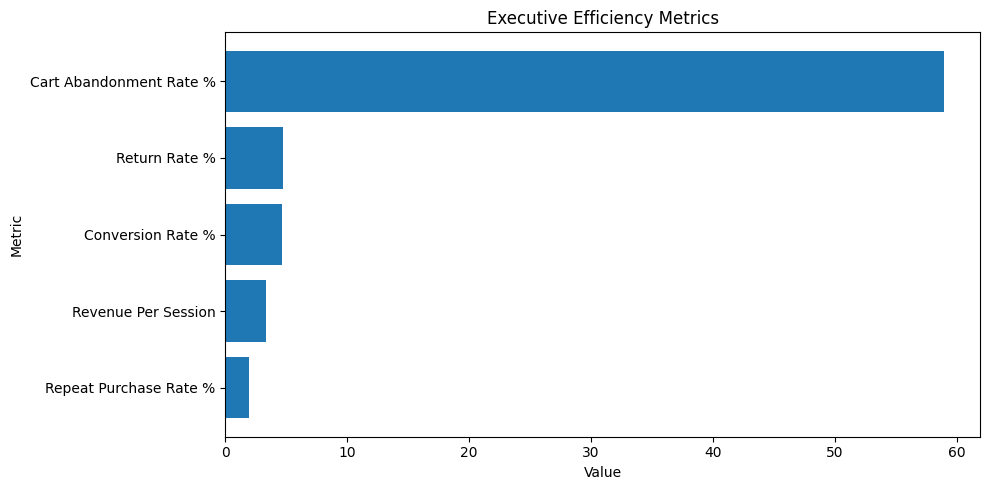

In [4]:
efficiency_metrics = executive_summary_df[
    executive_summary_df["metric"].isin([
        "Conversion Rate %",
        "Revenue Per Session",
        "Cart Abandonment Rate %",
        "Return Rate %",
        "Repeat Purchase Rate %"
    ])
].copy()

efficiency_metrics = efficiency_metrics.sort_values("value", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(efficiency_metrics["metric"], efficiency_metrics["value"])
plt.xlabel("Value")
plt.ylabel("Metric")
plt.title("Executive Efficiency Metrics")
plt.tight_layout()
plt.show()

# **Funnel insight analysis.**

In [5]:
funnel = data["bi_funnel_session_summary"].copy()

funnel["stage_count"] = pd.to_numeric(funnel["stage_count"], errors="coerce")
funnel["stage_conversion_rate_pct"] = pd.to_numeric(funnel["stage_conversion_rate_pct"], errors="coerce")
funnel["stage_dropoff_rate_pct"] = pd.to_numeric(funnel["stage_dropoff_rate_pct"], errors="coerce")
funnel["overall_conversion_from_session_pct"] = pd.to_numeric(
    funnel["overall_conversion_from_session_pct"], 
    errors="coerce"
)

funnel

,stage_order,stage_name,stage_count,previous_stage_count,stage_conversion_rate_pct,stage_dropoff_rate_pct,overall_conversion_from_session_pct
0,1,Total Sessions,350000.0,NaN,NaN,NaN,100.00
1,2,Sessions With Search,168730.0,350000.0,48.21,51.79,48.21
2,3,Sessions With Product Impression,162915.0,168730.0,96.55,3.45,46.55
3,4,Sessions With Click,126320.0,162915.0,77.54,22.46,36.09
4,5,Sessions With Cart,35592.0,126320.0,28.18,71.82,10.17
5,6,Sessions With Purchase,16248.0,35592.0,45.65,54.35,4.64


In [6]:
biggest_dropoff = funnel.dropna(subset=["stage_dropoff_rate_pct"]).sort_values(
    "stage_dropoff_rate_pct", 
    ascending=False
).head(1)

best_stage_conversion = funnel.dropna(subset=["stage_conversion_rate_pct"]).sort_values(
    "stage_conversion_rate_pct", 
    ascending=False
).head(1)

funnel_insights = pd.DataFrame({
    "insight": [
        "Biggest funnel drop-off stage",
        "Best stage conversion",
        "Overall session-to-purchase conversion"
    ],
    "stage": [
        biggest_dropoff["stage_name"].iloc[0],
        best_stage_conversion["stage_name"].iloc[0],
        "Total Sessions → Purchase"
    ],
    "value_pct": [
        biggest_dropoff["stage_dropoff_rate_pct"].iloc[0],
        best_stage_conversion["stage_conversion_rate_pct"].iloc[0],
        funnel.loc[funnel["stage_name"] == "Sessions With Purchase", "overall_conversion_from_session_pct"].iloc[0]
    ]
})

funnel_insights

,insight,stage,value_pct
0,Biggest funnel drop-off stage,Sessions With Cart,71.82
1,Best stage conversion,Sessions With Product Impression,96.55
2,Overall session-to-purchase conversion,Total Sessions → Purchase,4.64


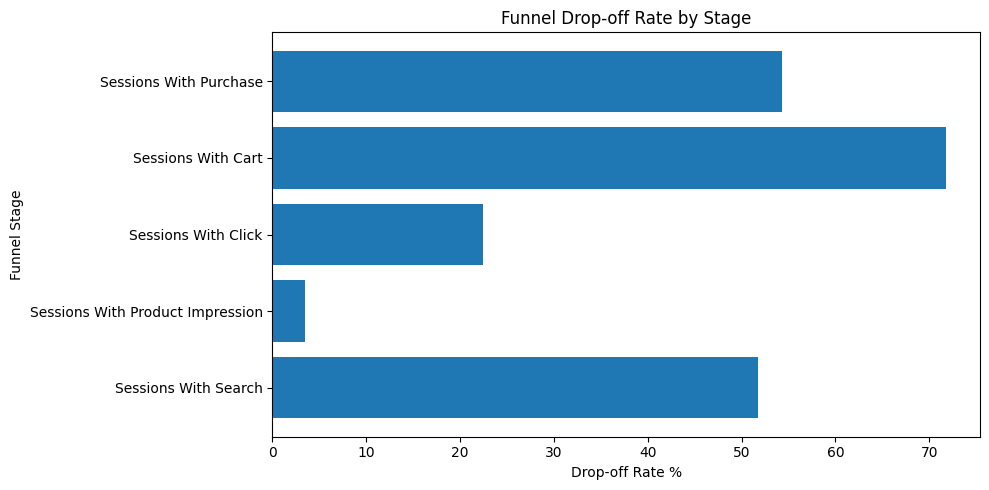

In [7]:
dropoff = funnel.dropna(subset=["stage_dropoff_rate_pct"]).copy()
dropoff = dropoff.sort_values("stage_order", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(dropoff["stage_name"], dropoff["stage_dropoff_rate_pct"])
plt.xlabel("Drop-off Rate %")
plt.ylabel("Funnel Stage")
plt.title("Funnel Drop-off Rate by Stage")
plt.tight_layout()
plt.show()

# **Search & Product Discovery insight analysis.**

In [8]:
search = data["bi_search_performance"].copy()

numeric_cols = [
    "total_searches",
    "zero_result_rate_pct",
    "impressions",
    "clicks",
    "cart_adds",
    "purchases",
    "revenue",
    "search_ctr_pct",
    "click_to_cart_rate_pct",
    "search_to_purchase_rate_pct",
    "revenue_per_search",
    "avg_clicked_rank"
]

for col in numeric_cols:
    search[col] = pd.to_numeric(search[col], errors="coerce")

search.head()

,search_query,total_searches,zero_result_searches,zero_result_rate_pct,impressions,clicks,cart_adds,purchases,revenue,search_ctr_pct,click_to_cart_rate_pct,search_to_purchase_rate_pct,revenue_per_search,avg_clicked_rank
0,face mask,6391,221.0,3.46,33894.0,8215.0,1462.0,606.0,41927.19,24.24,17.80,9.48,6.56,3.07
1,toner,6387,253.0,3.96,33732.0,8291.0,1564.0,655.0,34543.73,24.58,18.86,10.26,5.41,3.14
2,niacinamide,6378,199.0,3.12,34065.0,8591.0,1465.0,594.0,47979.09,25.22,17.05,9.31,7.52,3.12
3,retinol,6371,224.0,3.52,33778.0,8707.0,1519.0,619.0,65952.05,25.78,17.45,9.72,10.35,3.04
4,serum,6354,205.0,3.23,33694.0,8292.0,1484.0,591.0,57790.05,24.61,17.90,9.30,9.10,3.07


In [9]:
top_search_revenue = search.sort_values("revenue", ascending=False).head(10)

top_search_volume = search.sort_values("total_searches", ascending=False).head(10)

high_zero_result_queries = search.sort_values(
    "zero_result_rate_pct", 
    ascending=False
).head(10)

high_value_queries = search[
    search["total_searches"] >= search["total_searches"].median()
].sort_values("revenue_per_search", ascending=False).head(10)

search_insight_summary = pd.DataFrame({
    "insight": [
        "Top revenue search query",
        "Highest volume search query",
        "Highest zero-result query",
        "Best revenue per search query"
    ],
    "search_query": [
        top_search_revenue["search_query"].iloc[0],
        top_search_volume["search_query"].iloc[0],
        high_zero_result_queries["search_query"].iloc[0],
        high_value_queries["search_query"].iloc[0]
    ],
    "value": [
        top_search_revenue["revenue"].iloc[0],
        top_search_volume["total_searches"].iloc[0],
        high_zero_result_queries["zero_result_rate_pct"].iloc[0],
        high_value_queries["revenue_per_search"].iloc[0]
    ]
})

search_insight_summary

,insight,search_query,value
0,Top revenue search query,retinol,65952.05
1,Highest volume search query,face mask,6391.00
2,Highest zero-result query,kosas,6.28
3,Best revenue per search query,kate somerville,14.10


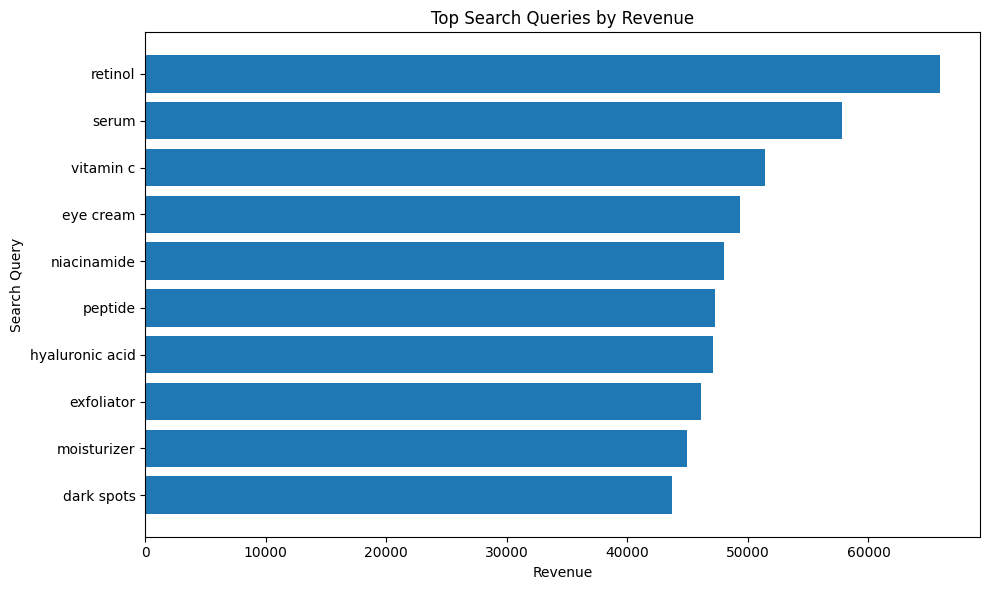

In [10]:
plot_df = top_search_revenue.sort_values("revenue", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(plot_df["search_query"], plot_df["revenue"])
plt.xlabel("Revenue")
plt.ylabel("Search Query")
plt.title("Top Search Queries by Revenue")
plt.tight_layout()
plt.show()

# **Product opportunity analysis.**

In [11]:
product = data["bi_product_ranking"].copy()

numeric_cols = [
    "price",
    "rating",
    "review_count",
    "loves_count",
    "impressions",
    "clicks",
    "cart_adds",
    "orders",
    "units_sold",
    "product_revenue",
    "ctr_pct",
    "click_to_cart_rate_pct",
    "click_to_purchase_rate_pct",
    "revenue_per_impression",
    "return_rate_pct",
    "stockout_rate_pct",
    "positive_review_pct",
    "negative_review_pct",
    "avg_stock_on_hand",
    "ranking_score"
]

for col in numeric_cols:
    product[col] = pd.to_numeric(product[col], errors="coerce")

product.head()

,product_id,product_name,brand_name,category,price,product_tier,rating,review_count,loves_count,impressions,...,click_to_cart_rate_pct,click_to_purchase_rate_pct,revenue_per_impression,return_rate_pct,stockout_rate_pct,positive_review_pct,negative_review_pct,avg_stock_on_hand,ranking_score,product_action_segment
0,P500881,Com Wand Vibrator,Dame,Bath & Body,125.0,luxury,4.7407,108,2570,16,...,33.33,33.33,27.73,0.0,0.0,0.0,0.0,81.386301,5.0,Hidden Gem
1,P501570,Mini Watermelon Glow AHA Night Treatment,Glow Recipe,Mini Size,21.0,budget,4.6795,730,24615,272,...,25.00,13.10,1.56,0.0,0.0,0.0,0.0,90.345205,5.0,Hero Product
2,P468718,Hydrating Curl Conditioner with Jojoba Oil,Virtue,Hair,42.0,premium,4.6761,71,1736,113,...,23.53,14.71,2.92,0.0,0.0,0.0,0.0,94.567123,5.0,Hero Product
3,P500317,Genesis Homme Thickening Shampoo for Men,Kérastase,Hair,40.0,premium,4.6413,92,1379,25,...,30.77,30.77,10.64,0.0,0.0,0.0,0.0,78.183562,5.0,Hidden Gem
4,P504774,Super Pure Clarifying Face Serum with Niacinam...,Glossier,Skincare,29.0,mid,4.5882,17,10568,139,...,19.61,13.73,1.62,0.0,0.0,90.0,0.0,80.769863,5.0,Hero Product


In [16]:
hero_products = product[
    product["product_action_segment"] == "Hero Product"
].sort_values("product_revenue", ascending=False).head(10)

hidden_gems = product[
    product["product_action_segment"] == "Hidden Gem"
].sort_values("ranking_score", ascending=False).head(10)

high_visibility_low_conversion = product[
    product["product_action_segment"] == "High Visibility Low Conversion"
].sort_values("impressions", ascending=False).head(10)

product_opportunity_summary = pd.DataFrame({
    "insight": [
        "Top hero product by revenue",
        "Top hidden gem by ranking score",
        "Highest visibility low-conversion product"
    ],
    "product_name": [
        hero_products["product_name"].iloc[0],
        hidden_gems["product_name"].iloc[0],
        high_visibility_low_conversion["product_name"].iloc[0]
    ],
    "brand_name": [
        hero_products["brand_name"].iloc[0],
        hidden_gems["brand_name"].iloc[0],
        high_visibility_low_conversion["brand_name"].iloc[0]
    ],
    "value": [
        hero_products["product_revenue"].iloc[0],
        hidden_gems["ranking_score"].iloc[0],
        high_visibility_low_conversion["impressions"].iloc[0]
    ]
})

product_opportunity_summary

,insight,product_name,brand_name,value
0,Top hero product by revenue,Face Mask,Dr. Barbara Sturm,6300.0
1,Top hidden gem by ranking score,Com Wand Vibrator,Dame,5.0
2,Highest visibility low-conversion product,Anti-Aging Skincare Essentials Set,Clarins,879.0


In [17]:
product_segment_summary = (
    product
    .groupby("product_action_segment")
    .agg(
        products=("product_id", "nunique"),
        revenue=("product_revenue", "sum"),
        avg_ranking_score=("ranking_score", "mean"),
        avg_ctr_pct=("ctr_pct", "mean"),
        avg_purchase_rate_pct=("click_to_purchase_rate_pct", "mean"),
        avg_return_rate_pct=("return_rate_pct", "mean")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

product_segment_summary

,product_action_segment,products,revenue,avg_ranking_score,avg_ctr_pct,avg_purchase_rate_pct,avg_return_rate_pct
0,Hero Product,1458,641167.90,3.868724,26.098484,11.622250,3.133841
3,Normal,5551,384348.64,2.863646,23.995069,5.526580,0.012845
4,Return / Review Risk,576,105574.47,3.097483,25.467934,5.462949,29.164375
1,Hidden Gem,436,40384.44,4.001835,27.438303,22.387919,0.535161
5,Stockout Revenue Risk,13,1577.85,2.911538,15.134615,8.069231,0.000000
2,High Visibility Low Conversion,460,0.00,2.291522,19.222457,0.000000,5.326087


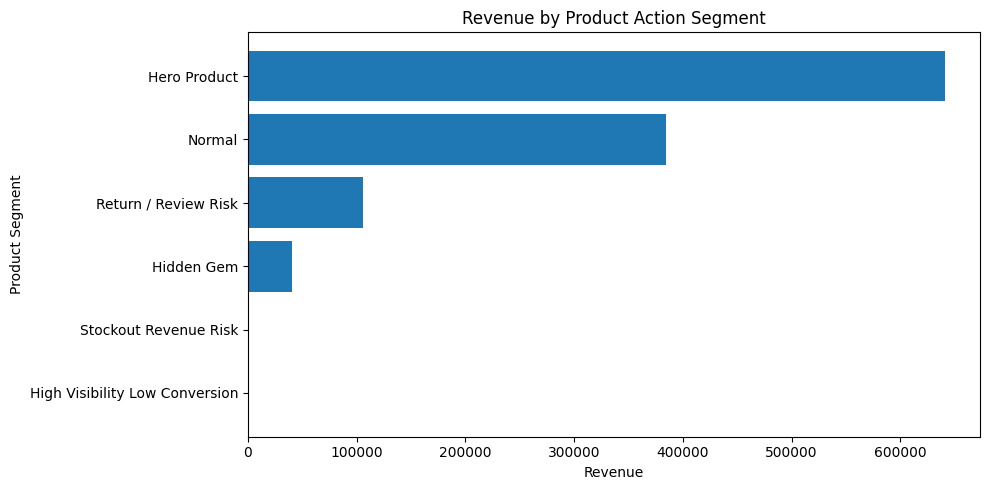

In [18]:
plot_df = product_segment_summary.sort_values("revenue", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["product_action_segment"], plot_df["revenue"])
plt.xlabel("Revenue")
plt.ylabel("Product Segment")
plt.title("Revenue by Product Action Segment")
plt.tight_layout()
plt.show()

# **Campaign efficiency analysis.**

In [19]:
campaign = data["bi_campaign_performance"].copy()

numeric_cols = [
    "daily_budget",
    "ad_spend",
    "ad_impressions",
    "ad_clicks",
    "sessions",
    "orders",
    "revenue",
    "avg_order_value",
    "ad_ctr_pct",
    "cpc",
    "cpa",
    "cac",
    "roas",
    "campaign_conversion_rate_pct",
    "revenue_per_session"
]

for col in numeric_cols:
    campaign[col] = pd.to_numeric(campaign[col], errors="coerce")

campaign.head()

,campaign_id,campaign_name,traffic_source,campaign_objective,start_date,end_date,daily_budget,ad_spend,ad_impressions,ad_clicks,...,revenue,avg_order_value,ad_ctr_pct,cpc,cpa,cac,roas,campaign_conversion_rate_pct,revenue_per_session,campaign_action_segment
0,cmp_0026,Sephora Campaign 0026,affiliate,retention,2023-01-17 16:19:02,2023-03-12 16:19:02,1213.43,65746.22,5777350.0,137406.0,...,30092.56,72.51,2.38,0.48,158.42,158.42,0.46,5.21,3.78,Low ROAS Campaign
1,cmp_0057,Sephora Campaign 0057,affiliate,retention,2023-03-28 03:12:32,2023-05-08 03:12:32,660.30,27768.45,2324635.0,61081.0,...,30019.05,74.30,2.63,0.45,68.73,68.73,1.08,5.09,3.78,Low ROAS Campaign
2,cmp_0002,Sephora Campaign 0002,affiliate,acquisition,2023-08-15 02:27:16,2023-09-05 02:27:16,917.09,19509.23,1620531.0,39550.0,...,27406.48,74.47,2.44,0.49,53.01,53.01,1.40,4.58,3.41,Low ROAS Campaign
3,cmp_0039,Sephora Campaign 0039,paid_social,retention,2023-02-08 20:06:32,2023-03-07 20:06:32,171.91,4687.40,367528.0,6473.0,...,16983.18,76.85,1.76,0.72,21.21,21.21,3.62,5.13,3.94,Efficient Campaign
4,cmp_0044,Sephora Campaign 0044,paid_social,promotion,2023-03-21 12:03:56,2023-04-22 12:03:56,639.56,19181.66,1645815.0,30163.0,...,16807.38,77.45,1.83,0.64,88.39,88.39,0.88,5.18,4.01,Low ROAS Campaign


In [20]:
campaign_source_summary = (
    campaign
    .groupby("traffic_source")
    .agg(
        campaigns=("campaign_id", "nunique"),
        ad_spend=("ad_spend", "sum"),
        revenue=("revenue", "sum"),
        orders=("orders", "sum"),
        avg_roas=("roas", "mean"),
        avg_cpa=("cpa", "mean"),
        avg_conversion_rate_pct=("campaign_conversion_rate_pct", "mean")
    )
    .reset_index()
)

campaign_source_summary["overall_roas"] = (
    campaign_source_summary["revenue"] / campaign_source_summary["ad_spend"]
).round(2)

campaign_source_summary = campaign_source_summary.sort_values(
    "overall_roas", 
    ascending=False
)

campaign_source_summary

,traffic_source,campaigns,ad_spend,revenue,orders,avg_roas,avg_cpa,avg_conversion_rate_pct,overall_roas
0,affiliate,3,113023.90,87518.09,1187,0.980000,93.386667,4.960000,0.77
6,paid_social,14,622236.38,197821.78,2702,0.862143,232.113571,4.617857,0.32
2,email,12,470141.21,144739.71,1998,0.674167,244.687500,4.484167,0.31
5,paid_search,18,1206034.80,239676.92,3363,0.296111,369.673333,4.665000,0.20
3,influencer,9,597625.26,79334.49,1135,0.250000,529.641111,4.761111,0.13
1,direct,8,0.00,0.00,0,NaN,NaN,NaN,NaN
4,organic,16,0.00,0.00,0,NaN,NaN,NaN,NaN


In [21]:
best_roas_source = campaign_source_summary.sort_values("overall_roas", ascending=False).head(1)
highest_spend_source = campaign_source_summary.sort_values("ad_spend", ascending=False).head(1)
top_revenue_campaign = campaign.sort_values("revenue", ascending=False).head(1)
lowest_roas_campaign = campaign[campaign["ad_spend"] > 0].sort_values("roas", ascending=True).head(1)

campaign_insight_summary = pd.DataFrame({
    "insight": [
        "Best traffic source by overall ROAS",
        "Highest spend traffic source",
        "Top revenue campaign",
        "Lowest ROAS paid campaign"
    ],
    "name": [
        best_roas_source["traffic_source"].iloc[0],
        highest_spend_source["traffic_source"].iloc[0],
        top_revenue_campaign["campaign_name"].iloc[0],
        lowest_roas_campaign["campaign_name"].iloc[0]
    ],
    "value": [
        best_roas_source["overall_roas"].iloc[0],
        highest_spend_source["ad_spend"].iloc[0],
        top_revenue_campaign["revenue"].iloc[0],
        lowest_roas_campaign["roas"].iloc[0]
    ]
})

campaign_insight_summary

,insight,name,value
0,Best traffic source by overall ROAS,affiliate,0.77
1,Highest spend traffic source,paid_search,1206034.80
2,Top revenue campaign,Sephora Campaign 0026,30092.56
3,Lowest ROAS paid campaign,Sephora Campaign 0033,0.06


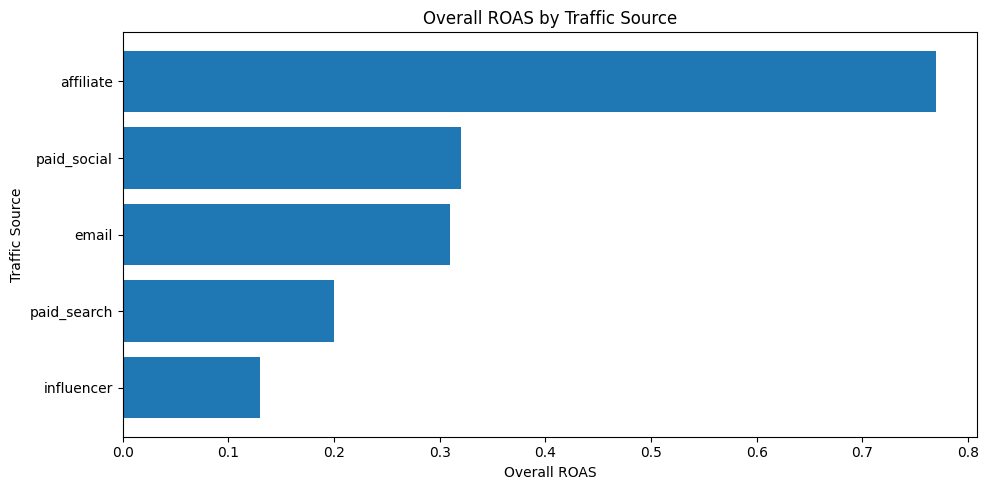

In [22]:
plot_df = campaign_source_summary.sort_values("overall_roas", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["traffic_source"], plot_df["overall_roas"])
plt.xlabel("Overall ROAS")
plt.ylabel("Traffic Source")
plt.title("Overall ROAS by Traffic Source")
plt.tight_layout()
plt.show()

# **Customer & Loyalty segment analysis.**

In [23]:
customer = data["bi_customer_segments"].copy()

numeric_cols = [
    "customers",
    "sessions",
    "orders",
    "revenue",
    "avg_order_value",
    "session_conversion_rate_pct",
    "revenue_per_customer",
    "sessions_per_customer",
    "purchasing_customers",
    "repeat_customers",
    "repeat_purchase_rate_pct",
    "avg_session_duration_sec"
]

for col in numeric_cols:
    customer[col] = pd.to_numeric(customer[col], errors="coerce")

customer.head()

,loyalty_status,preferred_channel,skin_type,customers,sessions,orders,revenue,avg_order_value,session_conversion_rate_pct,revenue_per_customer,sessions_per_customer,purchasing_customers,repeat_customers,repeat_purchase_rate_pct,avg_session_duration_sec,customer_action_segment
0,insider,web,combination,37542,23987.0,994.0,69375.86,69.79,4.14,1.85,0.64,986.0,8.0,0.81,102.75,Normal Segment
1,insider,app,combination,33832,21675.0,940.0,66325.01,70.56,4.34,1.96,0.64,932.0,8.0,0.86,102.90,Normal Segment
2,vib,web,combination,15200,15146.0,762.0,55991.76,73.48,5.03,3.68,1.00,743.0,18.0,2.42,136.44,High Conversion Segment
3,vib,app,combination,13592,13374.0,684.0,49963.57,73.05,5.11,3.68,0.98,663.0,21.0,3.17,136.90,High Conversion Segment
4,non_member,web,combination,31078,15012.0,621.0,43609.17,70.22,4.14,1.40,0.48,614.0,7.0,1.14,83.32,Normal Segment


In [24]:
loyalty_summary = (
    customer
    .groupby("loyalty_status")
    .agg(
        customers=("customers", "sum"),
        sessions=("sessions", "sum"),
        orders=("orders", "sum"),
        revenue=("revenue", "sum"),
        avg_conversion_rate_pct=("session_conversion_rate_pct", "mean"),
        avg_revenue_per_customer=("revenue_per_customer", "mean"),
        avg_repeat_purchase_rate_pct=("repeat_purchase_rate_pct", "mean")
    )
    .reset_index()
    .sort_values("revenue", ascending=False)
)

loyalty_summary

,loyalty_status,customers,sessions,orders,revenue,avg_conversion_rate_pct,avg_revenue_per_customer,avg_repeat_purchase_rate_pct
0,insider,211616,135644.0,5943.0,423712.29,4.2730,1.9555,1.3835
3,vib,85604,84742.0,4310.0,311788.08,5.0875,3.5180,2.3055
1,non_member,175793,84872.0,3542.0,259439.02,4.1345,1.4980,0.7115
2,rouge,30203,44742.0,2453.0,178113.91,5.4680,5.9880,4.0975


In [25]:
top_revenue_loyalty = loyalty_summary.sort_values("revenue", ascending=False).head(1)
best_conversion_loyalty = loyalty_summary.sort_values("avg_conversion_rate_pct", ascending=False).head(1)
best_rpc_loyalty = loyalty_summary.sort_values("avg_revenue_per_customer", ascending=False).head(1)

top_customer_segment = customer.sort_values("revenue", ascending=False).head(1)

customer_insight_summary = pd.DataFrame({
    "insight": [
        "Top loyalty group by revenue",
        "Best loyalty group by conversion",
        "Best loyalty group by revenue/customer",
        "Top customer micro-segment by revenue"
    ],
    "segment": [
        top_revenue_loyalty["loyalty_status"].iloc[0],
        best_conversion_loyalty["loyalty_status"].iloc[0],
        best_rpc_loyalty["loyalty_status"].iloc[0],
        (
            top_customer_segment["loyalty_status"].iloc[0] + " + " +
            top_customer_segment["preferred_channel"].iloc[0] + " + " +
            top_customer_segment["skin_type"].iloc[0]
        )
    ],
    "value": [
        top_revenue_loyalty["revenue"].iloc[0],
        best_conversion_loyalty["avg_conversion_rate_pct"].iloc[0],
        best_rpc_loyalty["avg_revenue_per_customer"].iloc[0],
        top_customer_segment["revenue"].iloc[0]
    ]
})

customer_insight_summary

,insight,segment,value
0,Top loyalty group by revenue,insider,423712.290
1,Best loyalty group by conversion,rouge,5.468
2,Best loyalty group by revenue/customer,rouge,5.988
3,Top customer micro-segment by revenue,insider + web + combination,69375.860


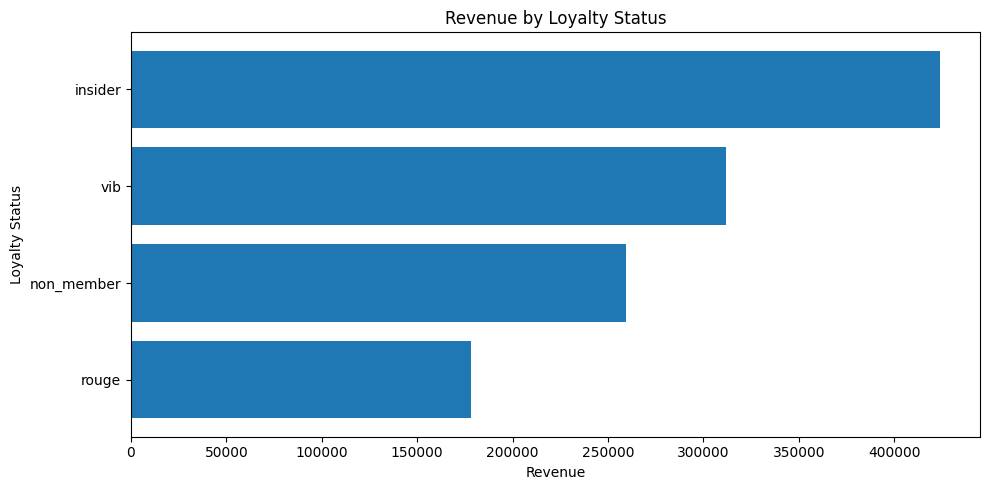

In [26]:
plot_df = loyalty_summary.sort_values("revenue", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["loyalty_status"], plot_df["revenue"])
plt.xlabel("Revenue")
plt.ylabel("Loyalty Status")
plt.title("Revenue by Loyalty Status")
plt.tight_layout()
plt.show()

# **Inventory risk analysis.**

In [27]:
inventory = data["bi_inventory_risk"].copy()

numeric_cols = [
    "price",
    "rating",
    "review_count",
    "loves_count",
    "units_sold",
    "revenue",
    "orders",
    "impressions",
    "clicks",
    "avg_stock_on_hand",
    "min_stock_on_hand",
    "max_stock_on_hand",
    "latest_stock_on_hand",
    "total_replenishment_units",
    "total_units_reserved",
    "avg_daily_demand",
    "stockout_days",
    "inventory_days",
    "stockout_rate_pct",
    "ctr_pct",
    "days_of_supply",
    "estimated_lost_revenue_risk"
]

for col in numeric_cols:
    inventory[col] = pd.to_numeric(inventory[col], errors="coerce")

inventory.head()

,product_id,product_name,brand_name,category,price,product_tier,rating,review_count,loves_count,units_sold,...,total_replenishment_units,total_units_reserved,avg_daily_demand,stockout_days,inventory_days,stockout_rate_pct,ctr_pct,days_of_supply,estimated_lost_revenue_risk,inventory_action_segment
0,P395417,Touch Home Permanent Hair Removal Device,iluminage,Skincare,449.0,luxury,3.67000,100,14204,0.0,...,431.0,602.0,1.65,365.0,365,100.0,11.76,34.56,270298.0,Currently Out of Stock
1,P402992,Trinity + Eye and Lip Enhancer Attachment Bundle,NuFACE,Skincare,429.0,luxury,3.43810,105,4122,0.0,...,424.0,555.0,1.52,365.0,365,100.0,21.05,37.49,238095.0,Currently Out of Stock
2,P402993,Trinity Facial Toning Device + Wrinkle Reducer...,NuFACE,Skincare,429.0,luxury,3.66670,9,2112,0.0,...,390.0,508.0,1.39,365.0,365,100.0,20.00,18.68,217932.0,Currently Out of Stock
3,P504676,NuFACE Trinity+ & Effective Lip and Eye Attach...,NuFACE,Skincare,495.0,luxury,4.28935,0,760,0.0,...,398.0,416.0,1.14,365.0,365,100.0,14.06,93.88,205920.0,Currently Out of Stock
4,P417192,Myrrh & Tonka Cologne Intense,Jo Malone London,Fragrance,220.0,luxury,4.46750,77,16410,0.0,...,578.0,686.0,1.88,365.0,365,100.0,4.55,56.40,150920.0,Currently Out of Stock


In [28]:
inventory_segment_summary = (
    inventory
    .groupby("inventory_action_segment")
    .agg(
        products=("product_id", "nunique"),
        revenue=("revenue", "sum"),
        avg_stockout_rate_pct=("stockout_rate_pct", "mean"),
        avg_days_of_supply=("days_of_supply", "mean"),
        estimated_lost_revenue_risk=("estimated_lost_revenue_risk", "sum")
    )
    .reset_index()
    .sort_values("estimated_lost_revenue_risk", ascending=False)
)

inventory_segment_summary

,inventory_action_segment,products,revenue,avg_stockout_rate_pct,avg_days_of_supply,estimated_lost_revenue_risk
1,Currently Out of Stock,732,19267.22,85.858607,34.049713,17494979.94
3,Normal,6289,920597.63,1.048480,42.825079,2099648.84
2,Low Stock,1194,185251.83,0.950980,10.428861,360219.49
0,Critical Low Stock,279,47936.62,1.026953,3.820215,86493.03


In [29]:
top_lost_revenue_product = inventory.sort_values(
    "estimated_lost_revenue_risk", 
    ascending=False
).head(1)

highest_stockout_category = (
    inventory
    .groupby("category")
    .agg(avg_stockout_rate_pct=("stockout_rate_pct", "mean"))
    .reset_index()
    .sort_values("avg_stockout_rate_pct", ascending=False)
    .head(1)
)

out_of_stock_products = inventory[
    inventory["inventory_action_segment"] == "Currently Out of Stock"
]["product_id"].nunique()

inventory_insight_summary = pd.DataFrame({
    "insight": [
        "Products currently out of stock",
        "Top lost revenue risk product",
        "Highest stockout category",
        "Total estimated lost revenue risk"
    ],
    "name": [
        out_of_stock_products,
        top_lost_revenue_product["product_name"].iloc[0],
        highest_stockout_category["category"].iloc[0],
        inventory["estimated_lost_revenue_risk"].sum()
    ],
    "value": [
        out_of_stock_products,
        top_lost_revenue_product["estimated_lost_revenue_risk"].iloc[0],
        highest_stockout_category["avg_stockout_rate_pct"].iloc[0],
        inventory["estimated_lost_revenue_risk"].sum()
    ]
})

inventory_insight_summary

,insight,name,value
0,Products currently out of stock,732,7.320000e+02
1,Top lost revenue risk product,Touch Home Permanent Hair Removal Device,2.702980e+05
2,Highest stockout category,Mini Size,1.174865e+01
3,Total estimated lost revenue risk,20041341.3,2.004134e+07


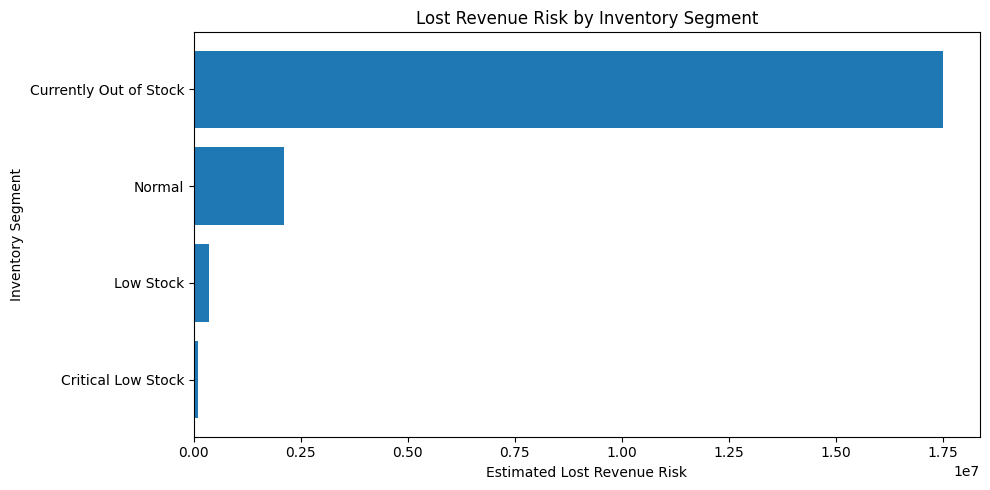

In [30]:
plot_df = inventory_segment_summary.sort_values(
    "estimated_lost_revenue_risk", 
    ascending=True
)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["inventory_action_segment"], plot_df["estimated_lost_revenue_risk"])
plt.xlabel("Estimated Lost Revenue Risk")
plt.ylabel("Inventory Segment")
plt.title("Lost Revenue Risk by Inventory Segment")
plt.tight_layout()
plt.show()

# **Recommendation performance analysis.**

In [31]:
recommendation = data["bi_recommendation_performance"].copy()

numeric_cols = [
    "recommendation_impressions",
    "recommendation_clicks",
    "recommendation_purchases",
    "sessions_reached",
    "customers_reached",
    "recommendation_ctr_pct",
    "recommendation_cvr_pct",
    "recommendation_purchase_rate_pct",
    "avg_rec_rank",
    "avg_product_price",
    "avg_product_rating",
    "total_loves_signal"
]

for col in numeric_cols:
    recommendation[col] = pd.to_numeric(recommendation[col], errors="coerce")

recommendation.head()

,placement,device_type,traffic_source,brand_name,category,recommendation_impressions,recommendation_clicks,recommendation_purchases,sessions_reached,customers_reached,recommendation_ctr_pct,recommendation_cvr_pct,recommendation_purchase_rate_pct,avg_rec_rank,avg_product_price,avg_product_rating,total_loves_signal,recommendation_action_segment
0,pdp_similar,mobile_app,organic,SEPHORA COLLECTION,Makeup,308,53.0,13.0,290,290,17.21,24.53,4.22,2.66,16.60,4.21,21041589.0,Normal Recommendation Segment
1,pdp_similar,mobile_app,paid_search,SEPHORA COLLECTION,Makeup,335,62.0,12.0,323,323,18.51,19.35,3.58,2.73,16.47,4.17,18382811.0,Normal Recommendation Segment
2,home_recs,mobile_web,organic,SEPHORA COLLECTION,Makeup,273,43.0,11.0,262,262,15.75,25.58,4.03,2.70,17.14,4.14,15498308.0,Normal Recommendation Segment
3,pdp_similar,mobile_app,direct,Anastasia Beverly Hills,Makeup,96,21.0,10.0,94,94,21.88,47.62,10.42,2.83,26.23,4.25,6982927.0,Strong Recommendation Segment
4,home_recs,mobile_app,paid_social,SEPHORA COLLECTION,Makeup,273,55.0,10.0,262,262,20.15,18.18,3.66,2.69,17.38,4.22,18982908.0,Strong Recommendation Segment


In [32]:
recommendation_placement_summary = (
    recommendation
    .groupby("placement")
    .agg(
        impressions=("recommendation_impressions", "sum"),
        clicks=("recommendation_clicks", "sum"),
        purchases=("recommendation_purchases", "sum"),
        avg_ctr_pct=("recommendation_ctr_pct", "mean"),
        avg_cvr_pct=("recommendation_cvr_pct", "mean"),
        avg_purchase_rate_pct=("recommendation_purchase_rate_pct", "mean")
    )
    .reset_index()
)

recommendation_placement_summary["overall_ctr_pct"] = (
    recommendation_placement_summary["clicks"] * 100 /
    recommendation_placement_summary["impressions"]
).round(2)

recommendation_placement_summary["overall_cvr_pct"] = (
    recommendation_placement_summary["purchases"] * 100 /
    recommendation_placement_summary["clicks"]
).round(2)

recommendation_placement_summary = recommendation_placement_summary.sort_values(
    "purchases", 
    ascending=False
)

recommendation_placement_summary

,placement,impressions,clicks,purchases,avg_ctr_pct,avg_cvr_pct,avg_purchase_rate_pct,overall_ctr_pct,overall_cvr_pct
3,pdp_similar,181234,30555.0,5258.0,16.516644,16.904888,2.789637,16.86,17.21
2,home_recs,158701,27025.0,4488.0,16.889760,16.324538,2.793961,17.03,16.61
0,cart_cross_sell,96047,16443.0,2772.0,17.007617,17.084381,2.951647,17.12,16.86
1,email_recs,95397,16319.0,2749.0,16.782658,16.516480,2.813544,17.11,16.85


In [33]:
best_purchase_placement = recommendation_placement_summary.sort_values(
    "purchases", 
    ascending=False
).head(1)

best_ctr_placement = recommendation_placement_summary.sort_values(
    "overall_ctr_pct", 
    ascending=False
).head(1)

best_cvr_placement = recommendation_placement_summary.sort_values(
    "overall_cvr_pct", 
    ascending=False
).head(1)

top_recommended_brand = (
    recommendation
    .groupby("brand_name")
    .agg(
        purchases=("recommendation_purchases", "sum"),
        impressions=("recommendation_impressions", "sum")
    )
    .reset_index()
    .sort_values("purchases", ascending=False)
    .head(1)
)

recommendation_insight_summary = pd.DataFrame({
    "insight": [
        "Top placement by purchases",
        "Best placement by CTR",
        "Best placement by CVR",
        "Top recommended brand by purchases"
    ],
    "name": [
        best_purchase_placement["placement"].iloc[0],
        best_ctr_placement["placement"].iloc[0],
        best_cvr_placement["placement"].iloc[0],
        top_recommended_brand["brand_name"].iloc[0]
    ],
    "value": [
        best_purchase_placement["purchases"].iloc[0],
        best_ctr_placement["overall_ctr_pct"].iloc[0],
        best_cvr_placement["overall_cvr_pct"].iloc[0],
        top_recommended_brand["purchases"].iloc[0]
    ]
})

recommendation_insight_summary

,insight,name,value
0,Top placement by purchases,pdp_similar,5258.00
1,Best placement by CTR,cart_cross_sell,17.12
2,Best placement by CVR,pdp_similar,17.21
3,Top recommended brand by purchases,SEPHORA COLLECTION,640.00


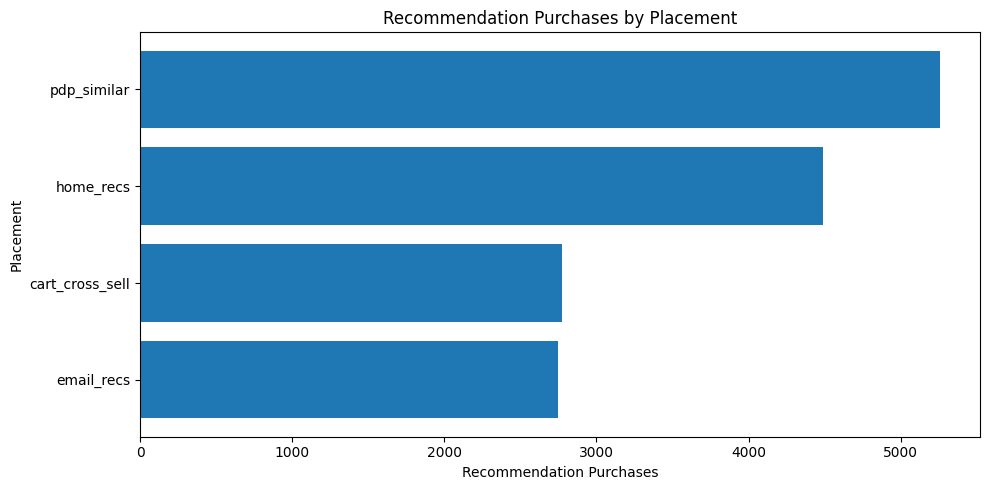

In [34]:
plot_df = recommendation_placement_summary.sort_values("purchases", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["placement"], plot_df["purchases"])
plt.xlabel("Recommendation Purchases")
plt.ylabel("Placement")
plt.title("Recommendation Purchases by Placement")
plt.tight_layout()
plt.show()

# **Review & Sentiment analysis.**

In [35]:
review = data["bi_review_sentiment"].copy()

numeric_cols = [
    "price",
    "catalog_rating",
    "catalog_review_count",
    "loves_count",
    "review_rows",
    "reviewing_customers",
    "avg_review_rating",
    "positive_reviews",
    "neutral_reviews",
    "negative_reviews",
    "positive_review_pct",
    "neutral_review_pct",
    "negative_review_pct",
    "five_star_reviews",
    "four_star_reviews",
    "three_star_reviews",
    "two_star_reviews",
    "one_star_reviews",
    "skin_type_coverage",
    "skin_tone_coverage"
]

for col in numeric_cols:
    review[col] = pd.to_numeric(review[col], errors="coerce")

review.head()

,product_id,product_name,brand_name,category,price,product_tier,catalog_rating,catalog_review_count,loves_count,review_rows,...,neutral_review_pct,negative_review_pct,five_star_reviews,four_star_reviews,three_star_reviews,two_star_reviews,one_star_reviews,skin_type_coverage,skin_tone_coverage,review_action_segment
0,P420652,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,Skincare,24.0,budget,4.3508,16118,1081315,16138,...,6.61,11.52,11420.0,1793.0,1066.0,879.0,980.0,5,14,Normal Review Profile
1,P7880,Soy Hydrating Gentle Face Cleanser,fresh,Skincare,39.0,premium,4.3628,8733,282865,8736,...,6.82,9.62,5852.0,1448.0,596.0,432.0,408.0,5,12,Normal Review Profile
2,P218700,100 percent Pure Argan Oil,Josie Maran,Skincare,49.0,premium,4.4998,7763,134089,7763,...,4.83,6.92,5595.0,1256.0,375.0,271.0,266.0,5,10,Loved Product
3,P248407,Ultra Repair Cream Intense Hydration,First Aid Beauty,Skincare,38.0,premium,4.5200,7539,300432,7547,...,4.89,7.43,5702.0,915.0,369.0,263.0,298.0,5,12,Loved Product
4,P269122,Alpha Beta Extra Strength Daily Peel Pads,Dr. Dennis Gross Skincare,Skincare,92.0,luxury,4.5455,7412,234295,7414,...,4.45,4.24,5184.0,1586.0,330.0,129.0,185.0,5,13,Loved Product


In [36]:
review_segment_summary = (
    review
    .groupby("review_action_segment")
    .agg(
        products=("product_id", "nunique"),
        total_reviews=("review_rows", "sum"),
        avg_rating=("avg_review_rating", "mean"),
        avg_positive_pct=("positive_review_pct", "mean"),
        avg_negative_pct=("negative_review_pct", "mean"),
        total_negative_reviews=("negative_reviews", "sum")
    )
    .reset_index()
    .sort_values("total_reviews", ascending=False)
)

review_segment_summary

,review_action_segment,products,total_reviews,avg_rating,avg_positive_pct,avg_negative_pct,total_negative_reviews
4,Normal Review Profile,1299,665435,4.180608,77.909869,13.437960,84063.0
1,Loved Product,643,545612,4.558911,90.445599,4.509487,27954.0
0,High Complaint Risk,147,86201,3.661020,62.439116,26.973061,22920.0
3,Low Satisfaction Product,124,2857,3.036371,43.201048,42.338871,1134.0
2,Low Review Hidden Gem,138,1031,4.788116,95.283406,2.570942,33.0


In [37]:
most_reviewed_product = review.sort_values("review_rows", ascending=False).head(1)

highest_negative_product = review[
    review["review_rows"] >= 100
].sort_values("negative_review_pct", ascending=False).head(1)

top_loved_product = review[
    review["review_action_segment"] == "Loved Product"
].sort_values("positive_review_pct", ascending=False).head(1)

review_insight_summary = pd.DataFrame({
    "insight": [
        "Most reviewed product",
        "Highest negative review product",
        "Top loved product",
        "Total review rows"
    ],
    "product_name": [
        most_reviewed_product["product_name"].iloc[0],
        highest_negative_product["product_name"].iloc[0],
        top_loved_product["product_name"].iloc[0],
        "All products"
    ],
    "brand_name": [
        most_reviewed_product["brand_name"].iloc[0],
        highest_negative_product["brand_name"].iloc[0],
        top_loved_product["brand_name"].iloc[0],
        "-"
    ],
    "value": [
        most_reviewed_product["review_rows"].iloc[0],
        highest_negative_product["negative_review_pct"].iloc[0],
        top_loved_product["positive_review_pct"].iloc[0],
        review["review_rows"].sum()
    ]
})

review_insight_summary

,insight,product_name,brand_name,value
0,Most reviewed product,Lip Sleeping Mask Intense Hydration with Vitam...,LANEIGE,16138.00
1,Highest negative review product,Clean Lip Balm & Scrub,SEPHORA COLLECTION,64.65
2,Top loved product,Equilibrium Resurfacing Retinoid Treatment,Hourglass,100.00
3,Total review rows,All products,-,1301136.00


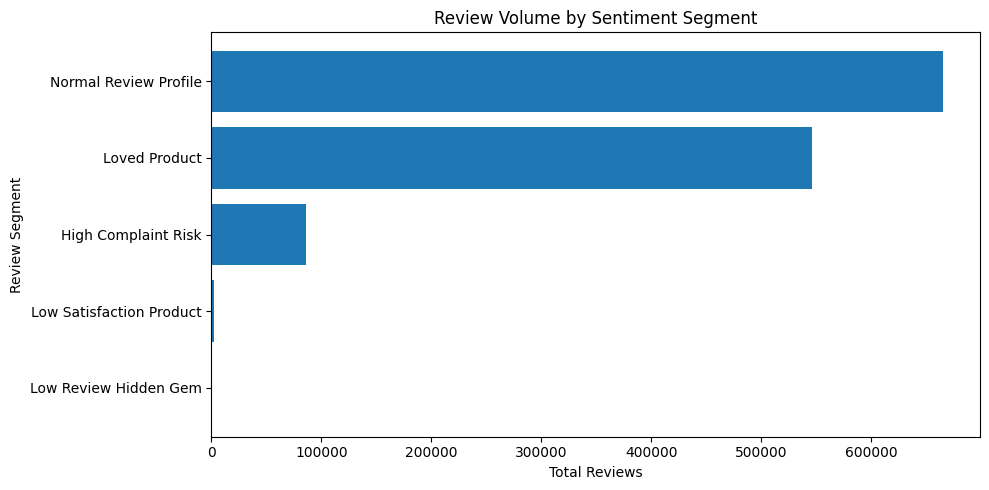

In [39]:
plot_df = review_segment_summary.sort_values("total_reviews", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_df["review_action_segment"], plot_df["total_reviews"])
plt.xlabel("Total Reviews")
plt.ylabel("Review Segment")
plt.title("Review Volume by Sentiment Segment")
plt.tight_layout()
plt.show()

# **final insight summary table.**

In [40]:
final_insights = pd.DataFrame([
    {
        "area": "Executive",
        "key_insight": "Business generated 1.17M revenue from 350K sessions with 4.64% conversion.",
        "business_action": "Use executive KPIs to track overall ecommerce health."
    },
    {
        "area": "Funnel",
        "key_insight": "Biggest funnel drop-off is at cart stage with 71.82% drop-off.",
        "business_action": "Improve cart experience, checkout trust, offers, and product-page-to-cart flow."
    },
    {
        "area": "Search",
        "key_insight": "Retinol is the top revenue query, while Kosas has the highest zero-result rate.",
        "business_action": "Boost high-revenue search terms and fix zero-result brand/query gaps."
    },
    {
        "area": "Product Discovery",
        "key_insight": "Hero Products drive 641K revenue, while Hidden Gems have high ranking score but lower visibility.",
        "business_action": "Protect Hero Products and promote Hidden Gems in search and recommendations."
    },
    {
        "area": "Campaigns",
        "key_insight": "Paid search has the highest spend but weak ROAS; affiliate has the best ROAS.",
        "business_action": "Reallocate budget toward efficient channels and optimize low-ROAS campaigns."
    },
    {
        "area": "Customers",
        "key_insight": "Insiders drive the most revenue, but Rouge customers have the highest conversion and revenue per customer.",
        "business_action": "Grow Rouge-like behavior through loyalty nudges and personalized offers."
    },
    {
        "area": "Inventory",
        "key_insight": "732 products are currently out of stock, creating 20.04M estimated lost revenue risk.",
        "business_action": "Prioritize replenishment for high-risk products and categories."
    },
    {
        "area": "Recommendations",
        "key_insight": "PDP similar recommendations drive the most purchases; cart cross-sell has the best CTR.",
        "business_action": "Use PDP recommendations for conversion and cart recommendations for engagement."
    },
    {
        "area": "Reviews",
        "key_insight": "Loved Products show 90.45% positive sentiment, while complaint-risk products show 26.97% negative sentiment.",
        "business_action": "Use review signals to boost loved products and investigate complaint-risk products."
    }
])

final_insights

,area,key_insight,business_action
0,Executive,Business generated 1.17M revenue from 350K ses...,Use executive KPIs to track overall ecommerce ...
1,Funnel,Biggest funnel drop-off is at cart stage with ...,"Improve cart experience, checkout trust, offer..."
2,Search,"Retinol is the top revenue query, while Kosas ...",Boost high-revenue search terms and fix zero-r...
3,Product Discovery,"Hero Products drive 641K revenue, while Hidden...",Protect Hero Products and promote Hidden Gems ...
4,Campaigns,Paid search has the highest spend but weak ROA...,Reallocate budget toward efficient channels an...
5,Customers,"Insiders drive the most revenue, but Rouge cus...",Grow Rouge-like behavior through loyalty nudge...
6,Inventory,"732 products are currently out of stock, creat...",Prioritize replenishment for high-risk product...
7,Recommendations,PDP similar recommendations drive the most pur...,Use PDP recommendations for conversion and car...
8,Reviews,"Loved Products show 90.45% positive sentiment,...",Use review signals to boost loved products and...


# **Save all Advance Final Insights to Zip**

In [42]:
final_insights.to_csv(
    "/kaggle/working/python_final_insights.csv",
    index=False
)

print("Saved: /kaggle/working/python_final_insights.csv")

Saved: /kaggle/working/python_final_insights.csv


# **Creating New folder to save sql views**

In [1]:
import os

SQL_DIR = "/kaggle/working/sql"
os.makedirs(SQL_DIR, exist_ok=True)

print("SQL folder created:", SQL_DIR)

SQL folder created: /kaggle/working/sql


# **Create and Save 1_data_quality_checks.sql**

In [2]:
sql_01_data_quality_checks = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 01_data_quality_checks.sql
Purpose:
    This script performs basic data quality checks on the final industry-style
    Sephora ecommerce dataset.

Checks included:
    1. Table row counts
    2. Primary key duplicate checks
    3. Null percentage checks
    4. Business rule checks
*/

-- ============================================================
-- 1. TABLE ROW COUNTS
-- ============================================================

SELECT 'dim_product' AS table_name, COUNT(*) AS row_count FROM dim_product
UNION ALL
SELECT 'dim_brand', COUNT(*) FROM dim_brand
UNION ALL
SELECT 'dim_customer', COUNT(*) FROM dim_customer
UNION ALL
SELECT 'dim_campaign', COUNT(*) FROM dim_campaign
UNION ALL
SELECT 'fact_reviews', COUNT(*) FROM fact_reviews
UNION ALL
SELECT 'fact_sessions', COUNT(*) FROM fact_sessions
UNION ALL
SELECT 'fact_search_events', COUNT(*) FROM fact_search_events
UNION ALL
SELECT 'fact_product_impressions', COUNT(*) FROM fact_product_impressions
UNION ALL
SELECT 'fact_clicks', COUNT(*) FROM fact_clicks
UNION ALL
SELECT 'fact_cart_events', COUNT(*) FROM fact_cart_events
UNION ALL
SELECT 'fact_orders', COUNT(*) FROM fact_orders
UNION ALL
SELECT 'fact_order_items', COUNT(*) FROM fact_order_items
UNION ALL
SELECT 'fact_recommendation_events', COUNT(*) FROM fact_recommendation_events
UNION ALL
SELECT 'fact_inventory_daily', COUNT(*) FROM fact_inventory_daily
UNION ALL
SELECT 'fact_campaign_spend_daily', COUNT(*) FROM fact_campaign_spend_daily;


-- ============================================================
-- 2. PRIMARY KEY DUPLICATE CHECKS
-- ============================================================

WITH key_checks AS (

    SELECT
        'dim_brand' AS table_name,
        'brand_id' AS key_column,
        COUNT(*) AS total_rows,
        COUNT(DISTINCT brand_id) AS unique_keys
    FROM dim_brand

    UNION ALL

    SELECT
        'dim_campaign',
        'campaign_id',
        COUNT(*),
        COUNT(DISTINCT campaign_id)
    FROM dim_campaign

    UNION ALL

    SELECT
        'dim_customer',
        'customer_id',
        COUNT(*),
        COUNT(DISTINCT customer_id)
    FROM dim_customer

    UNION ALL

    SELECT
        'dim_product',
        'product_id',
        COUNT(*),
        COUNT(DISTINCT product_id)
    FROM dim_product

    UNION ALL

    SELECT
        'fact_cart_events',
        'cart_event_id',
        COUNT(*),
        COUNT(DISTINCT cart_event_id)
    FROM fact_cart_events

    UNION ALL

    SELECT
        'fact_clicks',
        'click_id',
        COUNT(*),
        COUNT(DISTINCT click_id)
    FROM fact_clicks

    UNION ALL

    SELECT
        'fact_orders',
        'order_id',
        COUNT(*),
        COUNT(DISTINCT order_id)
    FROM fact_orders

    UNION ALL

    SELECT
        'fact_product_impressions',
        'impression_id',
        COUNT(*),
        COUNT(DISTINCT impression_id)
    FROM fact_product_impressions

    UNION ALL

    SELECT
        'fact_recommendation_events',
        'recommendation_event_id',
        COUNT(*),
        COUNT(DISTINCT recommendation_event_id)
    FROM fact_recommendation_events

    UNION ALL

    SELECT
        'fact_reviews',
        'review_id',
        COUNT(*),
        COUNT(DISTINCT review_id)
    FROM fact_reviews

    UNION ALL

    SELECT
        'fact_search_events',
        'search_event_id',
        COUNT(*),
        COUNT(DISTINCT search_event_id)
    FROM fact_search_events

    UNION ALL

    SELECT
        'fact_sessions',
        'session_id',
        COUNT(*),
        COUNT(DISTINCT session_id)
    FROM fact_sessions
)

SELECT
    table_name,
    key_column,
    total_rows,
    unique_keys,
    total_rows - unique_keys AS duplicate_keys,
    CASE
        WHEN total_rows = unique_keys THEN 'pass'
        ELSE 'fail'
    END AS status
FROM key_checks
ORDER BY table_name;


-- ============================================================
-- 3. IMPORTANT NULL CHECKS
-- ============================================================

SELECT
    'dim_product' AS table_name,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) AS null_product_id,
    SUM(CASE WHEN product_name IS NULL THEN 1 ELSE 0 END) AS null_product_name,
    SUM(CASE WHEN brand_name IS NULL THEN 1 ELSE 0 END) AS null_brand_name,
    SUM(CASE WHEN category IS NULL THEN 1 ELSE 0 END) AS null_category,
    SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) AS null_price
FROM dim_product;

SELECT
    'dim_customer' AS table_name,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS null_customer_id,
    SUM(CASE WHEN loyalty_status IS NULL THEN 1 ELSE 0 END) AS null_loyalty_status,
    SUM(CASE WHEN preferred_channel IS NULL THEN 1 ELSE 0 END) AS null_preferred_channel
FROM dim_customer;

SELECT
    'fact_sessions' AS table_name,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN session_id IS NULL THEN 1 ELSE 0 END) AS null_session_id,
    SUM(CASE WHEN customer_id IS NULL THEN 1 ELSE 0 END) AS null_customer_id,
    SUM(CASE WHEN channel IS NULL THEN 1 ELSE 0 END) AS null_channel,
    SUM(CASE WHEN traffic_source IS NULL THEN 1 ELSE 0 END) AS null_traffic_source
FROM fact_sessions;

SELECT
    'dim_campaign' AS table_name,
    COUNT(*) AS total_rows,
    SUM(CASE WHEN campaign_id IS NULL THEN 1 ELSE 0 END) AS null_campaign_id,
    SUM(CASE WHEN traffic_source IS NULL THEN 1 ELSE 0 END) AS null_traffic_source,
    SUM(CASE WHEN campaign_objective IS NULL THEN 1 ELSE 0 END) AS null_campaign_objective,
    SUM(CASE WHEN daily_budget IS NULL THEN 1 ELSE 0 END) AS null_daily_budget
FROM dim_campaign;


-- ============================================================
-- 4. BUSINESS RULE CHECKS
-- ============================================================

SELECT
    'Product price <= 0' AS check_name,
    COUNT(*) AS bad_rows
FROM dim_product
WHERE price <= 0

UNION ALL

SELECT
    'Product rating outside 0-5',
    COUNT(*)
FROM dim_product
WHERE rating < 0 OR rating > 5

UNION ALL

SELECT
    'Order total < 0',
    COUNT(*)
FROM fact_orders
WHERE order_total < 0

UNION ALL

SELECT
    'Net revenue < 0',
    COUNT(*)
FROM fact_orders
WHERE net_revenue < 0

UNION ALL

SELECT
    'Inventory stock < 0',
    COUNT(*)
FROM fact_inventory_daily
WHERE stock_on_hand < 0

UNION ALL

SELECT
    'Session duration <= 0',
    COUNT(*)
FROM fact_sessions
WHERE session_duration_sec <= 0

UNION ALL

SELECT
    'Order item quantity <= 0',
    COUNT(*)
FROM fact_order_items
WHERE quantity <= 0

UNION ALL

SELECT
    'Order item unit price <= 0',
    COUNT(*)
FROM fact_order_items
WHERE unit_price <= 0;
"""

with open(f"{SQL_DIR}/01_data_quality_checks.sql", "w", encoding="utf-8") as f:
    f.write(sql_01_data_quality_checks)

print("Created:", f"{SQL_DIR}/01_data_quality_checks.sql")

Created: /kaggle/working/sql/01_data_quality_checks.sql


# **Create and Save 02_clean_views.sql**

In [3]:
sql_02_clean_views = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 02_clean_views.sql
Purpose:
    This script creates clean SQL views used by the BI table generation scripts.

Views created:
    1. vw_dim_product_clean
    2. vw_dim_customer_clean
    3. vw_fact_sessions_clean
    4. vw_dim_campaign_clean
*/

-- ============================================================
-- 1. CLEAN PRODUCT VIEW
-- ============================================================

CREATE OR REPLACE VIEW vw_dim_product_clean AS
SELECT
    product_id,

    CASE
        WHEN product_name IS NULL 
          OR LOWER(TRIM(CAST(product_name AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown product'
        ELSE TRIM(CAST(product_name AS VARCHAR))
    END AS product_name,

    brand_id,

    CASE
        WHEN brand_name IS NULL 
          OR LOWER(TRIM(CAST(brand_name AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown brand'
        ELSE TRIM(CAST(brand_name AS VARCHAR))
    END AS brand_name,

    CASE
        WHEN category IS NULL 
          OR LOWER(TRIM(CAST(category AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE TRIM(CAST(category AS VARCHAR))
    END AS category,

    COALESCE(price, 0) AS price,

    CASE
        WHEN price < 25 THEN 'budget'
        WHEN price >= 25 AND price < 50 THEN 'mid'
        WHEN price >= 50 AND price < 100 THEN 'premium'
        ELSE 'luxury'
    END AS product_tier,

    COALESCE(rating, 0) AS rating,
    COALESCE(review_count, 0) AS review_count,
    COALESCE(loves_count, 0) AS loves_count,

    COALESCE(online_only, FALSE) AS online_only,
    COALESCE(out_of_stock, FALSE) AS out_of_stock,
    COALESCE(limited_edition, FALSE) AS limited_edition,
    COALESCE(is_new, FALSE) AS is_new,
    COALESCE(sephora_exclusive, FALSE) AS sephora_exclusive,

    COALESCE(real_product_strength, 'unknown') AS real_product_strength

FROM dim_product;


-- ============================================================
-- 2. CLEAN CUSTOMER VIEW
-- ============================================================

CREATE OR REPLACE VIEW vw_dim_customer_clean AS
SELECT
    customer_id,

    CASE 
        WHEN skin_type IS NULL 
          OR LOWER(TRIM(CAST(skin_type AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(skin_type AS VARCHAR)))
    END AS skin_type,

    CASE 
        WHEN skin_tone IS NULL 
          OR LOWER(TRIM(CAST(skin_tone AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(skin_tone AS VARCHAR)))
    END AS skin_tone,

    CASE 
        WHEN eye_color IS NULL 
          OR LOWER(TRIM(CAST(eye_color AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(eye_color AS VARCHAR)))
    END AS eye_color,

    CASE 
        WHEN hair_color IS NULL 
          OR LOWER(TRIM(CAST(hair_color AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(hair_color AS VARCHAR)))
    END AS hair_color,

    signup_date,

    CASE 
        WHEN loyalty_status IS NULL 
          OR LOWER(TRIM(CAST(loyalty_status AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(loyalty_status AS VARCHAR)))
    END AS loyalty_status,

    CASE 
        WHEN preferred_channel IS NULL 
          OR LOWER(TRIM(CAST(preferred_channel AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(preferred_channel AS VARCHAR)))
    END AS preferred_channel,

    COALESCE(country, 'unknown') AS country,
    COALESCE(state, 'unknown') AS state

FROM dim_customer;


-- ============================================================
-- 3. CLEAN SESSION VIEW
-- ============================================================

CREATE OR REPLACE VIEW vw_fact_sessions_clean AS
SELECT
    session_id,
    customer_id,
    session_start_ts,

    CASE
        WHEN channel IS NULL 
          OR LOWER(TRIM(CAST(channel AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(channel AS VARCHAR)))
    END AS channel,

    CASE
        WHEN device_type IS NULL 
          OR LOWER(TRIM(CAST(device_type AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(device_type AS VARCHAR)))
    END AS device_type,

    CASE
        WHEN traffic_source IS NULL 
          OR LOWER(TRIM(CAST(traffic_source AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(traffic_source AS VARCHAR)))
    END AS traffic_source,

    COALESCE(campaign_id, 'no_campaign') AS campaign_id,

    CASE
        WHEN preferred_channel IS NULL 
          OR LOWER(TRIM(CAST(preferred_channel AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(preferred_channel AS VARCHAR)))
    END AS preferred_channel,

    COALESCE(session_duration_sec, 0) AS session_duration_sec,
    COALESCE(is_bounced, FALSE) AS is_bounced

FROM fact_sessions;


-- ============================================================
-- 4. CLEAN CAMPAIGN VIEW
-- ============================================================

CREATE OR REPLACE VIEW vw_dim_campaign_clean AS
SELECT
    campaign_id,

    CASE
        WHEN campaign_name IS NULL 
          OR LOWER(TRIM(CAST(campaign_name AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown campaign'
        ELSE TRIM(CAST(campaign_name AS VARCHAR))
    END AS campaign_name,

    CASE
        WHEN traffic_source IS NULL 
          OR LOWER(TRIM(CAST(traffic_source AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(traffic_source AS VARCHAR)))
    END AS traffic_source,

    CASE
        WHEN campaign_objective IS NULL 
          OR LOWER(TRIM(CAST(campaign_objective AS VARCHAR))) IN ('nan', 'none', '', 'null')
        THEN 'unknown'
        ELSE LOWER(TRIM(CAST(campaign_objective AS VARCHAR)))
    END AS campaign_objective,

    start_date,
    end_date,
    COALESCE(daily_budget, 0) AS daily_budget

FROM dim_campaign;
"""

with open(f"{SQL_DIR}/02_clean_views.sql", "w", encoding="utf-8") as f:
    f.write(sql_02_clean_views)

print("Created:", f"{SQL_DIR}/02_clean_views.sql")

Created: /kaggle/working/sql/02_clean_views.sql


# ****Create and Save 03_executive_kpis.sql****

In [4]:
sql_03_executive_kpis = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 03_executive_kpis.sql
Purpose:
    This script creates the executive KPI table used on the Power BI
    Executive Overview page.

Output table:
    bi_executive_kpis.csv
*/

-- ============================================================
-- EXECUTIVE KPI CALCULATION
-- ============================================================

WITH completed_orders AS (
    SELECT
        order_id,
        customer_id,
        net_revenue
    FROM fact_orders
    WHERE order_status = 'completed'
),

returned_orders AS (
    SELECT
        order_id
    FROM fact_orders
    WHERE order_status = 'returned'
),

session_counts AS (
    SELECT
        COUNT(DISTINCT session_id) AS total_sessions,
        COUNT(DISTINCT customer_id) AS session_customers
    FROM vw_fact_sessions_clean
),

order_counts AS (
    SELECT
        COUNT(DISTINCT order_id) AS completed_orders,
        COUNT(DISTINCT customer_id) AS purchasing_customers,
        SUM(net_revenue) AS total_revenue,
        AVG(net_revenue) AS average_order_value
    FROM completed_orders
),

item_counts AS (
    SELECT
        SUM(oi.quantity) AS total_items_sold
    FROM fact_order_items oi
    INNER JOIN completed_orders co
        ON oi.order_id = co.order_id
),

repeat_customers AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS customer_orders
    FROM completed_orders
    GROUP BY customer_id
),

repeat_summary AS (
    SELECT
        COUNT(DISTINCT CASE WHEN customer_orders > 1 THEN customer_id END) AS repeat_customers,
        COUNT(DISTINCT customer_id) AS purchasing_customers
    FROM repeat_customers
),

cart_sessions AS (
    SELECT
        COUNT(DISTINCT session_id) AS sessions_with_cart
    FROM fact_cart_events
),

purchase_sessions AS (
    SELECT
        COUNT(DISTINCT session_id) AS sessions_with_purchase
    FROM completed_orders co
    INNER JOIN fact_orders o
        ON co.order_id = o.order_id
),

return_summary AS (
    SELECT
        COUNT(DISTINCT ro.order_id) AS returned_orders
    FROM returned_orders ro
),

final_metrics AS (
    SELECT
        sc.total_sessions,
        sc.session_customers AS total_customers,
        oc.completed_orders,
        oc.total_revenue,
        ic.total_items_sold,
        oc.average_order_value,

        ROUND(
            oc.completed_orders * 100.0 / NULLIF(sc.total_sessions, 0),
            2
        ) AS conversion_rate_pct,

        ROUND(
            oc.total_revenue / NULLIF(sc.total_sessions, 0),
            2
        ) AS revenue_per_session,

        ROUND(
            rs.repeat_customers * 100.0 / NULLIF(rs.purchasing_customers, 0),
            2
        ) AS repeat_purchase_rate_pct,

        ROUND(
            rts.returned_orders * 100.0 / NULLIF(oc.completed_orders + rts.returned_orders, 0),
            2
        ) AS return_rate_pct,

        ROUND(
            (cs.sessions_with_cart - ps.sessions_with_purchase) * 100.0 
            / NULLIF(cs.sessions_with_cart, 0),
            2
        ) AS cart_abandonment_rate_pct

    FROM session_counts sc
    CROSS JOIN order_counts oc
    CROSS JOIN item_counts ic
    CROSS JOIN repeat_summary rs
    CROSS JOIN cart_sessions cs
    CROSS JOIN purchase_sessions ps
    CROSS JOIN return_summary rts
)

SELECT 'Total Sessions' AS metric, total_sessions AS value FROM final_metrics
UNION ALL
SELECT 'Total Customers', total_customers FROM final_metrics
UNION ALL
SELECT 'Completed Orders', completed_orders FROM final_metrics
UNION ALL
SELECT 'Total Revenue', ROUND(total_revenue, 2) FROM final_metrics
UNION ALL
SELECT 'Total Items Sold', total_items_sold FROM final_metrics
UNION ALL
SELECT 'Average Order Value', ROUND(average_order_value, 2) FROM final_metrics
UNION ALL
SELECT 'Conversion Rate %', conversion_rate_pct FROM final_metrics
UNION ALL
SELECT 'Revenue Per Session', revenue_per_session FROM final_metrics
UNION ALL
SELECT 'Repeat Purchase Rate %', repeat_purchase_rate_pct FROM final_metrics
UNION ALL
SELECT 'Return Rate %', return_rate_pct FROM final_metrics
UNION ALL
SELECT 'Cart Abandonment Rate %', cart_abandonment_rate_pct FROM final_metrics;
"""

with open(f"{SQL_DIR}/03_executive_kpis.sql", "w", encoding="utf-8") as f:
    f.write(sql_03_executive_kpis)

print("Created:", f"{SQL_DIR}/03_executive_kpis.sql")

Created: /kaggle/working/sql/03_executive_kpis.sql


# **Create an Save 04_funnel_analysis.sql**

In [5]:
sql_04_funnel_analysis = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 04_funnel_analysis.sql
Purpose:
    This script creates funnel analysis tables for Power BI.

Output tables:
    1. bi_funnel_summary.csv
    2. bi_funnel_session_summary.csv
    3. bi_funnel_by_channel.csv
    4. bi_funnel_by_traffic_source.csv
*/

-- ============================================================
-- 1. EVENT-COUNT FUNNEL SUMMARY
-- ============================================================

WITH funnel_counts AS (
    SELECT
        1 AS stage_order,
        'Sessions' AS stage_name,
        COUNT(DISTINCT session_id) AS stage_count
    FROM vw_fact_sessions_clean

    UNION ALL

    SELECT
        2,
        'Searches',
        COUNT(DISTINCT search_event_id)
    FROM fact_search_events

    UNION ALL

    SELECT
        3,
        'Product Impressions',
        COUNT(DISTINCT impression_id)
    FROM fact_product_impressions

    UNION ALL

    SELECT
        4,
        'Clicks',
        COUNT(DISTINCT click_id)
    FROM fact_clicks

    UNION ALL

    SELECT
        5,
        'Cart Adds',
        COUNT(DISTINCT cart_event_id)
    FROM fact_cart_events

    UNION ALL

    SELECT
        6,
        'Purchases',
        COUNT(DISTINCT order_id)
    FROM fact_orders
    WHERE order_status = 'completed'
),

funnel_with_previous AS (
    SELECT
        stage_order,
        stage_name,
        stage_count,
        LAG(stage_count) OVER (ORDER BY stage_order) AS previous_stage_count
    FROM funnel_counts
)

SELECT
    stage_order,
    stage_name,
    stage_count,
    previous_stage_count,
    ROUND(stage_count * 100.0 / NULLIF(previous_stage_count, 0), 2) AS stage_conversion_rate_pct,
    ROUND((previous_stage_count - stage_count) * 100.0 / NULLIF(previous_stage_count, 0), 2) AS stage_dropoff_rate_pct,
    ROUND(stage_count * 100.0 / NULLIF((SELECT stage_count FROM funnel_counts WHERE stage_order = 1), 0), 2) AS overall_conversion_from_session_pct
FROM funnel_with_previous
ORDER BY stage_order;


-- ============================================================
-- 2. SESSION-LEVEL FUNNEL SUMMARY
-- ============================================================

WITH session_flags AS (
    SELECT
        s.session_id,

        CASE WHEN se.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_search,
        CASE WHEN pi.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_impression,
        CASE WHEN c.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_click,
        CASE WHEN ce.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_cart,
        CASE WHEN o.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_purchase

    FROM vw_fact_sessions_clean s

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_search_events
    ) se
        ON s.session_id = se.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_product_impressions
    ) pi
        ON s.session_id = pi.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_clicks
    ) c
        ON s.session_id = c.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_cart_events
    ) ce
        ON s.session_id = ce.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_orders
        WHERE order_status = 'completed'
    ) o
        ON s.session_id = o.session_id
),

session_funnel AS (
    SELECT
        1 AS stage_order,
        'Total Sessions' AS stage_name,
        COUNT(DISTINCT session_id) AS stage_count
    FROM session_flags

    UNION ALL

    SELECT
        2,
        'Sessions With Search',
        COUNT(DISTINCT CASE WHEN has_search = 1 THEN session_id END)
    FROM session_flags

    UNION ALL

    SELECT
        3,
        'Sessions With Product Impression',
        COUNT(DISTINCT CASE WHEN has_impression = 1 THEN session_id END)
    FROM session_flags

    UNION ALL

    SELECT
        4,
        'Sessions With Click',
        COUNT(DISTINCT CASE WHEN has_click = 1 THEN session_id END)
    FROM session_flags

    UNION ALL

    SELECT
        5,
        'Sessions With Cart',
        COUNT(DISTINCT CASE WHEN has_cart = 1 THEN session_id END)
    FROM session_flags

    UNION ALL

    SELECT
        6,
        'Sessions With Purchase',
        COUNT(DISTINCT CASE WHEN has_purchase = 1 THEN session_id END)
    FROM session_flags
),

session_funnel_with_previous AS (
    SELECT
        stage_order,
        stage_name,
        stage_count,
        LAG(stage_count) OVER (ORDER BY stage_order) AS previous_stage_count
    FROM session_funnel
)

SELECT
    stage_order,
    stage_name,
    stage_count,
    previous_stage_count,
    ROUND(stage_count * 100.0 / NULLIF(previous_stage_count, 0), 2) AS stage_conversion_rate_pct,
    ROUND((previous_stage_count - stage_count) * 100.0 / NULLIF(previous_stage_count, 0), 2) AS stage_dropoff_rate_pct,
    ROUND(stage_count * 100.0 / NULLIF((SELECT stage_count FROM session_funnel WHERE stage_order = 1), 0), 2) AS overall_conversion_from_session_pct
FROM session_funnel_with_previous
ORDER BY stage_order;


-- ============================================================
-- 3. FUNNEL BY CHANNEL
-- ============================================================

WITH session_flags AS (
    SELECT
        s.session_id,
        s.channel,

        CASE WHEN se.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_search,
        CASE WHEN pi.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_impression,
        CASE WHEN c.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_click,
        CASE WHEN ce.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_cart,
        CASE WHEN o.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_purchase

    FROM vw_fact_sessions_clean s

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_search_events) se
        ON s.session_id = se.session_id

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_product_impressions) pi
        ON s.session_id = pi.session_id

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_clicks) c
        ON s.session_id = c.session_id

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_cart_events) ce
        ON s.session_id = ce.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_orders
        WHERE order_status = 'completed'
    ) o
        ON s.session_id = o.session_id
)

SELECT
    channel,
    COUNT(DISTINCT session_id) AS sessions,
    COUNT(DISTINCT CASE WHEN has_search = 1 THEN session_id END) AS sessions_with_search,
    COUNT(DISTINCT CASE WHEN has_impression = 1 THEN session_id END) AS sessions_with_impression,
    COUNT(DISTINCT CASE WHEN has_click = 1 THEN session_id END) AS sessions_with_click,
    COUNT(DISTINCT CASE WHEN has_cart = 1 THEN session_id END) AS sessions_with_cart,
    COUNT(DISTINCT CASE WHEN has_purchase = 1 THEN session_id END) AS sessions_with_purchase,

    ROUND(COUNT(DISTINCT CASE WHEN has_search = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT session_id), 0), 2) AS search_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_click = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT CASE WHEN has_impression = 1 THEN session_id END), 0), 2) AS impression_to_click_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_cart = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT CASE WHEN has_click = 1 THEN session_id END), 0), 2) AS click_to_cart_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_purchase = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT CASE WHEN has_cart = 1 THEN session_id END), 0), 2) AS cart_to_purchase_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_purchase = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT session_id), 0), 2) AS session_conversion_rate_pct

FROM session_flags
GROUP BY channel
ORDER BY sessions DESC;


-- ============================================================
-- 4. FUNNEL BY TRAFFIC SOURCE
-- ============================================================

WITH session_flags AS (
    SELECT
        s.session_id,
        s.traffic_source,

        CASE WHEN se.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_search,
        CASE WHEN pi.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_impression,
        CASE WHEN c.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_click,
        CASE WHEN ce.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_cart,
        CASE WHEN o.session_id IS NOT NULL THEN 1 ELSE 0 END AS has_purchase

    FROM vw_fact_sessions_clean s

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_search_events) se
        ON s.session_id = se.session_id

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_product_impressions) pi
        ON s.session_id = pi.session_id

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_clicks) c
        ON s.session_id = c.session_id

    LEFT JOIN (SELECT DISTINCT session_id FROM fact_cart_events) ce
        ON s.session_id = ce.session_id

    LEFT JOIN (
        SELECT DISTINCT session_id
        FROM fact_orders
        WHERE order_status = 'completed'
    ) o
        ON s.session_id = o.session_id
)

SELECT
    traffic_source,
    COUNT(DISTINCT session_id) AS sessions,
    COUNT(DISTINCT CASE WHEN has_search = 1 THEN session_id END) AS sessions_with_search,
    COUNT(DISTINCT CASE WHEN has_impression = 1 THEN session_id END) AS sessions_with_impression,
    COUNT(DISTINCT CASE WHEN has_click = 1 THEN session_id END) AS sessions_with_click,
    COUNT(DISTINCT CASE WHEN has_cart = 1 THEN session_id END) AS sessions_with_cart,
    COUNT(DISTINCT CASE WHEN has_purchase = 1 THEN session_id END) AS sessions_with_purchase,

    ROUND(COUNT(DISTINCT CASE WHEN has_search = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT session_id), 0), 2) AS search_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_click = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT CASE WHEN has_impression = 1 THEN session_id END), 0), 2) AS impression_to_click_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_cart = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT CASE WHEN has_click = 1 THEN session_id END), 0), 2) AS click_to_cart_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_purchase = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT CASE WHEN has_cart = 1 THEN session_id END), 0), 2) AS cart_to_purchase_rate_pct,
    ROUND(COUNT(DISTINCT CASE WHEN has_purchase = 1 THEN session_id END) * 100.0 / NULLIF(COUNT(DISTINCT session_id), 0), 2) AS session_conversion_rate_pct

FROM session_flags
GROUP BY traffic_source
ORDER BY session_conversion_rate_pct DESC;
"""

with open(f"{SQL_DIR}/04_funnel_analysis.sql", "w", encoding="utf-8") as f:
    f.write(sql_04_funnel_analysis)

print("Created:", f"{SQL_DIR}/04_funnel_analysis.sql")

Created: /kaggle/working/sql/04_funnel_analysis.sql


# **Create and Save 05_search_performance.sql**

In [6]:
sql_05_search_performance = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 05_search_performance.sql
Purpose:
    This script creates search query performance analytics.

Output table:
    bi_search_performance.csv
*/

-- ============================================================
-- SEARCH QUERY PERFORMANCE
-- ============================================================

WITH search_base AS (
    SELECT
        search_event_id,
        session_id,
        customer_id,
        search_query,
        COALESCE(zero_results, FALSE) AS zero_results,
        COALESCE(results_count, 0) AS results_count,
        device_type,
        traffic_source,
        COALESCE(campaign_id, 'no_campaign') AS campaign_id
    FROM fact_search_events
),

impression_metrics AS (
    SELECT
        search_event_id,
        COUNT(DISTINCT impression_id) AS impressions
    FROM fact_product_impressions
    GROUP BY search_event_id
),

click_metrics AS (
    SELECT
        pi.search_event_id,
        COUNT(DISTINCT c.click_id) AS clicks,
        AVG(c.result_rank) AS avg_clicked_rank
    FROM fact_clicks c
    INNER JOIN fact_product_impressions pi
        ON c.impression_id = pi.impression_id
    GROUP BY pi.search_event_id
),

cart_metrics AS (
    SELECT
        pi.search_event_id,
        COUNT(DISTINCT ce.cart_event_id) AS cart_adds
    FROM fact_cart_events ce
    INNER JOIN fact_clicks c
        ON ce.click_id = c.click_id
    INNER JOIN fact_product_impressions pi
        ON c.impression_id = pi.impression_id
    GROUP BY pi.search_event_id
),

purchase_metrics AS (
    SELECT
        pi.search_event_id,
        COUNT(DISTINCT o.order_id) AS purchases,
        SUM(o.net_revenue) AS revenue
    FROM fact_orders o
    INNER JOIN fact_clicks c
        ON o.session_id = c.session_id
    INNER JOIN fact_product_impressions pi
        ON c.impression_id = pi.impression_id
    WHERE o.order_status = 'completed'
    GROUP BY pi.search_event_id
),

search_joined AS (
    SELECT
        sb.search_query,
        sb.search_event_id,
        sb.zero_results,

        COALESCE(im.impressions, 0) AS impressions,
        COALESCE(cm.clicks, 0) AS clicks,
        COALESCE(cm.avg_clicked_rank, NULL) AS avg_clicked_rank,
        COALESCE(cam.cart_adds, 0) AS cart_adds,
        COALESCE(pm.purchases, 0) AS purchases,
        COALESCE(pm.revenue, 0) AS revenue

    FROM search_base sb
    LEFT JOIN impression_metrics im
        ON sb.search_event_id = im.search_event_id
    LEFT JOIN click_metrics cm
        ON sb.search_event_id = cm.search_event_id
    LEFT JOIN cart_metrics cam
        ON sb.search_event_id = cam.search_event_id
    LEFT JOIN purchase_metrics pm
        ON sb.search_event_id = pm.search_event_id
)

SELECT
    search_query,
    COUNT(DISTINCT search_event_id) AS total_searches,
    SUM(CASE WHEN zero_results = TRUE THEN 1 ELSE 0 END) AS zero_result_searches,

    ROUND(
        SUM(CASE WHEN zero_results = TRUE THEN 1 ELSE 0 END) * 100.0
        / NULLIF(COUNT(DISTINCT search_event_id), 0),
        2
    ) AS zero_result_rate_pct,

    SUM(impressions) AS impressions,
    SUM(clicks) AS clicks,
    SUM(cart_adds) AS cart_adds,
    SUM(purchases) AS purchases,
    ROUND(SUM(revenue), 2) AS revenue,

    ROUND(SUM(clicks) * 100.0 / NULLIF(SUM(impressions), 0), 2) AS search_ctr_pct,
    ROUND(SUM(cart_adds) * 100.0 / NULLIF(SUM(clicks), 0), 2) AS click_to_cart_rate_pct,
    ROUND(SUM(purchases) * 100.0 / NULLIF(COUNT(DISTINCT search_event_id), 0), 2) AS search_to_purchase_rate_pct,
    ROUND(SUM(revenue) / NULLIF(COUNT(DISTINCT search_event_id), 0), 2) AS revenue_per_search,
    ROUND(AVG(avg_clicked_rank), 2) AS avg_clicked_rank

FROM search_joined
GROUP BY search_query
ORDER BY total_searches DESC;
"""

with open(f"{SQL_DIR}/05_search_performance.sql", "w", encoding="utf-8") as f:
    f.write(sql_05_search_performance)

print("Created:", f"{SQL_DIR}/05_search_performance.sql")

Created: /kaggle/working/sql/05_search_performance.sql


# **Create and Save 06_product_brand_performance.sql**

In [7]:
sql_06_product_brand_performance = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 06_product_brand_performance.sql
Purpose:
    This script creates product ranking and brand performance analytics.

Output tables:
    1. bi_product_ranking.csv
    2. bi_brand_performance.csv
*/

-- ============================================================
-- 1. PRODUCT RANKING / PRODUCT PERFORMANCE
-- ============================================================

WITH impression_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT impression_id) AS impressions,
        AVG(result_rank) AS avg_result_rank
    FROM fact_product_impressions
    GROUP BY product_id
),

click_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT click_id) AS clicks
    FROM fact_clicks
    GROUP BY product_id
),

cart_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT cart_event_id) AS cart_adds
    FROM fact_cart_events
    GROUP BY product_id
),

sales_metrics AS (
    SELECT
        oi.product_id,
        COUNT(DISTINCT o.order_id) AS orders,
        SUM(oi.quantity) AS units_sold,
        SUM(oi.net_item_revenue) AS product_revenue,
        SUM(CASE WHEN o.order_status = 'returned' THEN 1 ELSE 0 END) AS returned_orders
    FROM fact_order_items oi
    INNER JOIN fact_orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status IN ('completed', 'returned')
    GROUP BY oi.product_id
),

review_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT review_id) AS actual_review_rows,
        AVG(review_rating) AS avg_review_rating,
        SUM(CASE WHEN sentiment_label = 'positive' THEN 1 ELSE 0 END) AS positive_reviews,
        SUM(CASE WHEN sentiment_label = 'negative' THEN 1 ELSE 0 END) AS negative_reviews
    FROM fact_reviews
    GROUP BY product_id
),

inventory_metrics AS (
    SELECT
        product_id,
        AVG(stock_on_hand) AS avg_stock_on_hand,
        SUM(CASE WHEN is_stockout = TRUE THEN 1 ELSE 0 END) AS stockout_days,
        COUNT(*) AS inventory_days
    FROM fact_inventory_daily
    GROUP BY product_id
),

product_base AS (
    SELECT
        p.product_id,
        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating,
        p.review_count,
        p.loves_count,

        COALESCE(im.impressions, 0) AS impressions,
        COALESCE(im.avg_result_rank, NULL) AS avg_result_rank,
        COALESCE(cm.clicks, 0) AS clicks,
        COALESCE(cam.cart_adds, 0) AS cart_adds,
        COALESCE(sm.orders, 0) AS orders,
        COALESCE(sm.units_sold, 0) AS units_sold,
        COALESCE(sm.product_revenue, 0) AS product_revenue,
        COALESCE(sm.returned_orders, 0) AS returned_orders,

        COALESCE(rm.actual_review_rows, 0) AS actual_review_rows,
        COALESCE(rm.avg_review_rating, 0) AS avg_review_rating,
        COALESCE(rm.positive_reviews, 0) AS positive_reviews,
        COALESCE(rm.negative_reviews, 0) AS negative_reviews,

        COALESCE(inv.avg_stock_on_hand, 0) AS avg_stock_on_hand,
        COALESCE(inv.stockout_days, 0) AS stockout_days,
        COALESCE(inv.inventory_days, 0) AS inventory_days

    FROM vw_dim_product_clean p
    LEFT JOIN impression_metrics im
        ON p.product_id = im.product_id
    LEFT JOIN click_metrics cm
        ON p.product_id = cm.product_id
    LEFT JOIN cart_metrics cam
        ON p.product_id = cam.product_id
    LEFT JOIN sales_metrics sm
        ON p.product_id = sm.product_id
    LEFT JOIN review_metrics rm
        ON p.product_id = rm.product_id
    LEFT JOIN inventory_metrics inv
        ON p.product_id = inv.product_id
),

product_scored AS (
    SELECT
        *,

        ROUND(clicks * 100.0 / NULLIF(impressions, 0), 2) AS ctr_pct,
        ROUND(cart_adds * 100.0 / NULLIF(clicks, 0), 2) AS click_to_cart_rate_pct,
        ROUND(orders * 100.0 / NULLIF(clicks, 0), 2) AS click_to_purchase_rate_pct,
        ROUND(product_revenue / NULLIF(impressions, 0), 2) AS revenue_per_impression,

        ROUND(returned_orders * 100.0 / NULLIF(orders + returned_orders, 0), 2) AS return_rate_pct,

        ROUND(stockout_days * 100.0 / NULLIF(inventory_days, 0), 2) AS stockout_rate_pct,

        ROUND(positive_reviews * 100.0 / NULLIF(actual_review_rows, 0), 2) AS positive_review_pct,
        ROUND(negative_reviews * 100.0 / NULLIF(actual_review_rows, 0), 2) AS negative_review_pct,

        ROUND(
            (
                COALESCE(clicks * 100.0 / NULLIF(impressions, 0), 0) * 0.20
                + COALESCE(orders * 100.0 / NULLIF(clicks, 0), 0) * 0.30
                + COALESCE(product_revenue / NULLIF(impressions, 0), 0) * 0.20
                + COALESCE(rating, 0) * 0.20
                + CASE 
                    WHEN COALESCE(stockout_days * 100.0 / NULLIF(inventory_days, 0), 0) < 5 THEN 5 
                    ELSE 2 
                  END * 0.10
            ),
            2
        ) AS ranking_score

    FROM product_base
)

SELECT
    product_id,
    product_name,
    brand_name,
    category,
    price,
    product_tier,
    rating,
    review_count,
    loves_count,

    impressions,
    clicks,
    cart_adds,
    orders,
    units_sold,
    ROUND(product_revenue, 2) AS product_revenue,
    ROUND(avg_result_rank, 2) AS avg_result_rank,

    ctr_pct,
    click_to_cart_rate_pct,
    click_to_purchase_rate_pct,
    revenue_per_impression,
    return_rate_pct,
    stockout_rate_pct,
    COALESCE(positive_review_pct, 0) AS positive_review_pct,
    COALESCE(negative_review_pct, 0) AS negative_review_pct,
    avg_stock_on_hand,
    ranking_score,

    CASE
        WHEN product_revenue >= 1000
             AND click_to_purchase_rate_pct >= 10
             AND ranking_score >= 3.5
            THEN 'Hero Product'

        WHEN impressions < 100
             AND click_to_purchase_rate_pct >= 15
             AND ranking_score >= 3.5
            THEN 'Hidden Gem'

        WHEN impressions >= 500
             AND click_to_purchase_rate_pct = 0
            THEN 'High Visibility Low Conversion'

        WHEN return_rate_pct >= 20
             OR negative_review_pct >= 20
            THEN 'Return / Review Risk'

        WHEN stockout_rate_pct >= 15
             AND product_revenue >= 500
            THEN 'Stockout Revenue Risk'

        ELSE 'Normal'
    END AS product_action_segment

FROM product_scored
ORDER BY ranking_score DESC, product_revenue DESC;


-- ============================================================
-- 2. BRAND PERFORMANCE
-- ============================================================

WITH product_performance AS (
    SELECT *
    FROM (
        WITH impression_metrics AS (
            SELECT
                product_id,
                COUNT(DISTINCT impression_id) AS impressions
            FROM fact_product_impressions
            GROUP BY product_id
        ),

        click_metrics AS (
            SELECT
                product_id,
                COUNT(DISTINCT click_id) AS clicks
            FROM fact_clicks
            GROUP BY product_id
        ),

        cart_metrics AS (
            SELECT
                product_id,
                COUNT(DISTINCT cart_event_id) AS cart_adds
            FROM fact_cart_events
            GROUP BY product_id
        ),

        sales_metrics AS (
            SELECT
                oi.product_id,
                COUNT(DISTINCT o.order_id) AS orders,
                SUM(oi.quantity) AS units_sold,
                SUM(oi.net_item_revenue) AS product_revenue,
                SUM(CASE WHEN o.order_status = 'returned' THEN 1 ELSE 0 END) AS returned_orders
            FROM fact_order_items oi
            INNER JOIN fact_orders o
                ON oi.order_id = o.order_id
            WHERE o.order_status IN ('completed', 'returned')
            GROUP BY oi.product_id
        ),

        review_metrics AS (
            SELECT
                product_id,
                COUNT(DISTINCT review_id) AS actual_review_rows,
                SUM(CASE WHEN sentiment_label = 'positive' THEN 1 ELSE 0 END) AS positive_reviews,
                SUM(CASE WHEN sentiment_label = 'negative' THEN 1 ELSE 0 END) AS negative_reviews
            FROM fact_reviews
            GROUP BY product_id
        ),

        inventory_metrics AS (
            SELECT
                product_id,
                AVG(stock_on_hand) AS avg_stock_on_hand,
                SUM(CASE WHEN is_stockout = TRUE THEN 1 ELSE 0 END) AS stockout_days,
                COUNT(*) AS inventory_days
            FROM fact_inventory_daily
            GROUP BY product_id
        ),

        base AS (
            SELECT
                p.product_id,
                p.product_name,
                p.brand_name,
                p.category,
                p.price,
                p.product_tier,
                p.rating,
                p.review_count,
                p.loves_count,

                COALESCE(im.impressions, 0) AS impressions,
                COALESCE(cm.clicks, 0) AS clicks,
                COALESCE(cam.cart_adds, 0) AS cart_adds,
                COALESCE(sm.orders, 0) AS orders,
                COALESCE(sm.units_sold, 0) AS units_sold,
                COALESCE(sm.product_revenue, 0) AS product_revenue,
                COALESCE(sm.returned_orders, 0) AS returned_orders,
                COALESCE(rm.actual_review_rows, 0) AS actual_review_rows,
                COALESCE(rm.positive_reviews, 0) AS positive_reviews,
                COALESCE(rm.negative_reviews, 0) AS negative_reviews,
                COALESCE(inv.avg_stock_on_hand, 0) AS avg_stock_on_hand,
                COALESCE(inv.stockout_days, 0) AS stockout_days,
                COALESCE(inv.inventory_days, 0) AS inventory_days
            FROM vw_dim_product_clean p
            LEFT JOIN impression_metrics im
                ON p.product_id = im.product_id
            LEFT JOIN click_metrics cm
                ON p.product_id = cm.product_id
            LEFT JOIN cart_metrics cam
                ON p.product_id = cam.product_id
            LEFT JOIN sales_metrics sm
                ON p.product_id = sm.product_id
            LEFT JOIN review_metrics rm
                ON p.product_id = rm.product_id
            LEFT JOIN inventory_metrics inv
                ON p.product_id = inv.product_id
        )

        SELECT
            *,
            ROUND(clicks * 100.0 / NULLIF(impressions, 0), 2) AS ctr_pct,
            ROUND(cart_adds * 100.0 / NULLIF(clicks, 0), 2) AS click_to_cart_rate_pct,
            ROUND(orders * 100.0 / NULLIF(clicks, 0), 2) AS click_to_purchase_rate_pct,
            ROUND(product_revenue / NULLIF(impressions, 0), 2) AS revenue_per_impression,
            ROUND(returned_orders * 100.0 / NULLIF(orders + returned_orders, 0), 2) AS return_rate_pct,
            ROUND(stockout_days * 100.0 / NULLIF(inventory_days, 0), 2) AS stockout_rate_pct,
            ROUND(positive_reviews * 100.0 / NULLIF(actual_review_rows, 0), 2) AS positive_review_pct,
            ROUND(negative_reviews * 100.0 / NULLIF(actual_review_rows, 0), 2) AS negative_review_pct,
            ROUND(
                (
                    COALESCE(clicks * 100.0 / NULLIF(impressions, 0), 0) * 0.20
                    + COALESCE(orders * 100.0 / NULLIF(clicks, 0), 0) * 0.30
                    + COALESCE(product_revenue / NULLIF(impressions, 0), 0) * 0.20
                    + COALESCE(rating, 0) * 0.20
                    + CASE 
                        WHEN COALESCE(stockout_days * 100.0 / NULLIF(inventory_days, 0), 0) < 5 THEN 5 
                        ELSE 2 
                      END * 0.10
                ),
                2
            ) AS ranking_score
        FROM base
    )
),

product_segments AS (
    SELECT
        *,
        CASE
            WHEN product_revenue >= 1000
                 AND click_to_purchase_rate_pct >= 10
                 AND ranking_score >= 3.5
                THEN 'Hero Product'

            WHEN impressions < 100
                 AND click_to_purchase_rate_pct >= 15
                 AND ranking_score >= 3.5
                THEN 'Hidden Gem'

            WHEN impressions >= 500
                 AND click_to_purchase_rate_pct = 0
                THEN 'High Visibility Low Conversion'

            WHEN return_rate_pct >= 20
                 OR negative_review_pct >= 20
                THEN 'Return / Review Risk'

            WHEN stockout_rate_pct >= 15
                 AND product_revenue >= 500
                THEN 'Stockout Revenue Risk'

            ELSE 'Normal'
        END AS product_action_segment
    FROM product_performance
),

brand_summary AS (
    SELECT
        brand_name,
        COUNT(DISTINCT product_id) AS total_products,

        SUM(impressions) AS impressions,
        SUM(clicks) AS clicks,
        SUM(cart_adds) AS cart_adds,
        SUM(orders) AS orders,
        SUM(units_sold) AS units_sold,
        SUM(product_revenue) AS revenue,

        ROUND(SUM(clicks) * 100.0 / NULLIF(SUM(impressions), 0), 2) AS brand_ctr_pct,
        ROUND(SUM(cart_adds) * 100.0 / NULLIF(SUM(clicks), 0), 2) AS brand_click_to_cart_rate_pct,
        ROUND(SUM(orders) * 100.0 / NULLIF(SUM(clicks), 0), 2) AS brand_click_to_purchase_rate_pct,
        ROUND(SUM(product_revenue) / NULLIF(SUM(impressions), 0), 2) AS revenue_per_impression,

        ROUND(AVG(price), 2) AS avg_price,
        ROUND(AVG(rating), 2) AS avg_product_rating,
        SUM(review_count) AS total_catalog_reviews,
        SUM(loves_count) AS total_loves,

        ROUND(AVG(return_rate_pct), 2) AS avg_return_rate_pct,
        ROUND(AVG(stockout_rate_pct), 2) AS avg_stockout_rate_pct,
        ROUND(AVG(positive_review_pct), 2) AS avg_positive_review_pct,
        ROUND(AVG(negative_review_pct), 2) AS avg_negative_review_pct,
        ROUND(AVG(ranking_score), 2) AS avg_ranking_score,

        SUM(CASE WHEN product_action_segment = 'Hero Product' THEN 1 ELSE 0 END) AS hero_products,
        SUM(CASE WHEN product_action_segment = 'Hidden Gem' THEN 1 ELSE 0 END) AS hidden_gems,
        SUM(CASE WHEN product_action_segment = 'High Visibility Low Conversion' THEN 1 ELSE 0 END) AS high_visibility_low_conversion_products,
        SUM(CASE WHEN product_action_segment = 'Return / Review Risk' THEN 1 ELSE 0 END) AS return_review_risk_products,
        SUM(CASE WHEN product_action_segment = 'Stockout Revenue Risk' THEN 1 ELSE 0 END) AS stockout_revenue_risk_products

    FROM product_segments
    GROUP BY brand_name
)

SELECT
    *,
    CASE
        WHEN revenue >= 10000 
             AND brand_click_to_purchase_rate_pct >= 8
             AND avg_return_rate_pct < 10
            THEN 'Strong Brand'

        WHEN hidden_gems >= 3
             AND revenue < 5000
            THEN 'Hidden Opportunity Brand'

        WHEN high_visibility_low_conversion_products >= 3
            THEN 'Conversion Problem Brand'

        WHEN return_review_risk_products >= 3
             OR avg_negative_review_pct >= 15
            THEN 'Customer Experience Risk Brand'

        WHEN stockout_revenue_risk_products >= 1
            THEN 'Stockout Risk Brand'

        ELSE 'Normal Brand'
    END AS brand_action_segment

FROM brand_summary
ORDER BY revenue DESC;
"""

with open(f"{SQL_DIR}/06_product_brand_performance.sql", "w", encoding="utf-8") as f:
    f.write(sql_06_product_brand_performance)

print("Created:", f"{SQL_DIR}/06_product_brand_performance.sql")

Created: /kaggle/working/sql/06_product_brand_performance.sql


# **Crate and Save 07_campaign_performance.sql**

In [8]:
sql_07_campaign_performance = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 07_campaign_performance.sql
Purpose:
    This script creates campaign performance analytics for marketing analysis.

Output table:
    bi_campaign_performance.csv
*/

-- ============================================================
-- CAMPAIGN PERFORMANCE
-- ============================================================

WITH campaign_spend AS (
    SELECT
        campaign_id,
        SUM(ad_spend) AS ad_spend,
        SUM(ad_impressions) AS ad_impressions,
        SUM(ad_clicks) AS ad_clicks
    FROM fact_campaign_spend_daily
    GROUP BY campaign_id
),

campaign_sessions AS (
    SELECT
        campaign_id,
        COUNT(DISTINCT session_id) AS sessions,
        COUNT(DISTINCT customer_id) AS session_customers
    FROM vw_fact_sessions_clean
    WHERE campaign_id <> 'no_campaign'
    GROUP BY campaign_id
),

campaign_orders AS (
    SELECT
        COALESCE(campaign_id, 'no_campaign') AS campaign_id,
        COUNT(DISTINCT order_id) AS orders,
        COUNT(DISTINCT customer_id) AS purchasing_customers,
        SUM(net_revenue) AS revenue,
        AVG(net_revenue) AS avg_order_value
    FROM fact_orders
    WHERE order_status = 'completed'
      AND campaign_id IS NOT NULL
    GROUP BY COALESCE(campaign_id, 'no_campaign')
),

campaign_joined AS (
    SELECT
        c.campaign_id,
        c.campaign_name,
        c.traffic_source,
        c.campaign_objective,
        c.start_date,
        c.end_date,
        c.daily_budget,

        COALESCE(cs.ad_spend, 0) AS ad_spend,
        COALESCE(cs.ad_impressions, 0) AS ad_impressions,
        COALESCE(cs.ad_clicks, 0) AS ad_clicks,

        COALESCE(sess.sessions, 0) AS sessions,
        COALESCE(sess.session_customers, 0) AS session_customers,

        COALESCE(co.orders, 0) AS orders,
        COALESCE(co.purchasing_customers, 0) AS purchasing_customers,
        COALESCE(co.revenue, 0) AS revenue,
        COALESCE(co.avg_order_value, 0) AS avg_order_value

    FROM vw_dim_campaign_clean c
    LEFT JOIN campaign_spend cs
        ON c.campaign_id = cs.campaign_id
    LEFT JOIN campaign_sessions sess
        ON c.campaign_id = sess.campaign_id
    LEFT JOIN campaign_orders co
        ON c.campaign_id = co.campaign_id
)

SELECT
    campaign_id,
    campaign_name,
    traffic_source,
    campaign_objective,
    start_date,
    end_date,
    daily_budget,

    ROUND(ad_spend, 2) AS ad_spend,
    ad_impressions,
    ad_clicks,
    sessions,
    session_customers,
    orders,
    purchasing_customers,
    ROUND(revenue, 2) AS revenue,
    ROUND(avg_order_value, 2) AS avg_order_value,

    ROUND(ad_clicks * 100.0 / NULLIF(ad_impressions, 0), 2) AS ad_ctr_pct,
    ROUND(ad_spend / NULLIF(ad_clicks, 0), 2) AS cpc,
    ROUND(ad_spend / NULLIF(orders, 0), 2) AS cpa,
    ROUND(ad_spend / NULLIF(purchasing_customers, 0), 2) AS cac,
    ROUND(revenue / NULLIF(ad_spend, 0), 2) AS roas,
    ROUND(orders * 100.0 / NULLIF(sessions, 0), 2) AS campaign_conversion_rate_pct,
    ROUND(revenue / NULLIF(sessions, 0), 2) AS revenue_per_session,

    CASE
        WHEN ad_spend = 0 AND revenue = 0
            THEN 'No Paid Spend'

        WHEN revenue / NULLIF(ad_spend, 0) >= 2
             AND ad_spend / NULLIF(orders, 0) <= 50
            THEN 'Efficient Campaign'

        WHEN revenue / NULLIF(ad_spend, 0) < 1
             AND ad_spend > 0
            THEN 'Low ROAS Campaign'

        WHEN ad_spend / NULLIF(orders, 0) >= 200
            THEN 'High CPA Campaign'

        WHEN orders * 100.0 / NULLIF(sessions, 0) >= 5
            THEN 'High Conversion Campaign'

        ELSE 'Normal Campaign'
    END AS campaign_action_segment

FROM campaign_joined
ORDER BY revenue DESC;
"""

with open(f"{SQL_DIR}/07_campaign_performance.sql", "w", encoding="utf-8") as f:
    f.write(sql_07_campaign_performance)

print("Created:", f"{SQL_DIR}/07_campaign_performance.sql")

Created: /kaggle/working/sql/07_campaign_performance.sql


# **Create and Save 08_customer_loyalty_analysis.sql**

In [9]:
sql_08_customer_loyalty_analysis = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 08_customer_loyalty_analysis.sql
Purpose:
    This script creates customer and loyalty segment analytics.

Output table:
    bi_customer_segments.csv
*/

-- ============================================================
-- CUSTOMER & LOYALTY SEGMENT ANALYSIS
-- ============================================================

WITH customer_sessions AS (
    SELECT
        customer_id,
        COUNT(DISTINCT session_id) AS sessions,
        AVG(session_duration_sec) AS avg_session_duration_sec
    FROM vw_fact_sessions_clean
    GROUP BY customer_id
),

customer_orders AS (
    SELECT
        customer_id,
        COUNT(DISTINCT order_id) AS orders,
        SUM(net_revenue) AS revenue,
        AVG(net_revenue) AS avg_order_value
    FROM fact_orders
    WHERE order_status = 'completed'
    GROUP BY customer_id
),

customer_repeat AS (
    SELECT
        customer_id,
        CASE 
            WHEN COUNT(DISTINCT order_id) > 1 THEN 1 
            ELSE 0 
        END AS is_repeat_customer
    FROM fact_orders
    WHERE order_status = 'completed'
    GROUP BY customer_id
),

customer_base AS (
    SELECT
        c.customer_id,
        c.loyalty_status,
        c.preferred_channel,
        c.skin_type,

        COALESCE(cs.sessions, 0) AS sessions,
        COALESCE(cs.avg_session_duration_sec, 0) AS avg_session_duration_sec,
        COALESCE(co.orders, 0) AS orders,
        COALESCE(co.revenue, 0) AS revenue,
        COALESCE(co.avg_order_value, 0) AS avg_order_value,
        COALESCE(cr.is_repeat_customer, 0) AS is_repeat_customer

    FROM vw_dim_customer_clean c
    LEFT JOIN customer_sessions cs
        ON c.customer_id = cs.customer_id
    LEFT JOIN customer_orders co
        ON c.customer_id = co.customer_id
    LEFT JOIN customer_repeat cr
        ON c.customer_id = cr.customer_id
)

SELECT
    loyalty_status,
    preferred_channel,
    skin_type,

    COUNT(DISTINCT customer_id) AS customers,
    SUM(sessions) AS sessions,
    SUM(orders) AS orders,
    ROUND(SUM(revenue), 2) AS revenue,
    ROUND(SUM(revenue) / NULLIF(SUM(orders), 0), 2) AS avg_order_value,

    ROUND(SUM(orders) * 100.0 / NULLIF(SUM(sessions), 0), 2) AS session_conversion_rate_pct,
    ROUND(SUM(revenue) / NULLIF(COUNT(DISTINCT customer_id), 0), 2) AS revenue_per_customer,
    ROUND(SUM(sessions) / NULLIF(COUNT(DISTINCT customer_id), 0), 2) AS sessions_per_customer,

    COUNT(DISTINCT CASE WHEN orders > 0 THEN customer_id END) AS purchasing_customers,
    COUNT(DISTINCT CASE WHEN is_repeat_customer = 1 THEN customer_id END) AS repeat_customers,

    ROUND(
        COUNT(DISTINCT CASE WHEN is_repeat_customer = 1 THEN customer_id END) * 100.0
        / NULLIF(COUNT(DISTINCT CASE WHEN orders > 0 THEN customer_id END), 0),
        2
    ) AS repeat_purchase_rate_pct,

    ROUND(AVG(avg_session_duration_sec), 2) AS avg_session_duration_sec,

    CASE
        WHEN SUM(orders) * 100.0 / NULLIF(SUM(sessions), 0) >= 5
             AND SUM(revenue) / NULLIF(COUNT(DISTINCT customer_id), 0) >= 3
            THEN 'High Conversion Segment'

        WHEN COUNT(DISTINCT CASE WHEN is_repeat_customer = 1 THEN customer_id END) * 100.0
             / NULLIF(COUNT(DISTINCT CASE WHEN orders > 0 THEN customer_id END), 0) >= 5
            THEN 'High Repeat Segment'

        WHEN SUM(revenue) / NULLIF(COUNT(DISTINCT customer_id), 0) >= 5
            THEN 'High Value Segment'

        WHEN SUM(orders) = 0
            THEN 'No Purchase Segment'

        ELSE 'Normal Segment'
    END AS customer_action_segment

FROM customer_base
GROUP BY
    loyalty_status,
    preferred_channel,
    skin_type
ORDER BY revenue DESC;
"""

with open(f"{SQL_DIR}/08_customer_loyalty_analysis.sql", "w", encoding="utf-8") as f:
    f.write(sql_08_customer_loyalty_analysis)

print("Created:", f"{SQL_DIR}/08_customer_loyalty_analysis.sql")

Created: /kaggle/working/sql/08_customer_loyalty_analysis.sql


# **Create and save 09_inventory_risk.sql**

In [10]:
sql_09_inventory_risk = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 09_inventory_risk.sql
Purpose:
    This script creates inventory and stockout risk analytics.

Output table:
    bi_inventory_risk.csv
*/

-- ============================================================
-- INVENTORY & STOCKOUT RISK ANALYSIS
-- ============================================================

WITH sales_metrics AS (
    SELECT
        oi.product_id,
        SUM(oi.quantity) AS units_sold,
        SUM(oi.net_item_revenue) AS revenue,
        COUNT(DISTINCT o.order_id) AS orders
    FROM fact_order_items oi
    INNER JOIN fact_orders o
        ON oi.order_id = o.order_id
    WHERE o.order_status = 'completed'
    GROUP BY oi.product_id
),

impression_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT impression_id) AS impressions
    FROM fact_product_impressions
    GROUP BY product_id
),

click_metrics AS (
    SELECT
        product_id,
        COUNT(DISTINCT click_id) AS clicks
    FROM fact_clicks
    GROUP BY product_id
),

inventory_metrics AS (
    SELECT
        product_id,
        COUNT(*) AS inventory_days,
        AVG(stock_on_hand) AS avg_stock_on_hand,
        MIN(stock_on_hand) AS min_stock_on_hand,
        MAX(stock_on_hand) AS max_stock_on_hand,
        SUM(replenishment_units) AS total_replenishment_units,
        SUM(units_reserved) AS total_units_reserved,
        SUM(CASE WHEN is_stockout = TRUE THEN 1 ELSE 0 END) AS stockout_days,
        AVG(units_reserved) AS avg_daily_demand
    FROM fact_inventory_daily
    GROUP BY product_id
),

latest_inventory AS (
    SELECT
        product_id,
        inventory_date AS latest_inventory_date,
        stock_on_hand AS latest_stock_on_hand,
        is_stockout AS latest_is_stockout
    FROM (
        SELECT
            *,
            ROW_NUMBER() OVER (
                PARTITION BY product_id 
                ORDER BY inventory_date DESC
            ) AS rn
        FROM fact_inventory_daily
    )
    WHERE rn = 1
),

inventory_joined AS (
    SELECT
        p.product_id,
        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating,
        p.review_count,
        p.loves_count,

        COALESCE(sm.units_sold, 0) AS units_sold,
        COALESCE(sm.revenue, 0) AS revenue,
        COALESCE(sm.orders, 0) AS orders,

        COALESCE(im.impressions, 0) AS impressions,
        COALESCE(cm.clicks, 0) AS clicks,

        COALESCE(inv.inventory_days, 0) AS inventory_days,
        COALESCE(inv.avg_stock_on_hand, 0) AS avg_stock_on_hand,
        COALESCE(inv.min_stock_on_hand, 0) AS min_stock_on_hand,
        COALESCE(inv.max_stock_on_hand, 0) AS max_stock_on_hand,
        COALESCE(inv.total_replenishment_units, 0) AS total_replenishment_units,
        COALESCE(inv.total_units_reserved, 0) AS total_units_reserved,
        COALESCE(inv.stockout_days, 0) AS stockout_days,
        COALESCE(inv.avg_daily_demand, 0) AS avg_daily_demand,

        li.latest_inventory_date,
        COALESCE(li.latest_stock_on_hand, 0) AS latest_stock_on_hand,
        COALESCE(li.latest_is_stockout, FALSE) AS latest_is_stockout

    FROM vw_dim_product_clean p
    LEFT JOIN sales_metrics sm
        ON p.product_id = sm.product_id
    LEFT JOIN impression_metrics im
        ON p.product_id = im.product_id
    LEFT JOIN click_metrics cm
        ON p.product_id = cm.product_id
    LEFT JOIN inventory_metrics inv
        ON p.product_id = inv.product_id
    LEFT JOIN latest_inventory li
        ON p.product_id = li.product_id
)

SELECT
    product_id,
    product_name,
    brand_name,
    category,
    price,
    product_tier,
    rating,
    review_count,
    loves_count,

    units_sold,
    ROUND(revenue, 2) AS revenue,
    orders,
    impressions,
    clicks,

    ROUND(avg_stock_on_hand, 2) AS avg_stock_on_hand,
    min_stock_on_hand,
    max_stock_on_hand,
    latest_inventory_date,
    latest_stock_on_hand,
    latest_is_stockout,

    total_replenishment_units,
    total_units_reserved,
    ROUND(avg_daily_demand, 2) AS avg_daily_demand,
    stockout_days,
    inventory_days,

    ROUND(stockout_days * 100.0 / NULLIF(inventory_days, 0), 2) AS stockout_rate_pct,
    ROUND(clicks * 100.0 / NULLIF(impressions, 0), 2) AS ctr_pct,

    ROUND(latest_stock_on_hand / NULLIF(avg_daily_demand, 0), 2) AS days_of_supply,

    ROUND(
        CASE 
            WHEN stockout_days > 0 
            THEN stockout_days * avg_daily_demand * price
            ELSE 0
        END,
        2
    ) AS estimated_lost_revenue_risk,

    CASE
        WHEN latest_is_stockout = TRUE THEN 'Currently Out of Stock'

        WHEN latest_stock_on_hand <= 10 
             AND avg_daily_demand >= 1
            THEN 'Critical Low Stock'

        WHEN latest_stock_on_hand <= 25 
             AND avg_daily_demand >= 1
            THEN 'Low Stock'

        WHEN stockout_days * 100.0 / NULLIF(inventory_days, 0) >= 15
             AND price * avg_daily_demand * stockout_days >= 5000
            THEN 'High Stockout Revenue Risk'

        WHEN avg_stock_on_hand >= 200 
             AND units_sold <= 5
            THEN 'Overstock Risk'

        WHEN impressions >= 100 
             AND latest_stock_on_hand <= 20
            THEN 'High Demand Low Stock'

        ELSE 'Normal'
    END AS inventory_action_segment

FROM inventory_joined
ORDER BY estimated_lost_revenue_risk DESC, revenue DESC;
"""

with open(f"{SQL_DIR}/09_inventory_risk.sql", "w", encoding="utf-8") as f:
    f.write(sql_09_inventory_risk)

print("Created:", f"{SQL_DIR}/09_inventory_risk.sql")

Created: /kaggle/working/sql/09_inventory_risk.sql


# **Create ane Save 10_recommendation_analysis.sql**

In [11]:
sql_10_recommendation_analysis = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 10_recommendation_analysis.sql
Purpose:
    This script creates recommendation placement performance analytics.

Output table:
    bi_recommendation_performance.csv
*/

-- ============================================================
-- RECOMMENDATION PERFORMANCE
-- ============================================================

WITH recommendation_base AS (
    SELECT
        r.recommendation_event_id,
        r.session_id,
        r.customer_id,
        r.product_id,
        r.placement,
        r.rec_rank,
        r.clicked,
        r.purchased,
        r.device_type,
        r.traffic_source,
        COALESCE(r.campaign_id, 'no_campaign') AS campaign_id,

        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating,
        p.review_count,
        p.loves_count

    FROM fact_recommendation_events r
    LEFT JOIN vw_dim_product_clean p
        ON r.product_id = p.product_id
),

recommendation_summary AS (
    SELECT
        placement,
        device_type,
        traffic_source,
        brand_name,
        category,

        COUNT(DISTINCT recommendation_event_id) AS recommendation_impressions,
        SUM(CASE WHEN clicked = TRUE THEN 1 ELSE 0 END) AS recommendation_clicks,
        SUM(CASE WHEN purchased = TRUE THEN 1 ELSE 0 END) AS recommendation_purchases,

        COUNT(DISTINCT session_id) AS sessions_reached,
        COUNT(DISTINCT customer_id) AS customers_reached,

        AVG(rec_rank) AS avg_rec_rank,
        AVG(price) AS avg_product_price,
        AVG(rating) AS avg_product_rating,
        SUM(loves_count) AS total_loves_signal

    FROM recommendation_base
    GROUP BY
        placement,
        device_type,
        traffic_source,
        brand_name,
        category
)

SELECT
    placement,
    device_type,
    traffic_source,
    brand_name,
    category,

    recommendation_impressions,
    recommendation_clicks,
    recommendation_purchases,
    sessions_reached,
    customers_reached,

    ROUND(
        recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0),
        2
    ) AS recommendation_ctr_pct,

    ROUND(
        recommendation_purchases * 100.0 / NULLIF(recommendation_clicks, 0),
        2
    ) AS recommendation_cvr_pct,

    ROUND(
        recommendation_purchases * 100.0 / NULLIF(recommendation_impressions, 0),
        2
    ) AS recommendation_purchase_rate_pct,

    ROUND(avg_rec_rank, 2) AS avg_rec_rank,
    ROUND(avg_product_price, 2) AS avg_product_price,
    ROUND(avg_product_rating, 2) AS avg_product_rating,
    total_loves_signal,

    CASE
        WHEN recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0) >= 20
             AND recommendation_purchases * 100.0 / NULLIF(recommendation_clicks, 0) >= 15
            THEN 'Strong Recommendation Segment'

        WHEN recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0) >= 20
             AND recommendation_purchases * 100.0 / NULLIF(recommendation_clicks, 0) < 8
            THEN 'High Interest Low Purchase'

        WHEN recommendation_clicks * 100.0 / NULLIF(recommendation_impressions, 0) < 10
            THEN 'Low Engagement Recommendation'

        ELSE 'Normal Recommendation Segment'
    END AS recommendation_action_segment

FROM recommendation_summary
ORDER BY recommendation_purchases DESC, recommendation_ctr_pct DESC;
"""

with open(f"{SQL_DIR}/10_recommendation_analysis.sql", "w", encoding="utf-8") as f:
    f.write(sql_10_recommendation_analysis)

print("Created:", f"{SQL_DIR}/10_recommendation_analysis.sql")

Created: /kaggle/working/sql/10_recommendation_analysis.sql


# **Create and save 11_review_sentiment.sql**

In [12]:
sql_11_review_sentiment = """
/*
Project: Sephora Omnichannel Ecommerce Intelligence Dashboard
File: 11_review_sentiment.sql
Purpose:
    This script creates review and sentiment intelligence analytics.

Output table:
    bi_review_sentiment.csv
*/

-- ============================================================
-- REVIEW & SENTIMENT INTELLIGENCE
-- ============================================================

WITH review_base AS (
    SELECT
        r.review_id,
        r.product_id,
        r.customer_id,
        r.review_rating,
        r.review_text,
        r.review_title,
        r.review_date,
        r.skin_type,
        r.skin_tone,
        r.sentiment_label,

        p.product_name,
        p.brand_name,
        p.category,
        p.price,
        p.product_tier,
        p.rating AS catalog_rating,
        p.review_count AS catalog_review_count,
        p.loves_count

    FROM fact_reviews r
    LEFT JOIN vw_dim_product_clean p
        ON r.product_id = p.product_id
),

review_summary AS (
    SELECT
        product_id,
        product_name,
        brand_name,
        category,
        price,
        product_tier,
        catalog_rating,
        catalog_review_count,
        loves_count,

        COUNT(DISTINCT review_id) AS review_rows,
        COUNT(DISTINCT customer_id) AS reviewing_customers,
        AVG(review_rating) AS avg_review_rating,

        SUM(CASE WHEN sentiment_label = 'positive' THEN 1 ELSE 0 END) AS positive_reviews,
        SUM(CASE WHEN sentiment_label = 'neutral' THEN 1 ELSE 0 END) AS neutral_reviews,
        SUM(CASE WHEN sentiment_label = 'negative' THEN 1 ELSE 0 END) AS negative_reviews,

        SUM(CASE WHEN review_rating = 5 THEN 1 ELSE 0 END) AS five_star_reviews,
        SUM(CASE WHEN review_rating = 4 THEN 1 ELSE 0 END) AS four_star_reviews,
        SUM(CASE WHEN review_rating = 3 THEN 1 ELSE 0 END) AS three_star_reviews,
        SUM(CASE WHEN review_rating = 2 THEN 1 ELSE 0 END) AS two_star_reviews,
        SUM(CASE WHEN review_rating = 1 THEN 1 ELSE 0 END) AS one_star_reviews,

        COUNT(DISTINCT skin_type) AS skin_type_coverage,
        COUNT(DISTINCT skin_tone) AS skin_tone_coverage

    FROM review_base
    GROUP BY
        product_id,
        product_name,
        brand_name,
        category,
        price,
        product_tier,
        catalog_rating,
        catalog_review_count,
        loves_count
)

SELECT
    product_id,
    product_name,
    brand_name,
    category,
    price,
    product_tier,
    catalog_rating,
    catalog_review_count,
    loves_count,

    review_rows,
    reviewing_customers,
    ROUND(avg_review_rating, 2) AS avg_review_rating,

    positive_reviews,
    neutral_reviews,
    negative_reviews,

    ROUND(positive_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS positive_review_pct,
    ROUND(neutral_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS neutral_review_pct,
    ROUND(negative_reviews * 100.0 / NULLIF(review_rows, 0), 2) AS negative_review_pct,

    five_star_reviews,
    four_star_reviews,
    three_star_reviews,
    two_star_reviews,
    one_star_reviews,

    skin_type_coverage,
    skin_tone_coverage,

    CASE
        WHEN review_rows >= 100
             AND negative_reviews * 100.0 / NULLIF(review_rows, 0) >= 20
            THEN 'High Complaint Risk'

        WHEN review_rows >= 100
             AND positive_reviews * 100.0 / NULLIF(review_rows, 0) >= 85
            THEN 'Loved Product'

        WHEN review_rows < 20
             AND catalog_rating >= 4.5
            THEN 'Low Review Hidden Gem'

        WHEN avg_review_rating < 3.5
            THEN 'Low Satisfaction Product'

        ELSE 'Normal Review Profile'
    END AS review_action_segment

FROM review_summary
ORDER BY review_rows DESC, negative_review_pct DESC;
"""

with open(f"{SQL_DIR}/11_review_sentiment.sql", "w", encoding="utf-8") as f:
    f.write(sql_11_review_sentiment)

print("Created:", f"{SQL_DIR}/11_review_sentiment.sql")

Created: /kaggle/working/sql/11_review_sentiment.sql


# **Check for all sql view**

In [13]:
import os

for file in sorted(os.listdir(SQL_DIR)):
    print(file)

01_data_quality_checks.sql
02_clean_views.sql
03_executive_kpis.sql
04_funnel_analysis.sql
05_search_performance.sql
06_product_brand_performance.sql
07_campaign_performance.sql
08_customer_loyalty_analysis.sql
09_inventory_risk.sql
10_recommendation_analysis.sql
11_review_sentiment.sql


# **Download all sql views as zip**

In [14]:
import os
import zipfile
from IPython.display import FileLink, display

SQL_DIR = "/kaggle/working/sql"
ZIP_PATH = "/kaggle/working/sephora_sql_files.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zipf:
    for file in sorted(os.listdir(SQL_DIR)):
        if file.endswith(".sql"):
            file_path = os.path.join(SQL_DIR, file)
            zipf.write(file_path, arcname=file)

print("SQL ZIP created successfully:")
print(ZIP_PATH)
print("Size MB:", round(os.path.getsize(ZIP_PATH) / (1024**2), 2))

os.chdir("/kaggle/working")
display(FileLink("sephora_sql_files.zip"))

SQL ZIP created successfully:
/kaggle/working/sephora_sql_files.zip
Size MB: 0.01


/kaggle/working/sephora_sql_files.zip